# Introducción al EDA de Grafos

## 1. Descripción general

El dataset de Meetup Tennessee permite construir tres representaciones en grafo de la misma red social, cada una capturando una dimensión distinta de las relaciones entre sus elementos. Estas tres representaciones no son redundantes sino complementarias — cada una responde a preguntas analíticas distintas y aporta información estructural que las otras no contienen.

Los tres grafos son los siguientes:

- **Grafo de miembros** (`member-edges.csv`): grafo no dirigido donde los nodos son miembros y las aristas conectan pares de miembros que pertenecen a al menos un grupo común.
- **Grafo de grupos** (`group-edges.csv`): grafo no dirigido donde los nodos son grupos y las aristas conectan pares de grupos que comparten al menos un miembro.
- **Grafo bipartito miembro-grupo** (`member-to-group-edges.csv`): grafo bipartito no dirigido donde los nodos son miembros y grupos, y las aristas representan la pertenencia de un miembro a un grupo.

## 2. Significado del peso de las aristas

Un aspecto fundamental que justifica el análisis separado de los tres grafos es que el **peso de las aristas tiene un significado completamente distinto** en cada uno de ellos:

En el **grafo de miembros**, el peso de una arista entre dos miembros representa el **número de grupos que comparten**. Es una medida de afinidad social — cuantos más grupos tienen en común dos miembros, más fuerte es su vínculo en la red. Un peso alto indica una relación de co-membresía muy sólida y sugiere intereses compartidos en múltiples ámbitos.

En el **grafo de grupos**, el peso de una arista entre dos grupos representa el **número de miembros que comparten**. Es una medida de solapamiento de audiencia — cuantos más miembros tienen en común dos grupos, más próximos están en el espacio social. Un peso alto indica que ambos grupos atraen a un perfil de miembro similar y probablemente pertenecen a la misma comunidad temática.

En el **grafo bipartito**, el peso de una arista entre un miembro y un grupo representa el **número de eventos del grupo a los que ha asistido ese miembro**. Es una medida de actividad real — a diferencia de los otros dos grafos, donde el peso es una métrica estructural derivada de la co-membresía, aquí el peso refleja el comportamiento concreto y observado del miembro dentro del grupo. Un peso alto indica un miembro muy activo en ese grupo, mientras que un peso bajo puede indicar un miembro que se apuntó pero apenas participó.

Esta diferencia es especialmente relevante para la detección de anomalías: el grafo bipartito es el único de los tres que permite distinguir entre un miembro que pertenece a un grupo y un miembro que realmente participa en él, lo que abre la puerta a detectar patrones de comportamiento anómalos como miembros que se apuntan masivamente a grupos sin asistir a ningún evento.

## 3. Justificación del análisis separado

La decisión de analizar los tres grafos de forma independiente responde a tres razones principales.

La primera es la **heterogeneidad semántica** ya descrita: dado que el peso de las aristas mide cosas distintas en cada grafo, consolidarlos en un único grafo mezclado produciría aristas sin interpretación clara y métricas sin significado.

La segunda es la **diferencia en la naturaleza de los nodos**: el grafo bipartito es el único que contiene simultáneamente nodos de dos tipos distintos (miembros y grupos), lo que implica que muchas métricas estándar de grafos — como el coeficiente de clustering, que requiere la existencia de triángulos — no son aplicables directamente y requieren adaptaciones específicas para grafos bipartitos.

La tercera es la **complementariedad analítica**: cada grafo ilumina una dimensión distinta de la red. El grafo de miembros es el más adecuado para analizar la estructura social y detectar anomalías a nivel de individuo. El grafo de grupos es el más adecuado para analizar la estructura temática y detectar anomalías a nivel de comunidad. El grafo bipartito es el más completo y el más adecuado para analizar el comportamiento de participación y detectar anomalías basadas en la actividad real.

In [28]:
DATA_PATH = '../data/processed/'

meta_members = pd.read_csv(os.path.join(DATA_PATH, 'meta-members.csv'))
meta_groups = pd.read_csv(os.path.join(DATA_PATH, 'meta-groups.csv'))
meta_events = pd.read_csv(os.path.join(DATA_PATH, 'meta-events.csv'))

In [2]:
import os
import kagglehub
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
# Member graph
M = nx.read_graphml("../graphs/graphml/member_graph.graphml")
print('El grafo de miembros tiene {} nodos y {} aristas.'.format(len(M.nodes), len(M.edges)))

fields = set()
for _, attrs in M.nodes(data=True):
    fields.update(attrs.keys())

print('El grafo de miembros tiene los siguientes atributos de nodo:', fields)
print('El grafo de miembros es conexo:', nx.is_connected(M))
print('El grafo de miembros tiene', nx.number_connected_components(M), 'componentes conexas.')

El grafo de miembros tiene 11372 nodos y 1176368 aristas.
El grafo de miembros tiene los siguientes atributos de nodo: {'city', 'name', 'lat', 'state', 'lon'}
El grafo de miembros es conexo: True
El grafo de miembros tiene 1 componentes conexas.


In [31]:
# Métricas básicas del grafo de miembros
print('--- Métricas básicas del grafo de miembros ---')
print(f'Nodos                    : {len(M.nodes):,}')
print(f'Aristas                  : {len(M.edges):,}')
print(f'Densidad                 : {nx.density(M):.4f}')
print(f'Grado medio              : {sum(dict(M.degree()).values()) / len(M.nodes):.2f}')
print(f'Grado máximo             : {max(dict(M.degree()).values())}')
print(f'Grado mínimo             : {min(dict(M.degree()).values())}')
print(f'Coeficiente de clustering medio : {nx.average_clustering(M):.4f}')

--- Métricas básicas del grafo de miembros ---
Nodos                    : 11,372
Aristas                  : 1,176,368
Densidad                 : 0.0182
Grado medio              : 206.89
Grado máximo             : 2356
Grado mínimo             : 1
Coeficiente de clustering medio : 0.8850


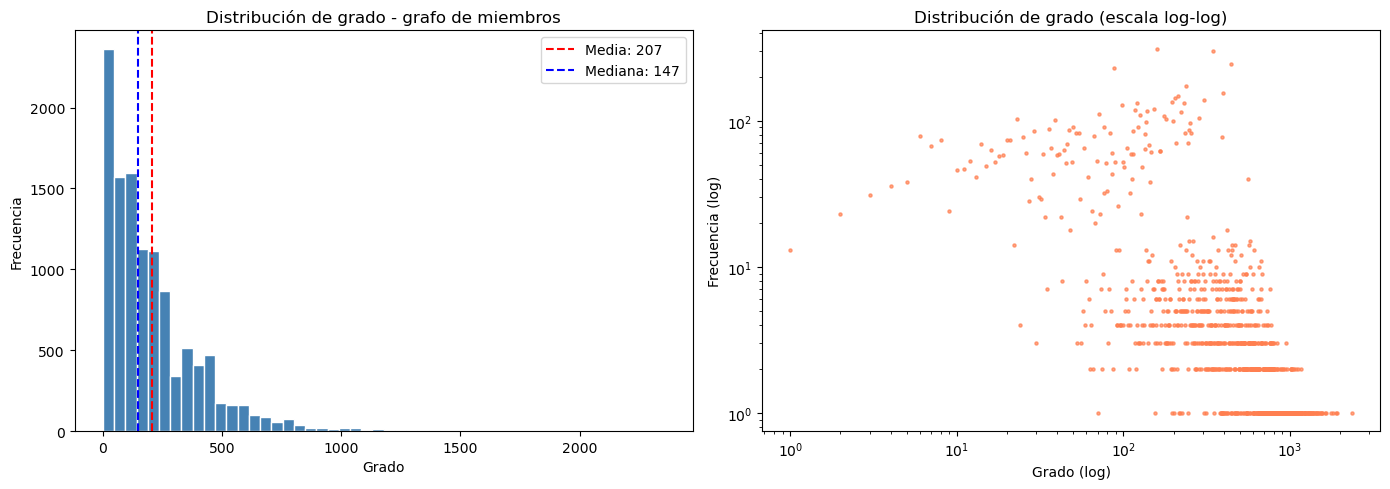

Estadísticas de grado:
count    11372.000000
mean       206.888498
std        202.139808
min          1.000000
25%         65.000000
50%        147.000000
75%        283.000000
max       2356.000000
dtype: float64

Nodos con grado = 1 (hoja)     : 13
Nodos con grado > 1000         : 97
Nodos con grado > 2000         : 1


In [32]:
# Distribución de grado
degrees = dict(M.degree())
degree_values = list(degrees.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma normal
axes[0].hist(degree_values, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(degree_values), color='red', linestyle='--', label=f'Media: {np.mean(degree_values):.0f}')
axes[0].axvline(np.median(degree_values), color='blue', linestyle='--', label=f'Mediana: {np.median(degree_values):.0f}')
axes[0].set_title('Distribución de grado - grafo de miembros')
axes[0].set_xlabel('Grado')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Escala log-log
degree_count = pd.Series(degree_values).value_counts().sort_index()
axes[1].scatter(degree_count.index, degree_count.values, s=5, color='coral', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Distribución de grado (escala log-log)')
axes[1].set_xlabel('Grado (log)')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

# Estadísticas de grado
degree_series = pd.Series(degree_values)
print('Estadísticas de grado:')
print(degree_series.describe())
print(f'\nNodos con grado = 1 (hoja)     : {(degree_series == 1).sum()}')
print(f'Nodos con grado > 1000         : {(degree_series > 1000).sum()}')
print(f'Nodos con grado > 2000         : {(degree_series > 2000).sum()}')

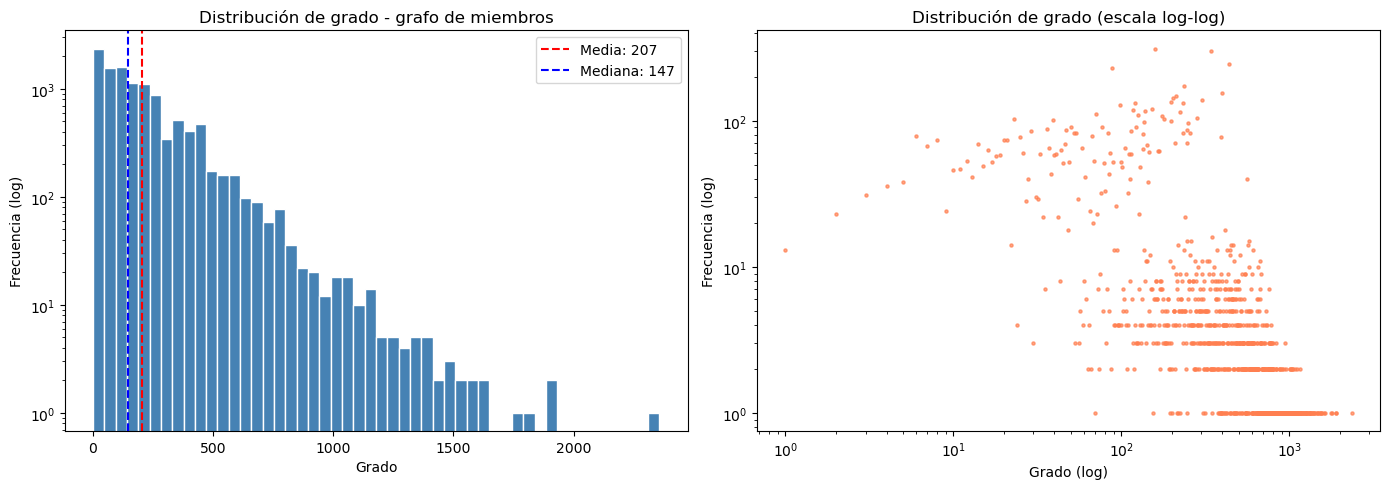

In [33]:
# Distribución de grado
degrees = dict(M.degree())
degree_values = list(degrees.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma normal
axes[0].hist(degree_values, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(degree_values), color='red', linestyle='--', label=f'Media: {np.mean(degree_values):.0f}')
axes[0].axvline(np.median(degree_values), color='blue', linestyle='--', label=f'Mediana: {np.median(degree_values):.0f}')
axes[0].set_yscale('log')
axes[0].set_title('Distribución de grado - grafo de miembros')
axes[0].set_xlabel('Grado')
axes[0].set_ylabel('Frecuencia (log)')
axes[0].legend()

# Escala log-log
degree_count = pd.Series(degree_values).value_counts().sort_index()
axes[1].scatter(degree_count.index, degree_count.values, s=5, color='coral', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Distribución de grado (escala log-log)')
axes[1].set_xlabel('Grado (log)')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

In [34]:
# Identificar los nodos extremos
degree_df = pd.DataFrame(list(degrees.items()), columns=['node_id', 'degree'])
degree_df = degree_df.merge(
    meta_members[['member_id', 'name', 'city', 'state']].astype({'member_id': str}),
    left_on='node_id', right_on='member_id', how='left'
)

print('Top 10 nodos con mayor grado:')
print(degree_df.nlargest(10, 'degree')[['node_id', 'name', 'city', 'state', 'degree']].to_string())

print('\nNodos hoja (grado = 1):')
print(degree_df[degree_df['degree'] == 1][['node_id', 'name', 'city', 'state', 'degree']].to_string())

Top 10 nodos con mayor grado:
        node_id               name       city state  degree
1195    3380276              Jim H  Nashville    TN    2356
1371    8539046            Shalini  Nashville    TN    1911
1306  221191725           Omar Ali  Nashville    TN    1893
222     5900662      Matt Kenigson  Nashville    TN    1811
1215   81924252            Theresa  Nashville    TN    1775
602    46486792   Michelle McManus  Nashville    TN    1642
2257  197928971                Ted   Franklin    TN    1620
1408  187254868     Andrew Clement  Nashville    TN    1568
1365  175300482                Rav  Nashville    TN    1556
405    15446041  Samuel Palaparthy  Nashville    TN    1542

Nodos hoja (grado = 1):
         node_id                       name            city state  degree
6444    92705052                Casey Manus       Nashville    TN       1
10089  197657497              Katlyn Spears  Hendersonville    TN       1
10985  219351819      Lisa Candigurl Morton       Nashville    

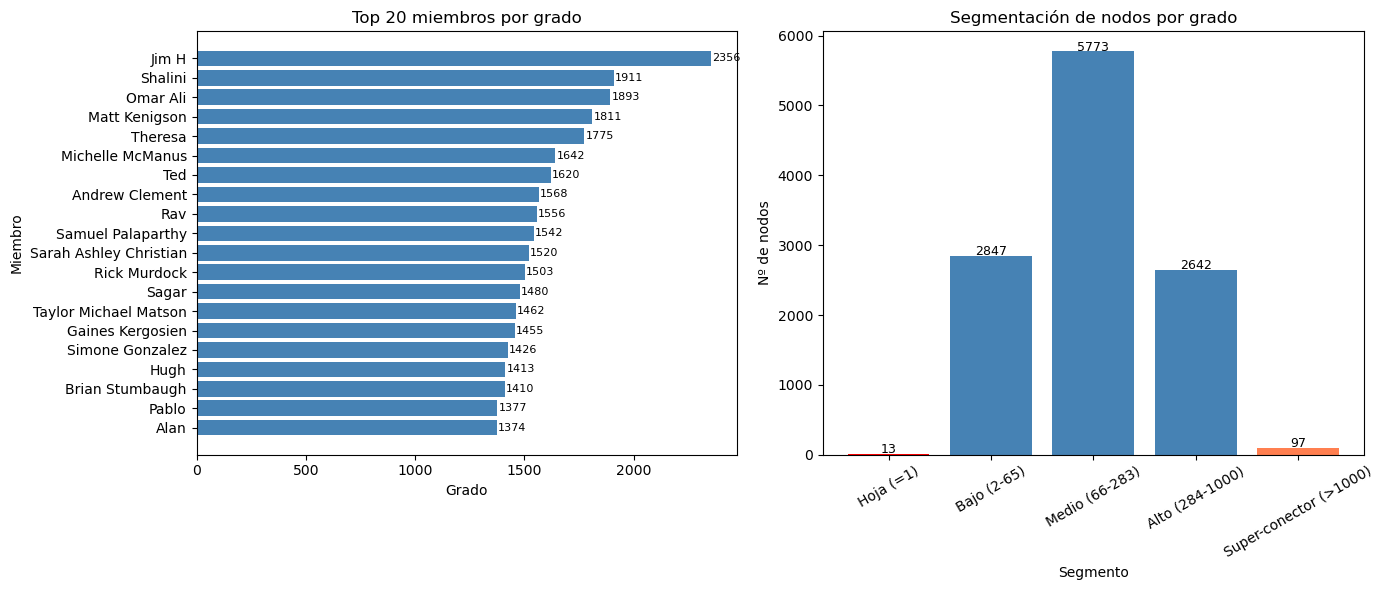

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Top 20 nodos con mayor grado ---
top20 = degree_df.nlargest(20, 'degree')
top20['label'] = top20['name'].fillna('Sin información')

axes[0].barh(top20['label'], top20['degree'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 miembros por grado')
axes[0].set_xlabel('Grado')
axes[0].set_ylabel('Miembro')
for i, v in enumerate(top20['degree']):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8)

# --- Gráfico 2: Nodos hoja vs. super-conectores vs. resto ---
bins_labels = ['Hoja (=1)', 'Bajo (2-65)', 'Medio (66-283)', 'Alto (284-1000)', 'Super-conector (>1000)']
bins_counts = [
    (degree_df['degree'] == 1).sum(),
    ((degree_df['degree'] > 1) & (degree_df['degree'] <= 65)).sum(),
    ((degree_df['degree'] > 65) & (degree_df['degree'] <= 283)).sum(),
    ((degree_df['degree'] > 283) & (degree_df['degree'] <= 1000)).sum(),
    (degree_df['degree'] > 1000).sum()
]

colors = ['red', 'steelblue', 'steelblue', 'steelblue', 'coral']
axes[1].bar(bins_labels, bins_counts, color=colors)
axes[1].set_title('Segmentación de nodos por grado')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Nº de nodos')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(bins_counts):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [36]:
# Centralidad de grado (normalizada)
degree_centrality = nx.degree_centrality(M)

# Betweenness centrality (costosa, usamos aproximación con k muestras)
print('Calculando betweenness centrality (aproximación)...')
betweenness = nx.betweenness_centrality(M, k=500, normalized=True, seed=42)

# Consolidar centralidades disponibles (sin closeness)
centrality_df = pd.DataFrame({
    'node_id': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness': list(betweenness.values()),
})

centrality_df = centrality_df.merge(
    meta_members[['member_id', 'name', 'city', 'state']].astype({'member_id': str}),
    left_on='node_id', right_on='member_id', how='left'
)

print('Top 10 por betweenness centrality:')
print(centrality_df.nlargest(10, 'betweenness')[
    ['name', 'city', 'state', 'degree_centrality', 'betweenness']
].to_string())

print('\nTop 10 por degree centrality:')
print(centrality_df.nlargest(10, 'degree_centrality')[
    ['name', 'city', 'state', 'degree_centrality', 'betweenness']
].to_string())

print('\nNodos con betweenness = 0:')
print(f"  {(centrality_df['betweenness'] == 0).sum()} nodos ({(centrality_df['betweenness'] == 0).sum()/len(centrality_df)*100:.1f}%)")

Calculando betweenness centrality (aproximación)...
Top 10 por betweenness centrality:
                 name       city state  degree_centrality  betweenness
1371          Shalini  Nashville    TN           0.168059     0.021231
222     Matt Kenigson  Nashville    TN           0.159265     0.018172
756             Pablo  Nashville    TN           0.121098     0.017554
2257              Ted   Franklin    TN           0.142468     0.015858
1306         Omar Ali  Nashville    TN           0.166476     0.013803
1365              Rav  Nashville    TN           0.136839     0.013694
62       David VanWie  Nashville    TN           0.088119     0.011944
1195            Jim H  Nashville    TN           0.207194     0.010987
1215          Theresa  Nashville    TN           0.156099     0.010234
1903  David Prochaska  Nashville    TN           0.116700     0.010023

Top 10 por degree centrality:
                   name       city state  degree_centrality  betweenness
1195              Jim H  Nas

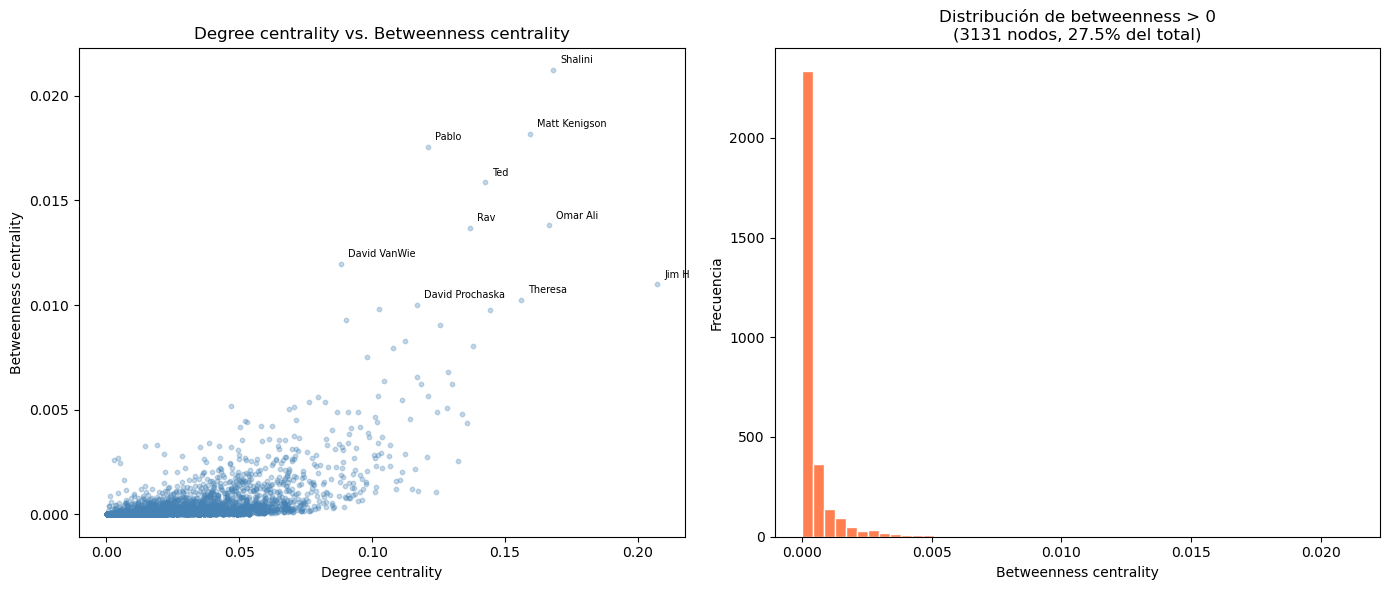

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Degree vs Betweenness scatter ---
axes[0].scatter(
    centrality_df['degree_centrality'],
    centrality_df['betweenness'],
    alpha=0.3, s=10, color='steelblue'
)

# Etiquetar los más interesantes (alto betweenness relativo a degree)
destacados = centrality_df.nlargest(10, 'betweenness')
for _, row in destacados.iterrows():
    axes[0].annotate(
        row['name'] if pd.notna(row['name']) else 'Sin info',
        (row['degree_centrality'], row['betweenness']),
        fontsize=7, xytext=(5, 5), textcoords='offset points'
    )

axes[0].set_title('Degree centrality vs. Betweenness centrality')
axes[0].set_xlabel('Degree centrality')
axes[0].set_ylabel('Betweenness centrality')

# --- Gráfico 2: Distribución de betweenness (excluyendo zeros) ---
non_zero = centrality_df[centrality_df['betweenness'] > 0]['betweenness']
axes[1].hist(non_zero, bins=50, color='coral', edgecolor='white')
axes[1].set_title(f'Distribución de betweenness > 0\n({len(non_zero)} nodos, {len(non_zero)/len(centrality_df)*100:.1f}% del total)')
axes[1].set_xlabel('Betweenness centrality')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

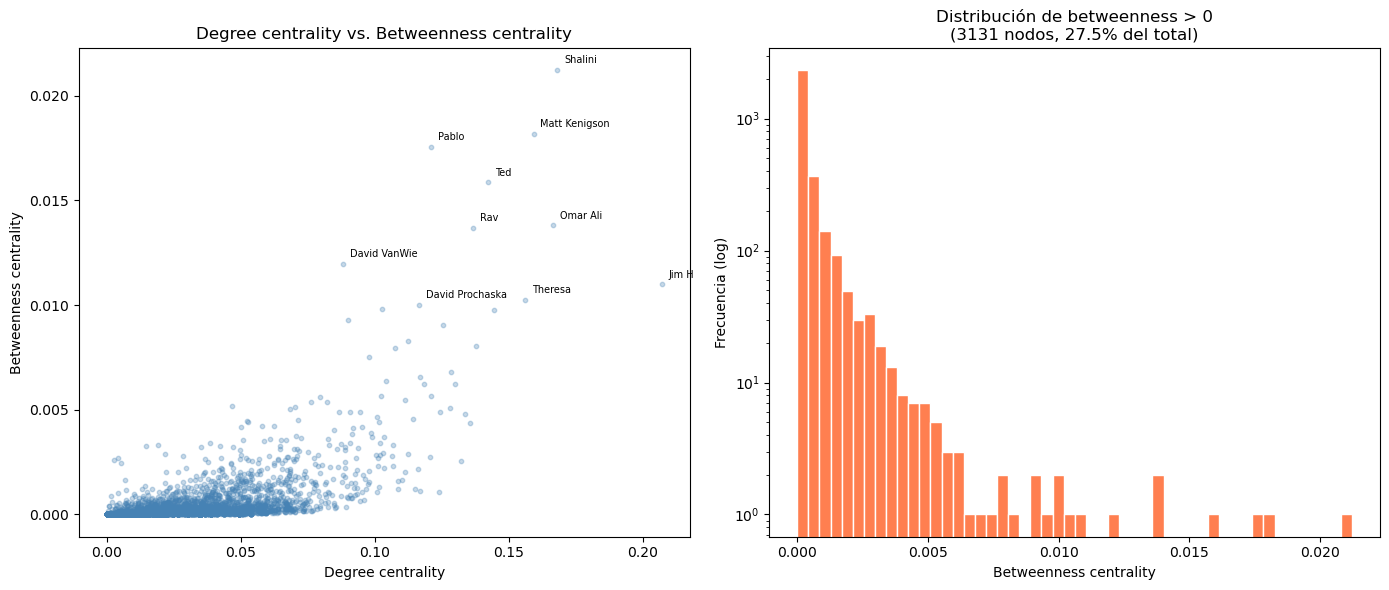

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Degree vs Betweenness scatter ---
axes[0].scatter(
    centrality_df['degree_centrality'],
    centrality_df['betweenness'],
    alpha=0.3, s=10, color='steelblue'
)

# Etiquetar los más interesantes (alto betweenness relativo a degree)
destacados = centrality_df.nlargest(10, 'betweenness')
for _, row in destacados.iterrows():
    axes[0].annotate(
        row['name'] if pd.notna(row['name']) else 'Sin info',
        (row['degree_centrality'], row['betweenness']),
        fontsize=7, xytext=(5, 5), textcoords='offset points'
    )

axes[0].set_title('Degree centrality vs. Betweenness centrality')
axes[0].set_xlabel('Degree centrality')
axes[0].set_ylabel('Betweenness centrality')

# --- Gráfico 2: Distribución de betweenness (excluyendo zeros) ---
non_zero = centrality_df[centrality_df['betweenness'] > 0]['betweenness']
axes[1].hist(non_zero, bins=50, color='coral', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title(f'Distribución de betweenness > 0\n({len(non_zero)} nodos, {len(non_zero)/len(centrality_df)*100:.1f}% del total)')
axes[1].set_xlabel('Betweenness centrality')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

Clustering medio global: 0.8850
Nodos con clustering = 1.0: 8228
Nodos con clustering < 0.5: 922
Nodos con clustering < 0.1: 13

Top 10 nodos con menor clustering:
                            name            city state  clustering
6444                 Casey Manus       Nashville    TN         0.0
10089              Katlyn Spears  Hendersonville    TN         0.0
10985      Lisa Candigurl Morton       Nashville    TN         0.0
11174             bernd mergener   Winston Salem    NC         0.0
11194                    Michael       Nashville    TN         0.0
11207              Lizzie Keiper       Nashville    TN         0.0
11341           Johnny Whitfield       Nashville    TN         0.0
11344  GEEK by AKEIN Engineering         Antioch    TN         0.0
11349           Thiru Sethuraman       Nashville    TN         0.0
11354             Rosemary Frank       Brentwood    TN         0.0


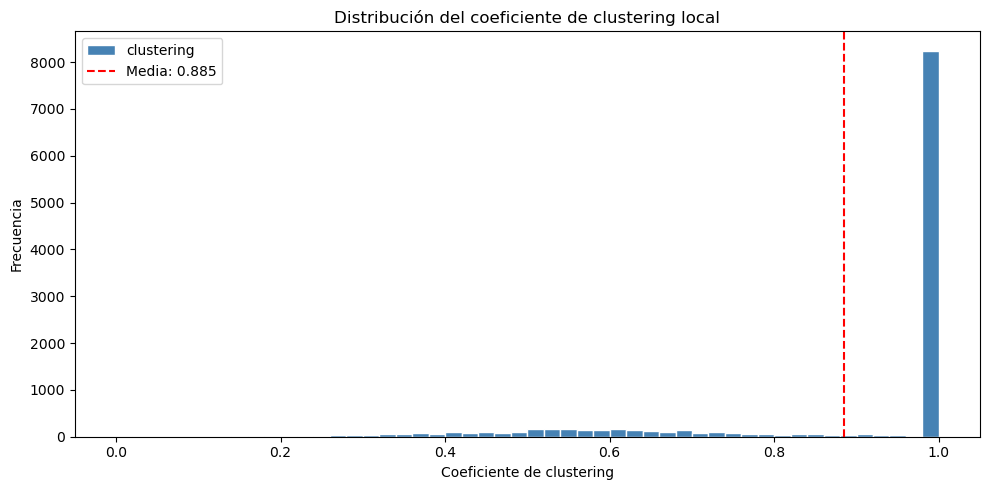

In [39]:
# Clustering local por nodo
local_clustering = nx.clustering(M)
clustering_df = pd.DataFrame({
    'node_id': list(local_clustering.keys()),
    'clustering': list(local_clustering.values())
}).merge(
    meta_members[['member_id', 'name', 'city', 'state']].astype({'member_id': str}),
    left_on='node_id', right_on='member_id', how='left'
)

print(f'Clustering medio global: {clustering_df["clustering"].mean():.4f}')
print(f'Nodos con clustering = 1.0: {(clustering_df["clustering"] == 1.0).sum()}')
print(f'Nodos con clustering < 0.5: {(clustering_df["clustering"] < 0.5).sum()}')
print(f'Nodos con clustering < 0.1: {(clustering_df["clustering"] < 0.1).sum()}')

print('\nTop 10 nodos con menor clustering:')
print(clustering_df.nsmallest(10, 'clustering')[
    ['name', 'city', 'state', 'clustering']
].to_string())

# Distribución
fig, ax = plt.subplots(figsize=(10, 5))
clustering_df['clustering'].plot(kind='hist', bins=50, color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Distribución del coeficiente de clustering local')
ax.set_xlabel('Coeficiente de clustering')
ax.set_ylabel('Frecuencia')
ax.axvline(clustering_df['clustering'].mean(), color='red', linestyle='--',
           label=f'Media: {clustering_df["clustering"].mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

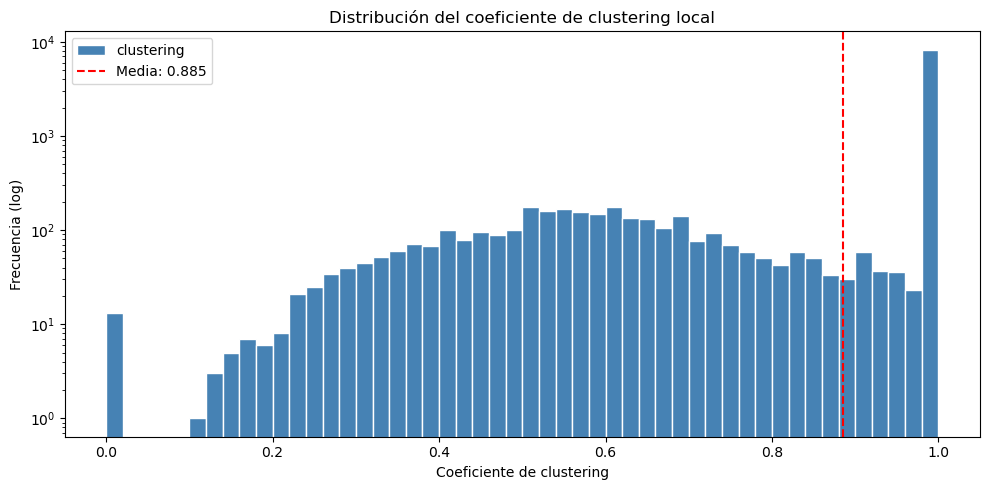

In [40]:
# Distribución
fig, ax = plt.subplots(figsize=(10, 5))
clustering_df['clustering'].plot(kind='hist', bins=50, color='steelblue', edgecolor='white', ax=ax)
ax.set_yscale('log')
ax.set_title('Distribución del coeficiente de clustering local')
ax.set_xlabel('Coeficiente de clustering')
ax.set_ylabel('Frecuencia (log)')
ax.axvline(clustering_df['clustering'].mean(), color='red', linestyle='--',
           label=f'Media: {clustering_df["clustering"].mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
from networkx.algorithms import community

# ── Louvain (Usando la implementación nativa de NetworkX) ──────────────────
print('Detectando comunidades con Louvain...')

# Nota: Louvain en NetworkX devuelve una lista de sets (comunidades)
communities_louvain = community.louvain_communities(M, seed=42)
modularity_louvain = community.modularity(M, communities_louvain)

# Convertimos a Series de tamaños para las estadísticas
louvain_sizes = pd.Series([len(c) for c in communities_louvain]).sort_values(ascending=False)

print(f'Louvain — Comunidades detectadas : {len(louvain_sizes)}')
print(f'Louvain — Modularidad            : {modularity_louvain:.4f}')
print(f'Louvain — Tamaño medio           : {louvain_sizes.mean():.1f}')
print(f'Louvain — Comunidad más grande   : {louvain_sizes.max()}')
print(f'Louvain — Comunidad más pequeña  : {louvain_sizes.min()}')
print(f'Louvain — Comunidades < 10 nodos : {(louvain_sizes < 10).sum()}')

# ── Greedy Modularity ──────────────────────────────────────────────────────
print('\nDetectando comunidades con Greedy Modularity...')

communities_greedy = community.greedy_modularity_communities(M)
modularity_greedy = community.modularity(M, communities_greedy)

greedy_sizes = pd.Series([len(c) for c in communities_greedy]).sort_values(ascending=False)

print(f'Greedy — Comunidades detectadas  : {len(greedy_sizes)}')
print(f'Greedy — Modularidad             : {modularity_greedy:.4f}')
print(f'Greedy — Tamaño medio            : {greedy_sizes.mean():.1f}')
print(f'Greedy — Comunidad más grande    : {greedy_sizes.max()}')
print(f'Greedy — Comunidad más pequeña   : {greedy_sizes.min()}')
print(f'Greedy — Comunidades < 10 nodos  : {(greedy_sizes < 10).sum()}')

# ── Comparativa ────────────────────────────────────────────────────────────
print('\n' + '='*40)
print(f'{"Métrica":<25} {"Louvain":>10} {"Greedy":>10}')
print('-'*45)
print(f'{"Nº comunidades":<25} {len(louvain_sizes):>10} {len(greedy_sizes):>10}')
print(f'{"Modularidad":<25} {modularity_louvain:>10.4f} {modularity_greedy:>10.4f}')
print(f'{"Tamaño medio":<25} {louvain_sizes.mean():>10.1f} {greedy_sizes.mean():>10.1f}')
print(f'{"Comunidad máx":<25} {louvain_sizes.max():>10} {greedy_sizes.max():>10}')
print(f'{"Comunidades < 10":<25} {(louvain_sizes < 10).sum():>10} {(greedy_sizes < 10).sum():>10}')
print('='*40)

Detectando comunidades con Louvain...
Louvain — Comunidades detectadas : 22
Louvain — Modularidad            : 0.6755
Louvain — Tamaño medio           : 516.9
Louvain — Comunidad más grande   : 2215
Louvain — Comunidad más pequeña  : 6
Louvain — Comunidades < 10 nodos : 1

Detectando comunidades con Greedy Modularity...
Greedy — Comunidades detectadas  : 35
Greedy — Modularidad             : 0.6127
Greedy — Tamaño medio            : 324.9
Greedy — Comunidad más grande    : 2622
Greedy — Comunidad más pequeña   : 4
Greedy — Comunidades < 10 nodos  : 11

Métrica                      Louvain     Greedy
---------------------------------------------
Nº comunidades                    22         35
Modularidad                   0.6755     0.6127
Tamaño medio                   516.9      324.9
Comunidad máx                   2215       2622
Comunidades < 10                   1         11


In [42]:
# Crear mapping nodo -> comunidad para Louvain
node_to_community = {}
for i, comm in enumerate(communities_louvain):
    for node in comm:
        node_to_community[node] = i

# Añadir comunidad a centrality_df
centrality_df['community_louvain'] = centrality_df['node_id'].map(node_to_community)
clustering_df['community_louvain'] = clustering_df['node_id'].map(node_to_community)

# Enriquecer comunidades con metadatos
community_stats = centrality_df.groupby('community_louvain').agg(
    size=('node_id', 'count'),
    avg_degree=('degree_centrality', 'mean'),
    avg_betweenness=('betweenness', 'mean'),
    top_member=('name', lambda x: x.iloc[centrality_df.loc[x.index, 'degree_centrality'].argmax()])
).sort_values('community_louvain')  # ← ordenado por índice de comunidad

# Añadir estado más frecuente por comunidad
state_mode = centrality_df.groupby('community_louvain')['state'].agg(
    lambda x: x.value_counts().index[0] if x.notna().any() else 'N/A'
)
community_stats['state_predominante'] = state_mode

print('Estadísticas por comunidad (Louvain):')
print(community_stats.to_string())

Estadísticas por comunidad (Louvain):
                   size  avg_degree  avg_betweenness           top_member state_predominante
community_louvain                                                                           
0                   170    0.010463         0.000041                Chris                 TN
1                   206    0.005281         0.000039            Vicki Lea                 TN
2                    13    0.001231         0.000000          Hannah Pike                 TN
3                   209    0.007189         0.000033              Jessica                 TN
4                  1049    0.017271         0.000146                Pablo                 TN
5                   302    0.012740         0.000062  James Lauderdale Jr                 TN
6                   508    0.042154         0.000400       Andrew Clement                 TN
7                   927    0.020964         0.000174              Shalini                 TN
8                  1651    0.011

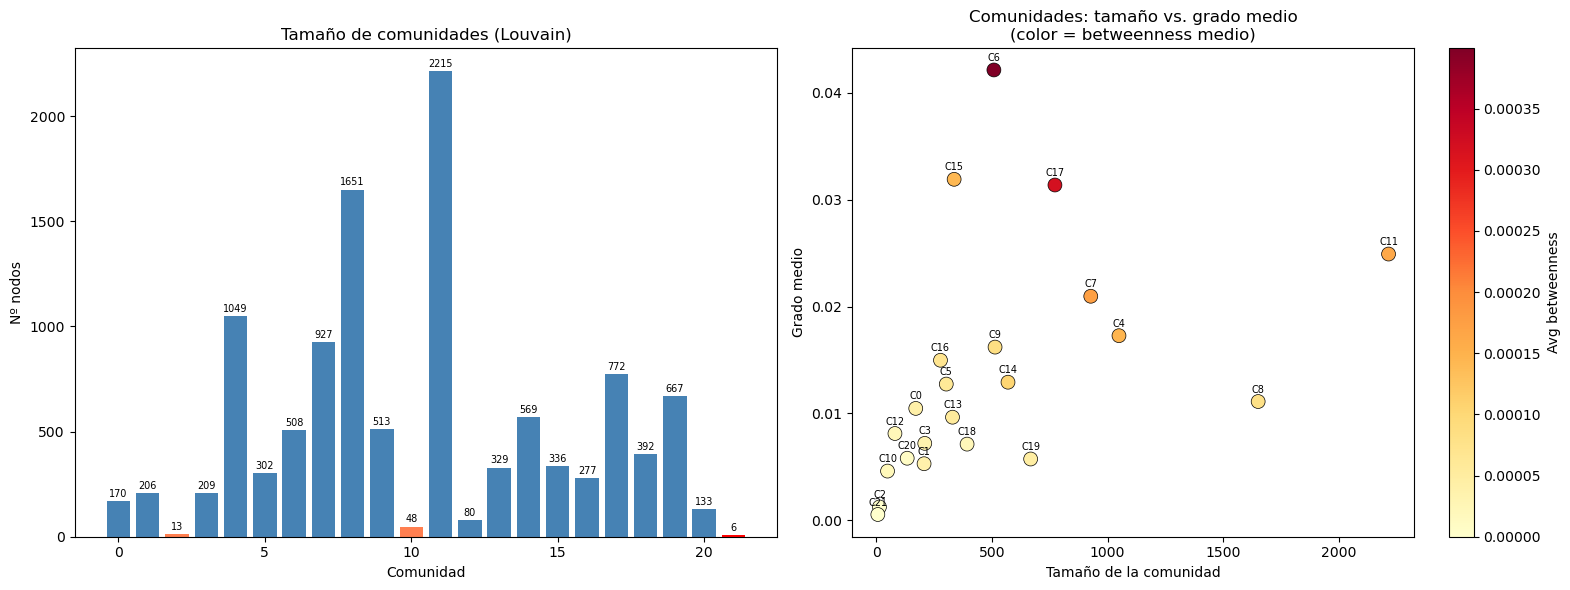

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Tamaño de comunidades ---
colors = ['red' if s < 10 else 'coral' if s < 50 else 'steelblue' 
          for s in community_stats['size']]
axes[0].bar(community_stats.index, community_stats['size'], color=colors)
axes[0].set_title('Tamaño de comunidades (Louvain)')
axes[0].set_xlabel('Comunidad')
axes[0].set_ylabel('Nº nodos')
axes[0].tick_params(axis='x', rotation=0)
for i, (idx, row) in enumerate(community_stats.iterrows()):
    axes[0].text(idx, row['size'] + 20, str(row['size']), 
                ha='center', fontsize=7)

# --- Gráfico 2: Scatter tamaño vs avg_degree coloreado por avg_betweenness ---
scatter = axes[1].scatter(
    community_stats['size'],
    community_stats['avg_degree'],
    c=community_stats['avg_betweenness'],
    cmap='YlOrRd',
    s=100,
    edgecolors='black',
    linewidths=0.5
)
plt.colorbar(scatter, ax=axes[1], label='Avg betweenness')

for idx, row in community_stats.iterrows():
    axes[1].annotate(f'C{idx}', (row['size'], row['avg_degree']),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

axes[1].set_title('Comunidades: tamaño vs. grado medio\n(color = betweenness medio)')
axes[1].set_xlabel('Tamaño de la comunidad')
axes[1].set_ylabel('Grado medio')

plt.tight_layout()
plt.show()

In [44]:
# Necesitamos rsvps o member-to-group-edges para saber qué grupos tiene cada miembro
# Cargamos member-to-group-edges
member_group = pd.read_csv('../data/processed/member-to-group-edges.csv')
print(member_group.columns.tolist())
print(member_group.head())

['member_id', 'group_id', 'weight']
   member_id  group_id  weight
0       2069  19277993       3
1     625050  19277993       2
2    1939496  19277993       1
3    2606806  19277993       4
4    3438546  19277993       1


In [45]:
# Añadir comunidad Louvain a cada miembro
member_group['member_id'] = member_group['member_id'].astype(str)

member_community = pd.DataFrame([
    {'member_id': node, 'community_louvain': comm}
    for node, comm in node_to_community.items()
])

member_group_comm = member_group.merge(member_community, on='member_id', how='inner')

# Cruzar con meta_groups para obtener categoría
member_group_comm = member_group_comm.merge(
    meta_groups[['group_id', 'group_name', 'category_name']],
    on='group_id', how='left'
)

# Categoría dominante por comunidad (ponderada por weight)
community_themes = member_group_comm.groupby(
    ['community_louvain', 'category_name']
)['weight'].sum().reset_index()

# Top 3 categorías por comunidad
top_themes = community_themes.sort_values(
    ['community_louvain', 'weight'], ascending=[True, False]
).groupby('community_louvain').head(3)

print('Top 3 categorías por comunidad (ponderado por asistencia):')
print(top_themes.to_string())

Top 3 categorías por comunidad (ponderado por asistencia):
     community_louvain               category_name  weight
11                   0                        Tech     715
0                    0           Career & Business     181
6                    0      New Age & Spirituality      20
16                   1        Education & Learning     390
12                   1              Arts & Culture     314
15                   1     Community & Environment     237
34                   2         Sports & Recreation     350
33                   2        Outdoors & Adventure       2
51                   3         Sports & Recreation    1411
35                   3                  Book Clubs     145
41                   3          Health & Wellbeing     114
80                   4                 Socializing    2951
63                   4                Food & Drink    1364
73                   4        Outdoors & Adventure     871
110                  5                     Writing     8

Resumen de comunidades Louvain con temática dominante:
    community_louvain           main_category  size  avg_degree  avg_betweenness           top_member
0                   0                    Tech   170    0.010463         0.000041                Chris
1                   1    Education & Learning   206    0.005281         0.000039            Vicki Lea
2                   2     Sports & Recreation    13    0.001231         0.000000          Hannah Pike
3                   3     Sports & Recreation   209    0.007189         0.000033              Jessica
4                   4             Socializing  1049    0.017271         0.000146                Pablo
5                   5                 Writing   302    0.012740         0.000062  James Lauderdale Jr
6                   6             Socializing   508    0.042154         0.000400       Andrew Clement
7                   7    Outdoors & Adventure   927    0.020964         0.000174              Shalini
8                   8      

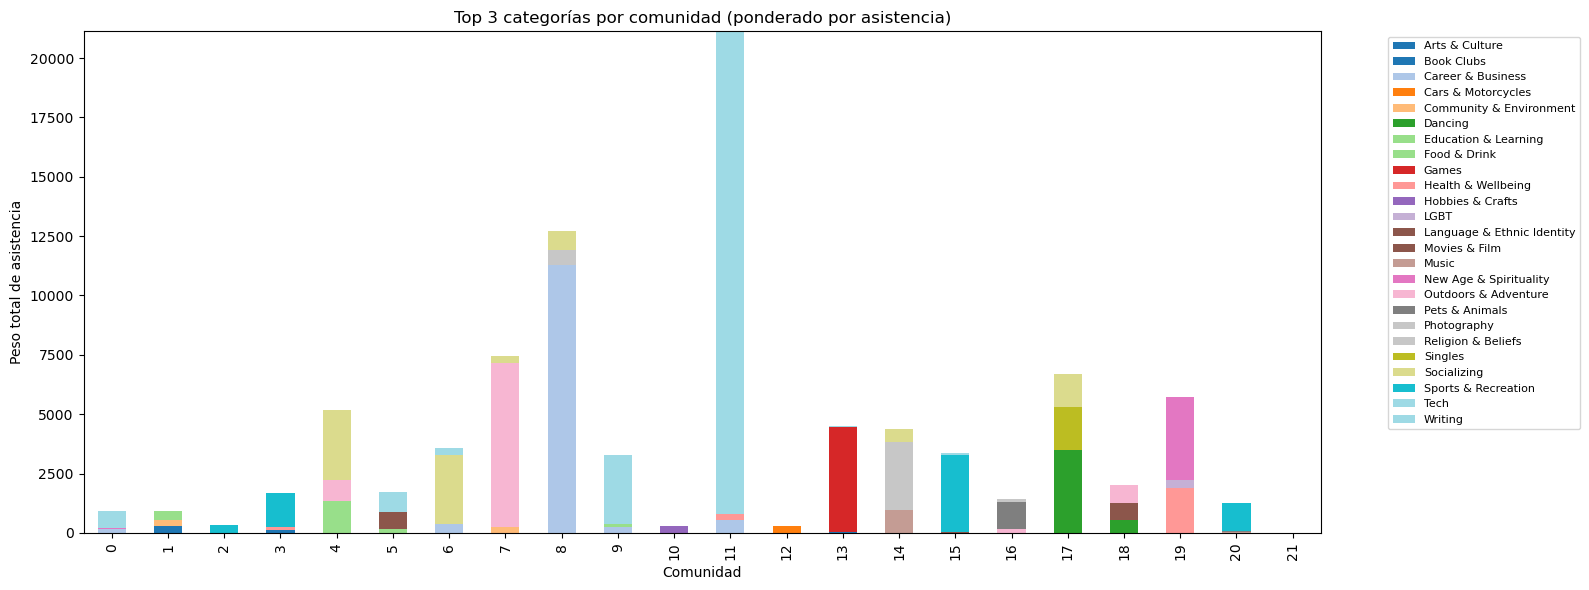

In [46]:
# Tabla resumen: top 1 categoría por comunidad (la temática dominante)
community_label = community_themes.sort_values(
    ['community_louvain', 'weight'], ascending=[True, False]
).groupby('community_louvain').first().reset_index()
community_label.columns = ['community_louvain', 'main_category', 'main_weight']

# Añadir tamaño y métricas
community_summary = community_label.merge(
    community_stats[['size', 'avg_degree', 'avg_betweenness', 'top_member']].reset_index(),
    on='community_louvain'
)

print('Resumen de comunidades Louvain con temática dominante:')
print(community_summary[['community_louvain', 'main_category', 'size', 
                          'avg_degree', 'avg_betweenness', 'top_member']].to_string())

# Visualización: barras apiladas top 3 categorías por comunidad
pivot_themes = community_themes.sort_values(
    ['community_louvain', 'weight'], ascending=[True, False]
).groupby('community_louvain').head(3).pivot_table(
    index='community_louvain', columns='category_name', 
    values='weight', fill_value=0
)

pivot_themes.plot(kind='bar', stacked=True, figsize=(16, 6), colormap='tab20')
plt.title('Top 3 categorías por comunidad (ponderado por asistencia)')
plt.xlabel('Comunidad')
plt.ylabel('Peso total de asistencia')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [47]:
# Añadir comunidad Louvain como atributo de nodo para visualizar el grafo con Gephi
nx.set_node_attributes(M, node_to_community, name='community_louvain')

# Verificar que se ha añadido correctamente
sample_nodes = list(M.nodes(data=True))[:3]
print('Verificación de atributos de nodo:')
for node, attrs in sample_nodes:
    print(f'  Nodo {node}: {attrs}')

# Crear carpeta si no existe
output_path = "../graphs/graphml_cluster/member_graph_cluster.graphml"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Guardar grafo como GraphML
nx.write_graphml(M, output_path)
print(f'\nGrafo guardado correctamente en: {output_path}')

Verificación de atributos de nodo:
  Nodo 198737924: {'name': 'Rod Bragg', 'city': 'Nashville', 'state': 'TN', 'lat': 36.17, 'lon': -86.78, 'community_louvain': 14}
  Nodo 220654721: {'name': 'Fred Lee Scott', 'city': 'Nashville', 'state': 'TN', 'lat': 36.16, 'lon': -86.78, 'community_louvain': 14}
  Nodo 208201738: {'name': 'Scott Pigna', 'city': 'Nashville', 'state': 'TN', 'lat': 36.17, 'lon': -86.72, 'community_louvain': 4}

Grafo guardado correctamente en: ../graphs/graphml_cluster/member_graph_cluster.graphml


# EDA — Grafo de Miembros

## 1. Estadísticas básicas

El grafo de miembros contiene **11.372 nodos y 1.176.368 aristas**. Es importante señalar que `meta_members` contaba con 24.591 miembros, lo que significa que solo el **46.2% de los miembros aparecen en el grafo** — el resto no comparte membresía con ningún otro miembro y por tanto no genera aristas. El grafo es **completamente conexo** (una única componente), lo que indica que todos los miembros presentes están conectados entre sí de alguna forma.

## 2. Métricas básicas

La **densidad del grafo es de 0.0182**, lo que lo clasifica como un grafo disperso, comportamiento habitual y esperable en redes sociales reales de este tamaño. Sin embargo, el **grado medio de 206.89** es llamativamente alto — cada miembro comparte membresía con otros 207 de media — consecuencia directa de la existencia de grupos gigantes como Nashville Hiking Meetup que conectan a miles de miembros entre sí de golpe.

El dato más llamativo es el **coeficiente de clustering medio de 0.885**, un valor muy alto para una red de este tamaño. Indica que los vecinos de un nodo tienden a ser también vecinos entre sí, lo que refleja una estructura de comunidad muy fuerte y anticipa que los algoritmos de detección de comunidades van a funcionar bien sobre este grafo.

## 3. Distribución de grado

La distribución de grado presenta una **fuerte asimetría positiva** característica de redes sociales, con una media (207) muy superior a la mediana (147) y una desviación típica (202) prácticamente igual a la media, lo que refleja una enorme variabilidad. El rango va de 1 a 2.356.

La representación en escala log-log no muestra una ley de potencia limpia, sino una nube dispersa con varias bandas horizontales. Esto es consecuencia de la naturaleza discreta del grafo: pertenecer a un grupo de 500 miembros añade automáticamente ~500 conexiones de golpe, generando saltos discretos en el grado.

La segmentación de nodos por grado revela la siguiente estructura: 13 nodos hoja (grado = 1), 2.847 nodos de grado bajo (2-65), 5.773 nodos de grado medio (66-283) — el segmento mayoritario con el 50.8% del total —, 2.642 nodos de grado alto (284-1.000) y 97 super-conectores con grado superior a 1.000.

## 4. Análisis de nodos extremos

**Jim H** es el miembro más conectado de toda la red con un grado de 2.356, casi 450 conexiones más que el segundo (Shalini, 1.911). Los 20 miembros con mayor grado son casi exclusivamente residentes en Nashville, TN, lo que es coherente con la concentración geográfica del dataset.

En el extremo opuesto, los **13 nodos hoja** presentan perfiles heterogéneos: algunos son personas físicas con actividad mínima, pero destaca **"GEEK by AKEIN Engineering"**, claramente una entidad empresarial y no una persona física, lo que constituye una anomalía de tipo de entidad en la red.

## 5. Métricas de centralidad

El análisis de degree centrality y betweenness centrality revela patrones estructurales muy relevantes para la detección de anomalías. **Jim H lidera en degree centrality (0.207) pero no en betweenness (0.011)** — está muy conectado pero sus vecinos también se conocen entre sí, por lo que no actúa como puente entre comunidades.

**Shalini** presenta el caso más interesante: segunda en degree centrality pero primera en betweenness (0.021), lo que la convierte en el puente más importante de la red. Más llamativo aún es el caso de **Pablo**, que con una degree centrality moderada (posición 756 en el ranking) alcanza la tercera posición en betweenness (0.018) — un rol estructural de puente desproporcionadamente alto respecto a su número de conexiones, y uno de los candidatos más relevantes a anomalía estructural del dataset.

El dato más significativo es que **8.241 nodos (72.5%) tienen betweenness = 0**, es decir, no actúan como puente en ningún camino mínimo de la red. En un grafo tan denso esto confirma que la gran mayoría de miembros están completamente embebidos dentro de sus comunidades.

## 6. Coeficiente de clustering local

La distribución del clustering local es marcadamente **bimodal**: **8.228 nodos (72.4%) tienen clustering = 1.0** — sus vecinos forman un clique perfecto — mientras que un grupo minoritario presenta valores entre 0.4 y 0.9. Los **13 nodos con clustering = 0** coinciden exactamente con los 13 nodos hoja identificados previamente, lo cual es matemáticamente inevitable: con un único vecino no puede existir ningún triángulo.

Los **922 nodos con clustering < 0.5** son los más relevantes para detección de anomalías: tienen suficientes conexiones para que la métrica sea significativa, pero sus vecinos no se conocen entre sí, lo que indica un rol de puente entre comunidades distintas.

## 7. Detección de comunidades

Se aplicaron dos algoritmos de detección de comunidades: **Louvain** y **Greedy Modularity**. Louvain obtuvo una modularidad de **0.6755** frente a los 0.6127 de Greedy, detectando 22 comunidades frente a las 35 de Greedy. Una modularidad superior a 0.6 se considera muy buena e indica comunidades bien definidas y separadas. Dado su mejor rendimiento y menor fragmentación, **Louvain se adopta como algoritmo principal** para el resto del análisis, utilizando Greedy como validación.

| Métrica | Louvain | Greedy |
|---|---|---|
| Nº comunidades | 22 | 35 |
| Modularidad | 0.6755 | 0.6127 |
| Tamaño medio | 516.9 | 324.9 |
| Comunidad más grande | 2.215 | 2.622 |
| Comunidades < 10 nodos | 1 | 11 |

## 8. Análisis de comunidades Louvain

Las 22 comunidades detectadas presentan una distribución de tamaños muy heterogénea, desde 6 hasta 2.215 nodos. El cruce con los metadatos de grupos revela que la mayoría de comunidades tienen una **temática dominante clara**, lo que valida la coherencia del algoritmo.

Las comunidades más relevantes son las siguientes. **C11 (Tech, 2.215 nodos)** es la más grande, coherente con los 100 grupos tecnológicos del dataset. **C8 (Career & Business, 1.651 nodos)** es la segunda más grande y también temáticamente muy coherente. **C7 (Outdoors & Adventure, 927 nodos)** agrupa la comunidad de actividades al aire libre, donde Shalini — el mayor puente de la red — es el miembro más conectado. **C17 (Dancing, 772 nodos)** alberga a Jim H, el nodo de mayor grado de toda la red.

Desde el punto de vista de la detección de anomalías destacan varios casos. **C6 (Socializing, 508 nodos)** es la comunidad estructuralmente más influyente, con el mayor grado medio (0.042) y betweenness medio (0.0004) de todas las comunidades a pesar de su tamaño moderado — probablemente concentra miembros muy activos que asisten a múltiples tipos de grupos. **C2 (Sports & Recreation, 13 nodos)** y **C21 (Games, 6 nodos)** son microcomunidades completamente periféricas con betweenness = 0, candidatas directas a anomalía estructural. **C12 (Cars & Motorcycles, 80 nodos)** representa una comunidad de nicho muy específico, coherente con los apenas 2 grupos de esa categoría en el dataset.

## 9. Relevancia para detección de anomalías

El análisis del grafo de miembros permite consolidar un conjunto sólido de candidatos a anomalía para la fase de modelado. Los **13 nodos hoja** y los **922 nodos con clustering < 0.5** representan extremos estructurales bien diferenciados del comportamiento mayoritario. Los **97 super-conectores** y en particular casos como Pablo — alta betweenness con degree moderada — sugieren roles estructurales atípicos que merecen análisis específico. Las **microcomunidades C2 y C21** son anomalías a nivel de subgrafo. Finalmente, la entidad **"GEEK by AKEIN Engineering"** representa una anomalía de naturaleza del nodo, al tratarse de una organización y no de una persona física en una red diseñada para individuos.

# EDA — Grafo de Miembros

## 1. Estadísticas básicas

El grafo de miembros contiene **11.372 nodos y 1.176.368 aristas**. Es importante señalar que `meta_members` contaba con 24.591 miembros, lo que significa que solo el **46.2% de los miembros aparecen en el grafo** — el resto no comparte membresía con ningún otro miembro y por tanto no genera aristas. El grafo es **completamente conexo** (una única componente), lo que indica que todos los miembros presentes están conectados entre sí de alguna forma.

## 2. Métricas básicas

La **densidad del grafo es de 0.0182**, lo que lo clasifica como un grafo disperso, comportamiento habitual y esperable en redes sociales reales de este tamaño. Sin embargo, el **grado medio de 206.89** es llamativamente alto — cada miembro comparte membresía con otros 207 de media — consecuencia directa de la existencia de grupos gigantes como Nashville Hiking Meetup que conectan a miles de miembros entre sí de golpe.

El dato más llamativo es el **coeficiente de clustering medio de 0.885**, un valor muy alto para una red de este tamaño. Indica que los vecinos de un nodo tienden a ser también vecinos entre sí, lo que refleja una estructura de comunidad muy fuerte y anticipa que los algoritmos de detección de comunidades van a funcionar bien sobre este grafo.

## 3. Distribución de grado

La distribución de grado presenta una **fuerte asimetría positiva** característica de redes sociales, con una media (207) muy superior a la mediana (147) y una desviación típica (202) prácticamente igual a la media, lo que refleja una enorme variabilidad. El rango va de 1 a 2.356.

La representación en escala log-log no muestra una ley de potencia limpia, sino una nube dispersa con varias bandas horizontales. Esto es consecuencia de la naturaleza discreta del grafo: pertenecer a un grupo de 500 miembros añade automáticamente ~500 conexiones de golpe, generando saltos discretos en el grado.

La segmentación de nodos por grado revela la siguiente estructura: 13 nodos hoja (grado = 1), 2.847 nodos de grado bajo (2-65), 5.773 nodos de grado medio (66-283) — el segmento mayoritario con el 50.8% del total —, 2.642 nodos de grado alto (284-1.000) y 97 super-conectores con grado superior a 1.000.

## 4. Análisis de nodos extremos

**Jim H** es el miembro más conectado de toda la red con un grado de 2.356, casi 450 conexiones más que el segundo (Shalini, 1.911). Los 20 miembros con mayor grado son casi exclusivamente residentes en Nashville, TN, lo que es coherente con la concentración geográfica del dataset.

En el extremo opuesto, los **13 nodos hoja** presentan perfiles heterogéneos: algunos son personas físicas con actividad mínima, pero destaca **"GEEK by AKEIN Engineering"**, claramente una entidad empresarial y no una persona física, lo que constituye una anomalía de tipo de entidad en la red.

## 5. Métricas de centralidad

El análisis de degree centrality y betweenness centrality revela patrones estructurales muy relevantes para la detección de anomalías. **Jim H lidera en degree centrality (0.207) pero no en betweenness (0.011)** — está muy conectado pero sus vecinos también se conocen entre sí, por lo que no actúa como puente entre comunidades.

**Shalini** presenta el caso más interesante: segunda en degree centrality pero primera en betweenness (0.021), lo que la convierte en el puente más importante de la red. Más llamativo aún es el caso de **Pablo**, que con una degree centrality moderada (posición 756 en el ranking) alcanza la tercera posición en betweenness (0.018) — un rol estructural de puente desproporcionadamente alto respecto a su número de conexiones, y uno de los candidatos más relevantes a anomalía estructural del dataset.

El dato más significativo es que **8.241 nodos (72.5%) tienen betweenness = 0**, es decir, no actúan como puente en ningún camino mínimo de la red. En un grafo tan denso esto confirma que la gran mayoría de miembros están completamente embebidos dentro de sus comunidades.

## 6. Coeficiente de clustering local

La distribución del clustering local es marcadamente **bimodal**: **8.228 nodos (72.4%) tienen clustering = 1.0** — sus vecinos forman un clique perfecto — mientras que un grupo minoritario presenta valores entre 0.4 y 0.9. Los **13 nodos con clustering = 0** coinciden exactamente con los 13 nodos hoja identificados previamente, lo cual es matemáticamente inevitable: con un único vecino no puede existir ningún triángulo.

Los **922 nodos con clustering < 0.5** son los más relevantes para detección de anomalías: tienen suficientes conexiones para que la métrica sea significativa, pero sus vecinos no se conocen entre sí, lo que indica un rol de puente entre comunidades distintas.

## 7. Análisis de pesos de aristas

Las aristas del grafo de miembros representan el número de grupos que dos miembros tienen en común. La distribución de pesos es extremadamente concentrada: **el 95.9% de las aristas tienen peso = 1**, lo que significa que la gran mayoría de pares de miembros solo comparten membresía en un único grupo. La media (1.05) es prácticamente igual a la mediana (1.0), y el peso máximo es 9 — el par más cercano de toda la red comparte membresía en 9 grupos distintos.

El gráfico en escala logarítmica confirma la caída exponencial: cada nivel de peso tiene aproximadamente 10-15 veces menos aristas que el anterior. Las **74 aristas con peso > 5** son candidatas a anomalía, ya que una co-membresía tan alta en múltiples grupos podría indicar actividad coordinada o artificial.

El análisis de las aristas más pesadas revela que **Garrett Vangilder — Matt Kraatz** comparten 9 grupos, el vínculo más fuerte de toda la red. **Matt Kenigson** aparece en dos de las diez aristas más pesadas, coherente con su posición en el top de degree centrality. En general, los super-conectores identificados previamente tienden también a tener los vínculos más fuertes entre sí.

## 8. Detección de comunidades

Se aplicaron dos algoritmos de detección de comunidades: **Louvain** y **Greedy Modularity**. Louvain obtuvo una modularidad de **0.6755** frente a los 0.6127 de Greedy, detectando 22 comunidades frente a las 35 de Greedy. Una modularidad superior a 0.6 se considera muy buena e indica comunidades bien definidas y separadas. Dado su mejor rendimiento y menor fragmentación, **Louvain se adopta como algoritmo principal** para el resto del análisis, utilizando Greedy como validación.

| Métrica | Louvain | Greedy |
|---|---|---|
| Nº comunidades | 22 | 35 |
| Modularidad | 0.6755 | 0.6127 |
| Tamaño medio | 516.9 | 324.9 |
| Comunidad más grande | 2.215 | 2.622 |
| Comunidades < 10 nodos | 1 | 11 |

## 9. Análisis de comunidades Louvain

Las 22 comunidades detectadas presentan una distribución de tamaños muy heterogénea, desde 6 hasta 2.215 nodos. El cruce con los metadatos de grupos revela que la mayoría de comunidades tienen una **temática dominante clara**, lo que valida la coherencia del algoritmo.

Las comunidades más relevantes son las siguientes. **C11 (Tech, 2.215 nodos)** es la más grande, coherente con los 100 grupos tecnológicos del dataset. **C8 (Career & Business, 1.651 nodos)** es la segunda más grande y también temáticamente muy coherente. **C7 (Outdoors & Adventure, 927 nodos)** agrupa la comunidad de actividades al aire libre, donde Shalini — el mayor puente de la red — es el miembro más conectado. **C17 (Dancing, 772 nodos)** alberga a Jim H, el nodo de mayor grado de toda la red.

Desde el punto de vista de la detección de anomalías destacan varios casos. **C6 (Socializing, 508 nodos)** es la comunidad estructuralmente más influyente, con el mayor grado medio (0.042) y betweenness medio (0.0004) de todas las comunidades a pesar de su tamaño moderado — probablemente concentra miembros muy activos que asisten a múltiples tipos de grupos. **C2 (Sports & Recreation, 13 nodos)** y **C21 (Games, 6 nodos)** son microcomunidades completamente periféricas con betweenness = 0, candidatas directas a anomalía estructural. **C12 (Cars & Motorcycles, 80 nodos)** representa una comunidad de nicho muy específico, coherente con los apenas 2 grupos de esa categoría en el dataset.

## 10. Análisis de nodos puente entre comunidades

El ratio inter-comunidad mide qué fracción de los vecinos de cada nodo pertenecen a una comunidad Louvain distinta a la suya. La **media es de 0.181**, lo que indica que de media el 18% de las conexiones de cada miembro son inter-comunidad — la mayoría de conexiones son intra-comunidad, coherente con el alto clustering global.

La distribución presenta una forma **bimodal**: un primer pico en ratios bajos (0-0.05) correspondiente a los nodos muy embebidos en su comunidad, y una distribución más uniforme hasta 0.4-0.5. Hay **211 nodos con ratio = 0** — completamente embebidos sin ninguna conexión externa — y **487 nodos con ratio > 0.5** — verdaderos puentes donde la mayoría de sus vecinos están en otras comunidades.

El scatter de degree centrality vs. ratio inter-comunidad revela un patrón muy claro: **a mayor degree, menor ratio inter-comunidad** — los super-conectores tienden a estar más embebidos en su comunidad, no a ser puentes. La excepción más notable es **Jim H** (degree 0.207, ratio 0.759) — el nodo más conectado de toda la red distribuye sus 2.356 conexiones entre múltiples comunidades, ejerciendo simultáneamente un rol de super-conector y puente inter-comunidad.

Los casos más interesantes son los nodos con **degree baja pero ratio alto**: **Tremaine James** (ratio 0.833) y **Mary Beth** (ratio 0.800) son puentes frágiles — pocas conexiones pero casi todas inter-comunidad — mientras que **chen hajaj** (ratio 0.803, betweenness 0.0036) y **James Lauderdale Jr** (ratio 0.788, betweenness 0.0035) combinan un ratio alto con betweenness notable, siendo los puentes más sólidos y estructuralmente relevantes de la red.

## 11. Relevancia para detección de anomalías

El análisis del grafo de miembros permite consolidar un conjunto sólido de candidatos a anomalía para la fase de modelado. Los **13 nodos hoja** y los **922 nodos con clustering < 0.5** representan extremos estructurales bien diferenciados del comportamiento mayoritario. Los **97 super-conectores** y en particular casos como Pablo — alta betweenness con degree moderada — sugieren roles estructurales atípicos que merecen análisis específico. Las **microcomunidades C2 y C21** son anomalías a nivel de subgrafo. Las **74 aristas con peso > 5** son candidatas a anomalía de arista por co-membresía excesiva. Los **487 nodos con ratio inter-comunidad > 0.5** constituyen un conjunto de puentes estructurales que conectan comunidades temáticamente distintas. Finalmente, la entidad **"GEEK by AKEIN Engineering"** representa una anomalía de naturaleza del nodo, al tratarse de una organización y no de una persona física en una red diseñada para individuos.

Aristas con peso             : 1176368
Aristas sin peso             : 0

Estadísticas de pesos:
count    1.176368e+06
mean     1.047387e+00
std      2.501198e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
dtype: float64

Aristas con peso = 1         : 1128695 (95.9%)
Aristas con peso > 5         : 74 (0.0%)
Aristas con peso > 10        : 0 (0.0%)

Top 10 aristas por peso:
                    name1                  name2  weight
76200   Garrett Vangilder            Matt Kraatz       9
36920       Matt Kenigson  Taylor Michael Matson       8
94888         Adia Tigney             Trent Hand       8
135182          Calvin J.                 Jeremy       8
36897       Matt Kenigson           JoAnn Brooks       7
43350       Luke Woodward          Carter Harris       7
61117   Samuel Palaparthy  Taylor Michael Matson       7
66525       Carter Harris        Brian Stumbaugh       7
76393   Garrett Vangilder          Alex Simon

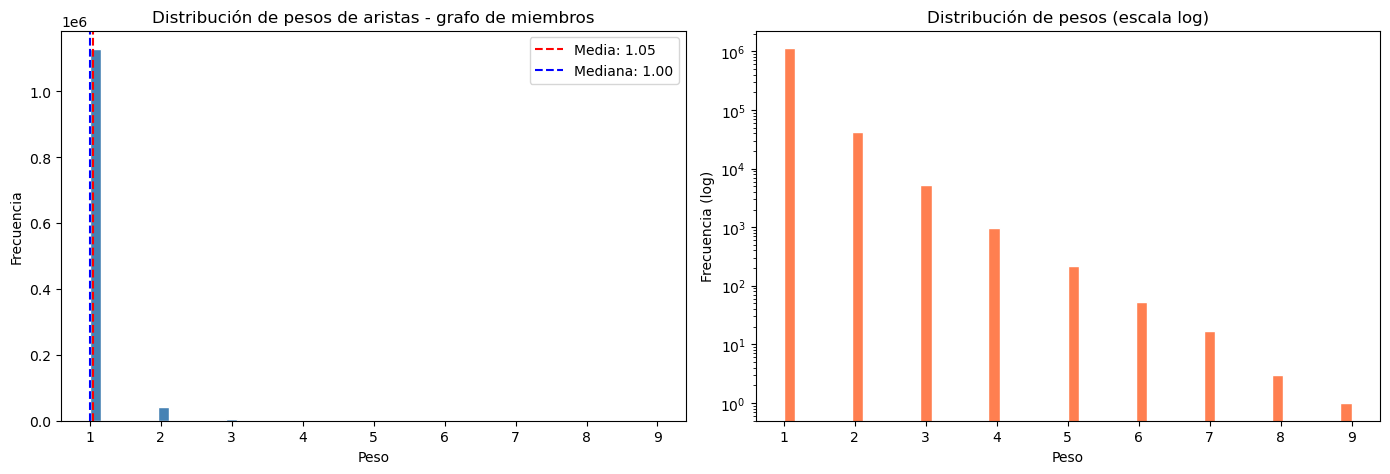

In [67]:
# ── Análisis de pesos de aristas - grafo de miembros ──────────────────────

# Extraer pesos
edge_weights_M = [data['weight'] for _, _, data in M.edges(data=True) if 'weight' in data]

print(f'Aristas con peso             : {len(edge_weights_M)}')
print(f'Aristas sin peso             : {len(M.edges) - len(edge_weights_M)}')

weight_series_M = pd.Series(edge_weights_M)
print(f'\nEstadísticas de pesos:')
print(weight_series_M.describe())
print(f'\nAristas con peso = 1         : {(weight_series_M == 1).sum()} ({(weight_series_M == 1).sum()/len(weight_series_M)*100:.1f}%)')
print(f'Aristas con peso > 5         : {(weight_series_M > 5).sum()} ({(weight_series_M > 5).sum()/len(weight_series_M)*100:.1f}%)')
print(f'Aristas con peso > 10        : {(weight_series_M > 10).sum()} ({(weight_series_M > 10).sum()/len(weight_series_M)*100:.1f}%)')

# Top 10 aristas por peso
edge_list_M = [(u, v, d['weight']) for u, v, d in M.edges(data=True) if 'weight' in d]
edge_df_M = pd.DataFrame(edge_list_M, columns=['node1', 'node2', 'weight'])

# Enriquecer con nombres
edge_df_M = edge_df_M.merge(
    meta_members[['member_id', 'name']].astype({'member_id': str}).rename(columns={'name': 'name1'}),
    left_on='node1', right_on='member_id', how='left'
).drop('member_id', axis=1)

edge_df_M = edge_df_M.merge(
    meta_members[['member_id', 'name']].astype({'member_id': str}).rename(columns={'name': 'name2'}),
    left_on='node2', right_on='member_id', how='left'
).drop('member_id', axis=1)

print('\nTop 10 aristas por peso:')
print(edge_df_M.nlargest(10, 'weight')[['name1', 'name2', 'weight']].to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma normal
weight_series_M.plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de pesos de aristas - grafo de miembros')
axes[0].set_xlabel('Peso')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(weight_series_M.mean(), color='red', linestyle='--',
                label=f'Media: {weight_series_M.mean():.2f}')
axes[0].axvline(weight_series_M.median(), color='blue', linestyle='--',
                label=f'Mediana: {weight_series_M.median():.2f}')
axes[0].legend()

# Escala log
weight_series_M.plot(kind='hist', bins=50, ax=axes[1], color='coral', 
                     edgecolor='white', log=True)
axes[1].set_title('Distribución de pesos (escala log)')
axes[1].set_xlabel('Peso')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

In [73]:
# ── Nodos puente entre comunidades - grafo de miembros ────────────────────

# Para cada nodo, calcular qué fracción de sus vecinos están en otras comunidades
def inter_community_ratio(G, node, partition):
    neighbors = list(G.neighbors(node))
    if len(neighbors) == 0:
        return 0
    node_comm = partition[node]
    inter = sum(1 for n in neighbors if partition.get(n, -1) != node_comm)
    return inter / len(neighbors)

# Calcular ratio inter-comunidad para cada nodo
inter_ratio = {node: inter_community_ratio(M, node, node_to_community) 
               for node in M.nodes()}

centrality_df['inter_community_ratio'] = centrality_df['node_id'].map(inter_ratio)

print('Estadísticas de inter_community_ratio:')
print(centrality_df['inter_community_ratio'].describe())
print(f'\nNodos con ratio = 0 (todos vecinos en misma comunidad): {(centrality_df["inter_community_ratio"] == 0).sum()}')
print(f'Nodos con ratio > 0.5 (mayoría vecinos en otra comunidad): {(centrality_df["inter_community_ratio"] > 0.5).sum()}')
print(f'Nodos con ratio = 1.0 (todos vecinos en otra comunidad): {(centrality_df["inter_community_ratio"] == 1.0).sum()}')

print('\nTop 10 nodos puente (mayor ratio inter-comunidad):')
print(centrality_df.nlargest(10, 'inter_community_ratio')[
    ['name', 'city', 'state', 'degree_centrality', 'betweenness', 
     'inter_community_ratio', 'community_louvain']
].to_string())

Estadísticas de inter_community_ratio:
count    11372.000000
mean         0.180630
std          0.149716
min          0.000000
25%          0.064551
50%          0.142857
75%          0.266667
max          0.833333
Name: inter_community_ratio, dtype: float64

Nodos con ratio = 0 (todos vecinos en misma comunidad): 211
Nodos con ratio > 0.5 (mayoría vecinos en otra comunidad): 487
Nodos con ratio = 1.0 (todos vecinos en otra comunidad): 0

Top 10 nodos puente (mayor ratio inter-comunidad):
                      name            city state  degree_centrality  betweenness  inter_community_ratio  community_louvain
11199       Tremaine James       Nashville    TN           0.000528     0.000000               0.833333                  9
5092            chen hajaj       Nashville    TN           0.082754     0.003590               0.803401                  4
4631        Deanna Vickers       Brentwood    TN           0.098056     0.002084               0.801794                 14
10571         

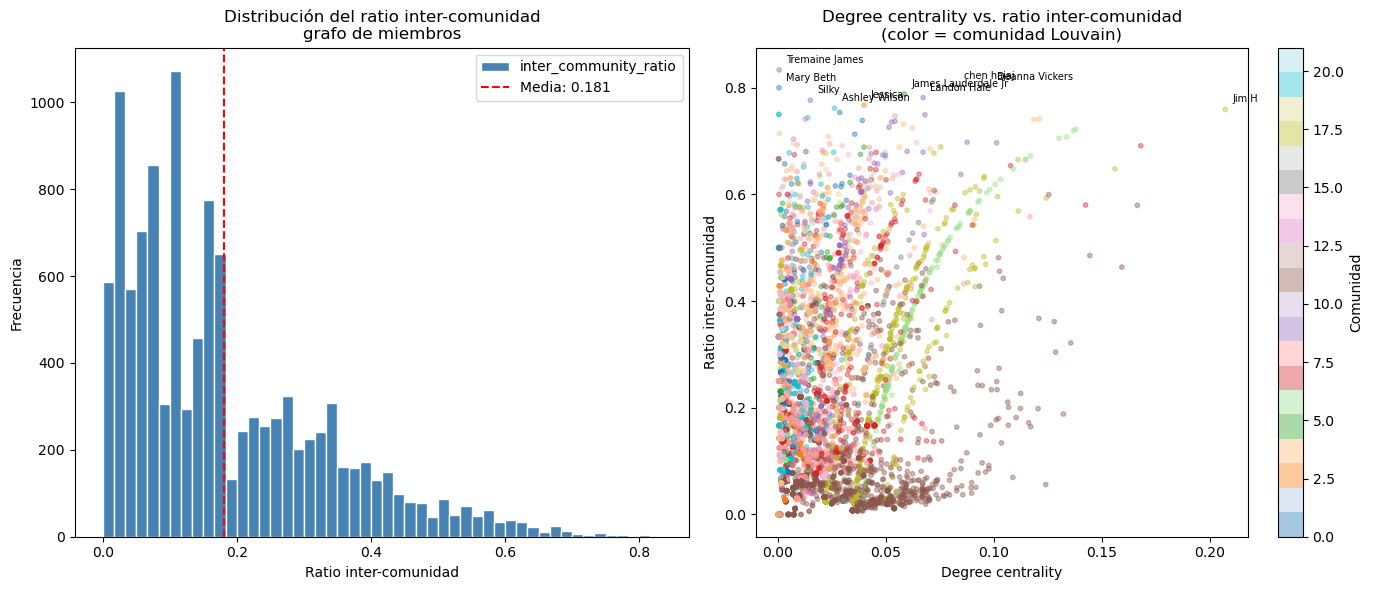

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Distribución del ratio inter-comunidad ---
centrality_df['inter_community_ratio'].plot(
    kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].axvline(centrality_df['inter_community_ratio'].mean(), 
                color='red', linestyle='--',
                label=f'Media: {centrality_df["inter_community_ratio"].mean():.3f}')
axes[0].set_title('Distribución del ratio inter-comunidad\ngrafo de miembros')
axes[0].set_xlabel('Ratio inter-comunidad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# --- Gráfico 2: Scatter ratio vs degree coloreado por comunidad ---
scatter = axes[1].scatter(
    centrality_df['degree_centrality'],
    centrality_df['inter_community_ratio'],
    c=centrality_df['community_louvain'],
    cmap='tab20',
    alpha=0.4,
    s=10
)

# Etiquetar top puentes
top_bridges = centrality_df.nlargest(10, 'inter_community_ratio')
for _, row in top_bridges.iterrows():
    axes[1].annotate(
        row['name'] if pd.notna(row['name']) else 'Sin info',
        (row['degree_centrality'], row['inter_community_ratio']),
        fontsize=7, xytext=(5, 5), textcoords='offset points'
    )

axes[1].set_title('Degree centrality vs. ratio inter-comunidad\n(color = comunidad Louvain)')
axes[1].set_xlabel('Degree centrality')
axes[1].set_ylabel('Ratio inter-comunidad')
plt.colorbar(scatter, ax=axes[1], label='Comunidad')
plt.tight_layout()
plt.show()

# 1- Grafo de grupos

In [48]:
# Group graph
G = nx.read_graphml("../graphs/graphml/group_graph.graphml")
print('El grafo de grupos tiene {} nodos y {} aristas.'.format(len(G.nodes), len(G.edges)))

fields = set()
for _, attrs in G.nodes(data=True):
    fields.update(attrs.keys())

print('El grafo de grupos tiene los siguientes atributos de nodo:', fields)
print('El grafo de grupos es conexo:', nx.is_connected(G))
print('El grafo de grupos tiene', nx.number_connected_components(G), 'componentes conexas.')

El grafo de grupos tiene 456 nodos y 6692 aristas.
El grafo de grupos tiene los siguientes atributos de nodo: {'organizer_id', 'category_id', 'num_members', 'category_name', 'group_name', 'group_urlname'}
El grafo de grupos es conexo: True
El grafo de grupos tiene 1 componentes conexas.


In [49]:
# Métricas básicas del grafo de grupos
degree_G = dict(G.degree())
degree_values_G = list(degree_G.values())

print('--- Métricas básicas del grafo de grupos ---')
print(f'Nodos                           : {len(G.nodes):,}')
print(f'Aristas                         : {len(G.edges):,}')
print(f'Densidad                        : {nx.density(G):.4f}')
print(f'Grado medio                     : {sum(degree_values_G) / len(degree_values_G):.2f}')
print(f'Grado máximo                    : {max(degree_values_G)}')
print(f'Grado mínimo                    : {min(degree_values_G)}')
print(f'Coeficiente de clustering medio : {nx.average_clustering(G):.4f}')

# Grupos no presentes en el grafo
groups_in_graph = set(G.nodes())
all_groups = set(meta_groups['group_id'].astype(str))
groups_not_in_graph = all_groups - groups_in_graph
print(f'\nGrupos en meta_groups no presentes en el grafo: {len(groups_not_in_graph)} ({len(groups_not_in_graph)/len(all_groups)*100:.1f}%)')

--- Métricas básicas del grafo de grupos ---
Nodos                           : 456
Aristas                         : 6,692
Densidad                        : 0.0645
Grado medio                     : 29.35
Grado máximo                    : 182
Grado mínimo                    : 1
Coeficiente de clustering medio : 0.5488

Grupos en meta_groups no presentes en el grafo: 146 (24.3%)


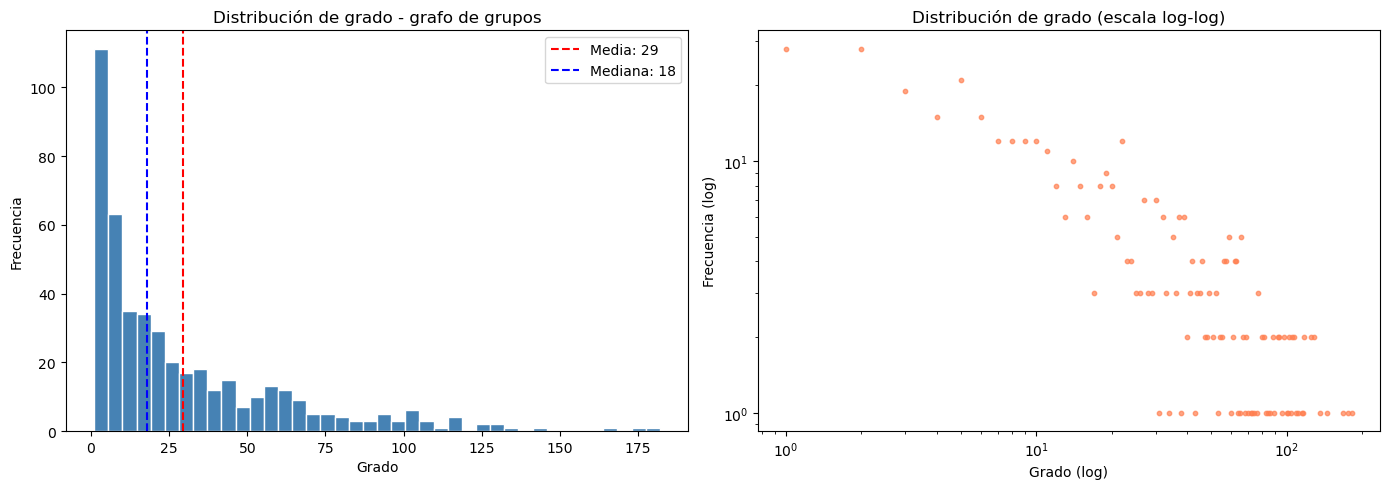

Estadísticas de grado:
count    456.000000
mean      29.350877
std       32.253456
min        1.000000
25%        6.000000
50%       18.000000
75%       42.000000
max      182.000000
dtype: float64

Nodos con grado = 1 (hoja)  : 28
Nodos con grado > 100       : 23


In [51]:
# Distribución de grado
degree_df_G = pd.DataFrame(list(degree_G.items()), columns=['node_id', 'degree'])

# Enriquecer con atributos del grafo
node_attrs_G = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index').reset_index()
node_attrs_G.columns = ['node_id'] + list(node_attrs_G.columns[1:])
degree_df_G = degree_df_G.merge(node_attrs_G, on='node_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma normal
axes[0].hist(degree_values_G, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(degree_values_G), color='red', linestyle='--',
                label=f'Media: {np.mean(degree_values_G):.0f}')
axes[0].axvline(np.median(degree_values_G), color='blue', linestyle='--',
                label=f'Mediana: {np.median(degree_values_G):.0f}')
axes[0].set_title('Distribución de grado - grafo de grupos')
axes[0].set_xlabel('Grado')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Escala log-log
degree_count_G = pd.Series(degree_values_G).value_counts().sort_index()
axes[1].scatter(degree_count_G.index, degree_count_G.values, s=10, color='coral', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Distribución de grado (escala log-log)')
axes[1].set_xlabel('Grado (log)')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

# Estadísticas
degree_series_G = pd.Series(degree_values_G)
print('Estadísticas de grado:')
print(degree_series_G.describe())
print(f'\nNodos con grado = 1 (hoja)  : {(degree_series_G == 1).sum()}')
print(f'Nodos con grado > 100       : {(degree_series_G > 100).sum()}')

In [52]:
# Top 10 y bottom 10
print('\nTop 10 grupos por grado:')
print(degree_df_G.nlargest(10, 'degree')[['group_name', 'category_name', 'num_members', 'degree']].to_string())
print('\nGrupos con grado = 1:')
print(degree_df_G[degree_df_G['degree'] == 1][['group_name', 'category_name', 'num_members', 'degree']].to_string())


Top 10 grupos por grado:
                                                  group_name         category_name  num_members  degree
3                           Stepping Out Social Dance Meetup               Dancing         1778     182
9                                              Eat Love Nash           Socializing         5008     176
39                                             What the Pho!          Food & Drink         1889     168
16                                          20s in Nashville           Socializing         3811     145
55                                   Nashville Hiking Meetup  Outdoors & Adventure        15838     136
45                                     Middle TN 40+ singles               Singles         2583     129
99                            Nashville Online Entrepreneurs     Career & Business         1532     129
106                                Sunday Assembly Nashville    Religion & Beliefs          918     125
160  Nashville SEO & Internet Marketin

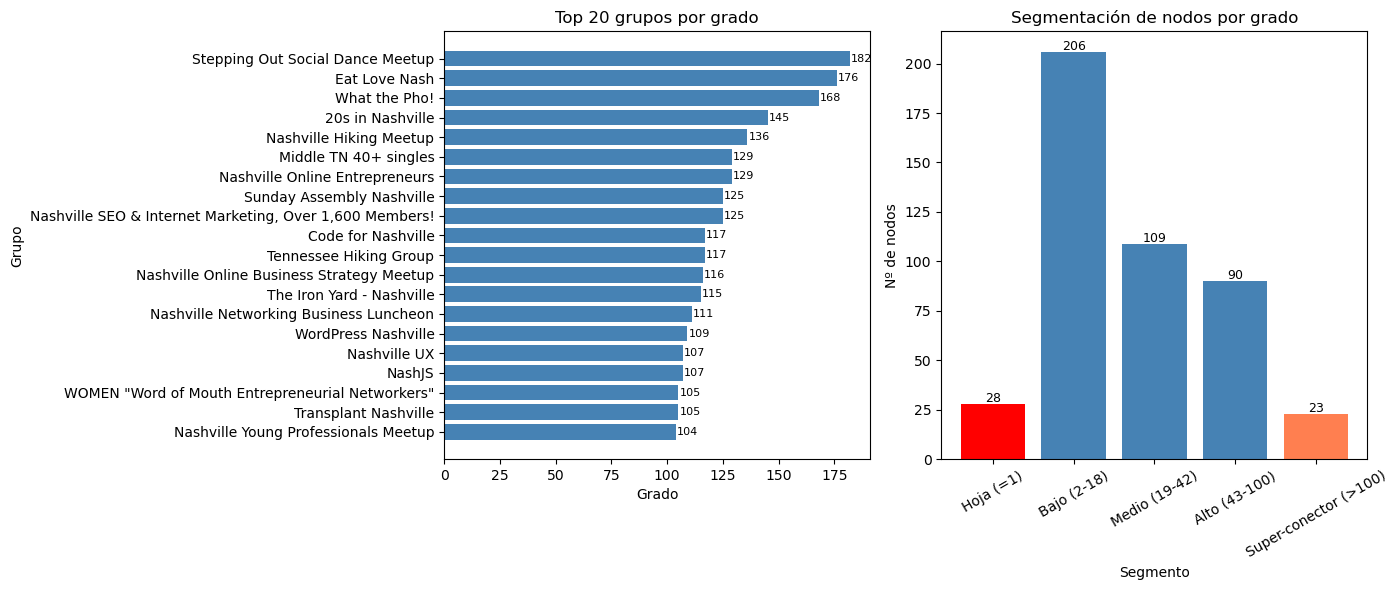

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Top 20 grupos por grado ---
top20_G = degree_df_G.nlargest(20, 'degree')

axes[0].barh(top20_G['group_name'], top20_G['degree'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 grupos por grado')
axes[0].set_xlabel('Grado')
axes[0].set_ylabel('Grupo')
for i, v in enumerate(top20_G['degree']):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=8)

# --- Gráfico 2: Segmentación de nodos por grado ---
bins_labels = ['Hoja (=1)', 'Bajo (2-18)', 'Medio (19-42)', 'Alto (43-100)', 'Super-conector (>100)']
bins_counts = [
    (degree_df_G['degree'] == 1).sum(),
    ((degree_df_G['degree'] > 1) & (degree_df_G['degree'] <= 18)).sum(),
    ((degree_df_G['degree'] > 18) & (degree_df_G['degree'] <= 42)).sum(),
    ((degree_df_G['degree'] > 42) & (degree_df_G['degree'] <= 100)).sum(),
    (degree_df_G['degree'] > 100).sum()
]

colors = ['red', 'steelblue', 'steelblue', 'steelblue', 'coral']
axes[1].bar(bins_labels, bins_counts, color=colors)
axes[1].set_title('Segmentación de nodos por grado')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Nº de nodos')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(bins_counts):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [54]:
# Centralidades - grafo pequeño, podemos calcular exacto
print('Calculando centralidades...')
degree_centrality_G = nx.degree_centrality(G)
betweenness_G = nx.betweenness_centrality(G, normalized=True, seed=42)
clustering_G = nx.clustering(G)

# Consolidar en DataFrame
centrality_df_G = pd.DataFrame({
    'node_id': list(degree_centrality_G.keys()),
    'degree_centrality': list(degree_centrality_G.values()),
    'betweenness': list(betweenness_G.values()),
    'clustering': list(clustering_G.values())
})

centrality_df_G = centrality_df_G.merge(node_attrs_G, on='node_id', how='left')

print('Estadísticas de centralidades:')
print(centrality_df_G[['degree_centrality', 'betweenness', 'clustering']].describe())

print('\nTop 10 por betweenness:')
print(centrality_df_G.nlargest(10, 'betweenness')[
    ['group_name', 'category_name', 'num_members', 'degree_centrality', 'betweenness', 'clustering']
].to_string())

print('\nTop 10 por degree centrality:')
print(centrality_df_G.nlargest(10, 'degree_centrality')[
    ['group_name', 'category_name', 'num_members', 'degree_centrality', 'betweenness', 'clustering']
].to_string())

print(f'\nGrupos con betweenness = 0: {(centrality_df_G["betweenness"] == 0).sum()} ({(centrality_df_G["betweenness"] == 0).sum()/len(centrality_df_G)*100:.1f}%)')
print(f'Grupos con clustering = 0 : {(centrality_df_G["clustering"] == 0).sum()}')
print(f'Grupos con clustering = 1 : {(centrality_df_G["clustering"] == 1).sum()}')

Calculando centralidades...
Estadísticas de centralidades:
       degree_centrality  betweenness  clustering
count         456.000000   456.000000  456.000000
mean            0.064507     0.003024    0.548752
std             0.070887     0.007205    0.269937
min             0.002198     0.000000    0.000000
25%             0.013187     0.000008    0.378684
50%             0.039560     0.000300    0.527066
75%             0.092308     0.002428    0.713898
max             0.400000     0.073161    1.000000

Top 10 por betweenness:
                                                  group_name         category_name  num_members  degree_centrality  betweenness  clustering
3                           Stepping Out Social Dance Meetup               Dancing         1778           0.400000     0.073161    0.171635
9                                              Eat Love Nash           Socializing         5008           0.386813     0.053112    0.188052
39                                            

In [55]:
# Centralidad de grado (normalizada)
degree_centrality_G = nx.degree_centrality(G)

# Betweenness centrality (exacta, grafo pequeño)
print('Calculando betweenness centrality...')
betweenness_G = nx.betweenness_centrality(G, normalized=True)

# Consolidar centralidades
centrality_df_G = pd.DataFrame({
    'node_id': list(degree_centrality_G.keys()),
    'degree_centrality': list(degree_centrality_G.values()),
    'betweenness': list(betweenness_G.values()),
})

centrality_df_G = centrality_df_G.merge(node_attrs_G, on='node_id', how='left')

print('Top 10 por betweenness centrality:')
print(centrality_df_G.nlargest(10, 'betweenness')[
    ['group_name', 'category_name', 'num_members', 'degree_centrality', 'betweenness']
].to_string())

print('\nTop 10 por degree centrality:')
print(centrality_df_G.nlargest(10, 'degree_centrality')[
    ['group_name', 'category_name', 'num_members', 'degree_centrality', 'betweenness']
].to_string())

print('\nGrupos con betweenness = 0:')
print(f"  {(centrality_df_G['betweenness'] == 0).sum()} grupos ({(centrality_df_G['betweenness'] == 0).sum()/len(centrality_df_G)*100:.1f}%)")

Calculando betweenness centrality...
Top 10 por betweenness centrality:
                                                  group_name         category_name  num_members  degree_centrality  betweenness
3                           Stepping Out Social Dance Meetup               Dancing         1778           0.400000     0.073161
9                                              Eat Love Nash           Socializing         5008           0.386813     0.053112
39                                             What the Pho!          Food & Drink         1889           0.369231     0.052503
45                                     Middle TN 40+ singles               Singles         2583           0.283516     0.039488
55                                   Nashville Hiking Meetup  Outdoors & Adventure        15838           0.298901     0.036251
16                                          20s in Nashville           Socializing         3811           0.318681     0.035701
160  Nashville SEO & Internet Ma

Clustering medio global        : 0.5488
Grupos con clustering = 1.0   : 61
Grupos con clustering < 0.5   : 200
Grupos con clustering = 0     : 32

Top 10 grupos con menor clustering:
                                                      group_name               category_name  num_members  degree_centrality  betweenness  clustering
295                                  Nashville Ladies' Book Club                  Book Clubs           47           0.002198          0.0         0.0
340    Single Adult Ministry @ Brentwood United Methodist Church          Religion & Beliefs          459           0.002198          0.0         0.0
344                         Nashville Krishna Bhakti Yoga Meetup          Health & Wellbeing           33           0.002198          0.0         0.0
348                       Nashville Music Performance Playground                       Music           14           0.002198          0.0         0.0
352                       20/30 something couples in Nashville!~   

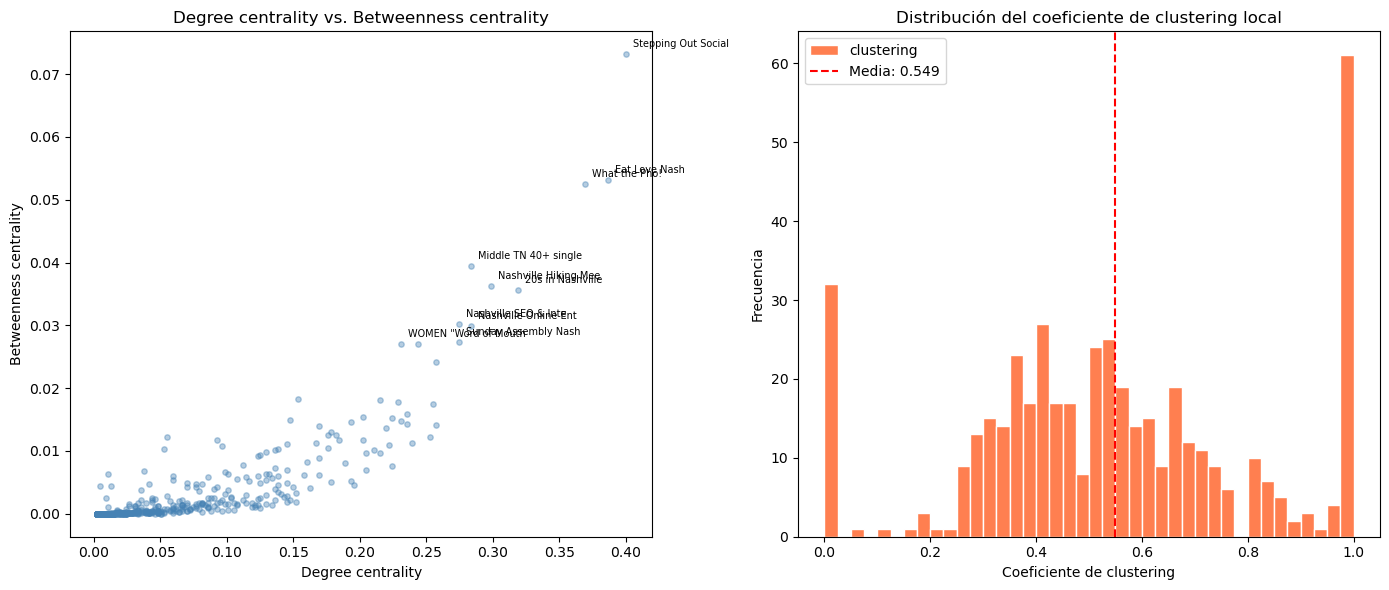

In [56]:
# Clustering local
clustering_G = nx.clustering(G)
centrality_df_G['clustering'] = centrality_df_G['node_id'].map(clustering_G)

print(f'Clustering medio global        : {centrality_df_G["clustering"].mean():.4f}')
print(f'Grupos con clustering = 1.0   : {(centrality_df_G["clustering"] == 1.0).sum()}')
print(f'Grupos con clustering < 0.5   : {(centrality_df_G["clustering"] < 0.5).sum()}')
print(f'Grupos con clustering = 0     : {(centrality_df_G["clustering"] == 0).sum()}')

print('\nTop 10 grupos con menor clustering:')
print(centrality_df_G.nsmallest(10, 'clustering')[
    ['group_name', 'category_name', 'num_members', 'degree_centrality', 'betweenness', 'clustering']
].to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter degree vs betweenness
axes[0].scatter(
    centrality_df_G['degree_centrality'],
    centrality_df_G['betweenness'],
    alpha=0.4, s=15, color='steelblue'
)
destacados_G = centrality_df_G.nlargest(10, 'betweenness')
for _, row in destacados_G.iterrows():
    axes[0].annotate(
        row['group_name'][:20],
        (row['degree_centrality'], row['betweenness']),
        fontsize=7, xytext=(5, 5), textcoords='offset points'
    )
axes[0].set_title('Degree centrality vs. Betweenness centrality')
axes[0].set_xlabel('Degree centrality')
axes[0].set_ylabel('Betweenness centrality')

# Distribución clustering
centrality_df_G['clustering'].plot(kind='hist', bins=40, ax=axes[1], 
                                    color='coral', edgecolor='white')
axes[1].axvline(centrality_df_G['clustering'].mean(), color='red', linestyle='--',
                label=f'Media: {centrality_df_G["clustering"].mean():.3f}')
axes[1].set_title('Distribución del coeficiente de clustering local')
axes[1].set_xlabel('Coeficiente de clustering')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

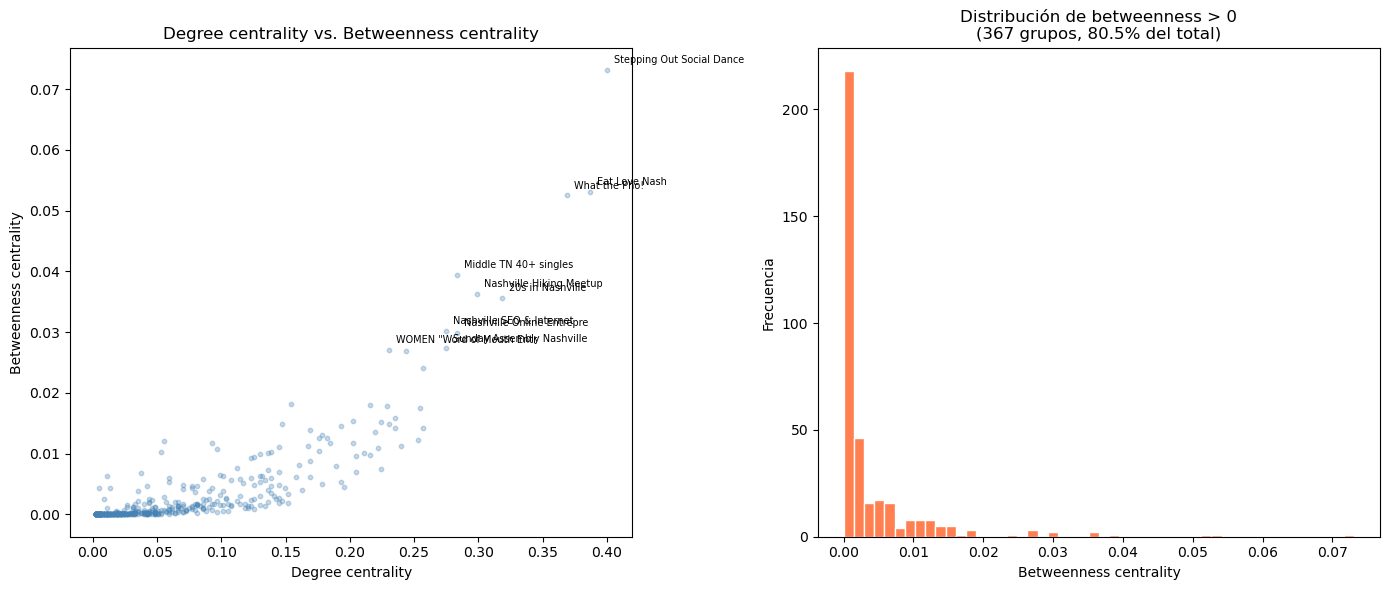

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Degree vs Betweenness scatter ---
axes[0].scatter(
    centrality_df_G['degree_centrality'],
    centrality_df_G['betweenness'],
    alpha=0.3, s=10, color='steelblue'
)

# Etiquetar los más interesantes (alto betweenness relativo a degree)
destacados_G = centrality_df_G.nlargest(10, 'betweenness')
for _, row in destacados_G.iterrows():
    axes[0].annotate(
        row['group_name'][:25] if pd.notna(row['group_name']) else 'Sin info',
        (row['degree_centrality'], row['betweenness']),
        fontsize=7, xytext=(5, 5), textcoords='offset points'
    )

axes[0].set_title('Degree centrality vs. Betweenness centrality')
axes[0].set_xlabel('Degree centrality')
axes[0].set_ylabel('Betweenness centrality')

# --- Gráfico 2: Distribución de betweenness (excluyendo zeros) ---
non_zero_G = centrality_df_G[centrality_df_G['betweenness'] > 0]['betweenness']
axes[1].hist(non_zero_G, bins=50, color='coral', edgecolor='white')
axes[1].set_title(f'Distribución de betweenness > 0\n({len(non_zero_G)} grupos, {len(non_zero_G)/len(centrality_df_G)*100:.1f}% del total)')
axes[1].set_xlabel('Betweenness centrality')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Clustering medio global                : 0.5488
Grupos con clustering = 1.0            : 61
Grupos con clustering < 0.5            : 200
Grupos con clustering < 0.1            : 33

Top 10 grupos con menor clustering:
                                                      group_name               category_name  num_members  clustering
295                                  Nashville Ladies' Book Club                  Book Clubs           47         0.0
340    Single Adult Ministry @ Brentwood United Methodist Church          Religion & Beliefs          459         0.0
344                         Nashville Krishna Bhakti Yoga Meetup          Health & Wellbeing           33         0.0
348                       Nashville Music Performance Playground                       Music           14         0.0
352                       20/30 something couples in Nashville!~                 Socializing          398         0.0
361                        Portuguese Language Club in Nashville  Language

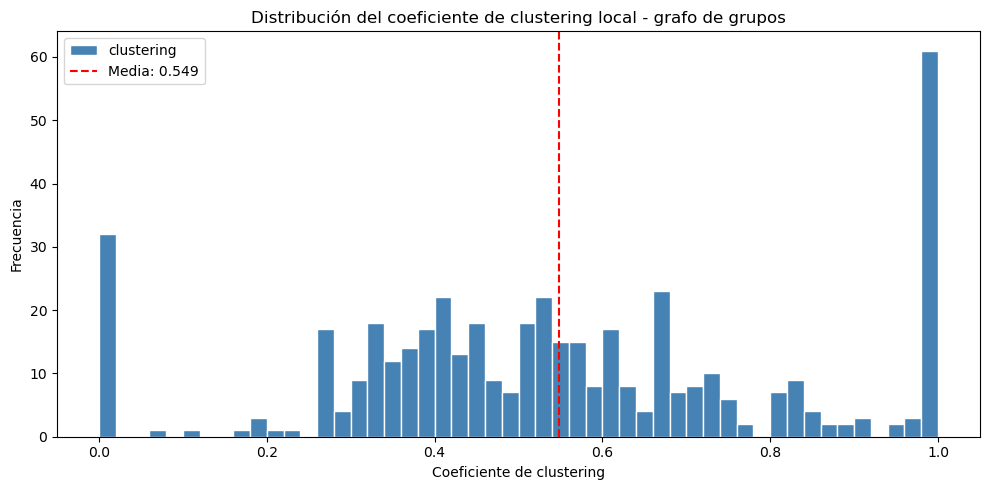

In [60]:
# Clustering local por nodo
local_clustering_G = nx.clustering(G)
clustering_df_G = pd.DataFrame({
    'node_id': list(local_clustering_G.keys()),
    'clustering': list(local_clustering_G.values())
}).merge(node_attrs_G, on='node_id', how='left')

print(f'Clustering medio global                : {clustering_df_G["clustering"].mean():.4f}')
print(f'Grupos con clustering = 1.0            : {(clustering_df_G["clustering"] == 1.0).sum()}')
print(f'Grupos con clustering < 0.5            : {(clustering_df_G["clustering"] < 0.5).sum()}')
print(f'Grupos con clustering < 0.1            : {(clustering_df_G["clustering"] < 0.1).sum()}')

print('\nTop 10 grupos con menor clustering:')
print(clustering_df_G.nsmallest(10, 'clustering')[
    ['group_name', 'category_name', 'num_members', 'clustering']
].to_string())

# Distribución
fig, ax = plt.subplots(figsize=(10, 5))
clustering_df_G['clustering'].plot(kind='hist', bins=50, color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Distribución del coeficiente de clustering local - grafo de grupos')
ax.set_xlabel('Coeficiente de clustering')
ax.set_ylabel('Frecuencia')
ax.axvline(clustering_df_G['clustering'].mean(), color='red', linestyle='--',
           label=f'Media: {clustering_df_G["clustering"].mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

In [61]:
from networkx.algorithms import community

# ── Louvain ────────────────────────────────────────────────────────────────
print('Detectando comunidades con Louvain...')

communities_louvain_G = community.louvain_communities(G, seed=42)
modularity_louvain_G = community.modularity(G, communities_louvain_G)

louvain_sizes_G = pd.Series([len(c) for c in communities_louvain_G]).sort_values(ascending=False)

print(f'Louvain — Comunidades detectadas : {len(louvain_sizes_G)}')
print(f'Louvain — Modularidad            : {modularity_louvain_G:.4f}')
print(f'Louvain — Tamaño medio           : {louvain_sizes_G.mean():.1f}')
print(f'Louvain — Comunidad más grande   : {louvain_sizes_G.max()}')
print(f'Louvain — Comunidad más pequeña  : {louvain_sizes_G.min()}')
print(f'Louvain — Comunidades < 10 nodos : {(louvain_sizes_G < 10).sum()}')

# ── Greedy Modularity ──────────────────────────────────────────────────────
print('\nDetectando comunidades con Greedy Modularity...')

communities_greedy_G = community.greedy_modularity_communities(G)
modularity_greedy_G = community.modularity(G, communities_greedy_G)

greedy_sizes_G = pd.Series([len(c) for c in communities_greedy_G]).sort_values(ascending=False)

print(f'Greedy — Comunidades detectadas  : {len(greedy_sizes_G)}')
print(f'Greedy — Modularidad             : {modularity_greedy_G:.4f}')
print(f'Greedy — Tamaño medio            : {greedy_sizes_G.mean():.1f}')
print(f'Greedy — Comunidad más grande    : {greedy_sizes_G.max()}')
print(f'Greedy — Comunidad más pequeña   : {greedy_sizes_G.min()}')
print(f'Greedy — Comunidades < 10 nodos  : {(greedy_sizes_G < 10).sum()}')

# ── Comparativa ────────────────────────────────────────────────────────────
print('\n' + '='*40)
print(f'{"Métrica":<25} {"Louvain":>10} {"Greedy":>10}')
print('-'*45)
print(f'{"Nº comunidades":<25} {len(louvain_sizes_G):>10} {len(greedy_sizes_G):>10}')
print(f'{"Modularidad":<25} {modularity_louvain_G:>10.4f} {modularity_greedy_G:>10.4f}')
print(f'{"Tamaño medio":<25} {louvain_sizes_G.mean():>10.1f} {greedy_sizes_G.mean():>10.1f}')
print(f'{"Comunidad máx":<25} {louvain_sizes_G.max():>10} {greedy_sizes_G.max():>10}')
print(f'{"Comunidades < 10":<25} {(louvain_sizes_G < 10).sum():>10} {(greedy_sizes_G < 10).sum():>10}')
print('='*40)

Detectando comunidades con Louvain...
Louvain — Comunidades detectadas : 6
Louvain — Modularidad            : 0.4427
Louvain — Tamaño medio           : 76.0
Louvain — Comunidad más grande   : 194
Louvain — Comunidad más pequeña  : 2
Louvain — Comunidades < 10 nodos : 2

Detectando comunidades con Greedy Modularity...
Greedy — Comunidades detectadas  : 9
Greedy — Modularidad             : 0.3729
Greedy — Tamaño medio            : 50.7
Greedy — Comunidad más grande    : 263
Greedy — Comunidad más pequeña   : 2
Greedy — Comunidades < 10 nodos  : 6

Métrica                      Louvain     Greedy
---------------------------------------------
Nº comunidades                     6          9
Modularidad                   0.4427     0.3729
Tamaño medio                    76.0       50.7
Comunidad máx                    194        263
Comunidades < 10                   2          6


In [62]:
# Crear mapping nodo -> comunidad para Louvain
node_to_community_G = {}
for i, comm in enumerate(communities_louvain_G):
    for node in comm:
        node_to_community_G[node] = i

# Añadir comunidad a centrality_df_G y clustering_df_G
centrality_df_G['community_louvain'] = centrality_df_G['node_id'].map(node_to_community_G)
clustering_df_G['community_louvain'] = clustering_df_G['node_id'].map(node_to_community_G)

# Estadísticas por comunidad
community_stats_G = centrality_df_G.groupby('community_louvain').agg(
    size=('node_id', 'count'),
    avg_degree=('degree_centrality', 'mean'),
    avg_betweenness=('betweenness', 'mean'),
    top_group=('group_name', lambda x: x.iloc[centrality_df_G.loc[x.index, 'degree_centrality'].argmax()]),
    main_category=('category_name', lambda x: x.value_counts().index[0])
).sort_values('community_louvain')

print('Estadísticas por comunidad (Louvain):')
print(community_stats_G.to_string())

Estadísticas por comunidad (Louvain):
                   size  avg_degree  avg_betweenness                         top_group           main_category
community_louvain                                                                                             
0                     2    0.003297         0.002198        Middle Tennessee WarGamers        Sci-Fi & Fantasy
1                   194    0.058661         0.003645  Stepping Out Social Dance Meetup             Socializing
2                    63    0.044898         0.001763          Nashville Psychic Meetup  New Age & Spirituality
3                     4    0.008242         0.002209      Christianity & Transhumanism      Religion & Beliefs
4                   106    0.064420         0.002852    Nashville Online Entrepreneurs       Career & Business
5                    87    0.095844         0.002819                Code for Nashville                    Tech


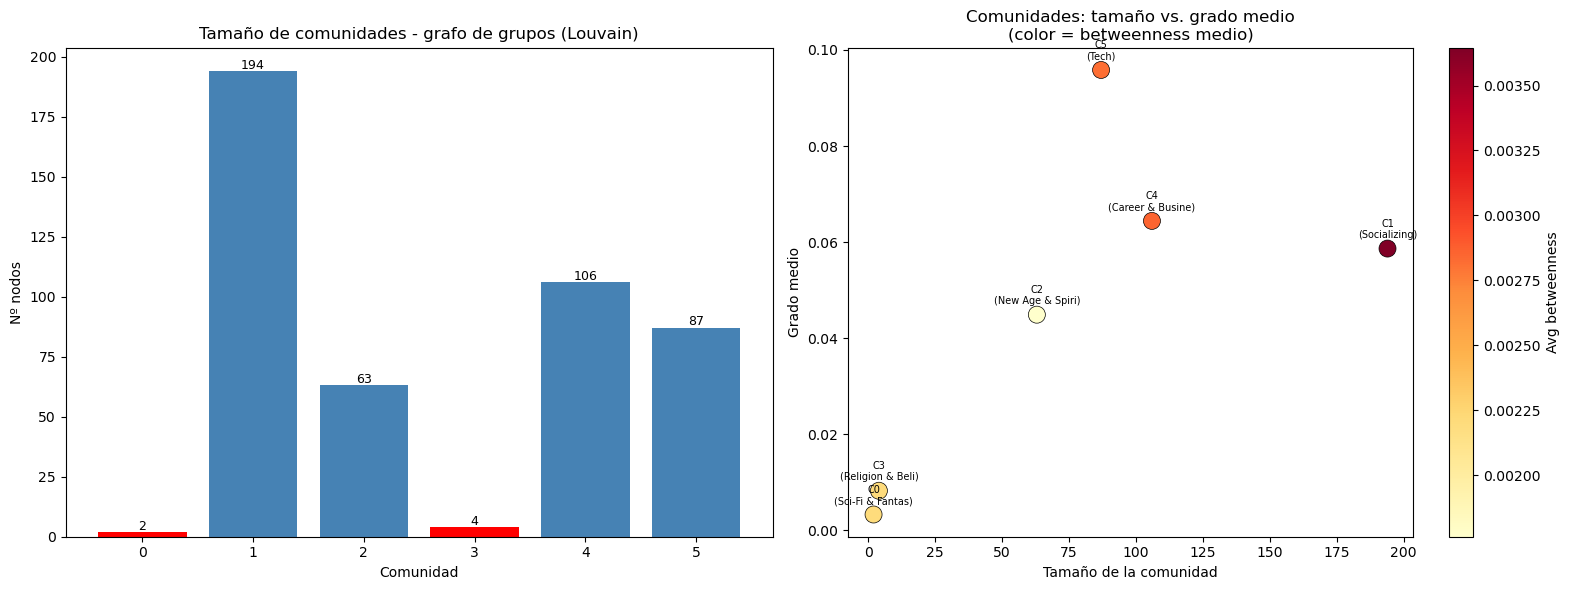

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Tamaño de comunidades ---
colors = ['red' if s < 10 else 'coral' if s < 50 else 'steelblue'
          for s in community_stats_G['size']]
axes[0].bar(community_stats_G.index, community_stats_G['size'], color=colors)
axes[0].set_title('Tamaño de comunidades - grafo de grupos (Louvain)')
axes[0].set_xlabel('Comunidad')
axes[0].set_ylabel('Nº nodos')
for i, (idx, row) in enumerate(community_stats_G.iterrows()):
    axes[0].text(idx, row['size'] + 1, str(row['size']),
                ha='center', fontsize=9)

# --- Gráfico 2: Scatter tamaño vs avg_degree coloreado por avg_betweenness ---
scatter = axes[1].scatter(
    community_stats_G['size'],
    community_stats_G['avg_degree'],
    c=community_stats_G['avg_betweenness'],
    cmap='YlOrRd',
    s=150,
    edgecolors='black',
    linewidths=0.5
)
plt.colorbar(scatter, ax=axes[1], label='Avg betweenness')

for idx, row in community_stats_G.iterrows():
    axes[1].annotate(f'C{idx}\n({row["main_category"][:15]})',
                    (row['size'], row['avg_degree']),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points')

axes[1].set_title('Comunidades: tamaño vs. grado medio\n(color = betweenness medio)')
axes[1].set_xlabel('Tamaño de la comunidad')
axes[1].set_ylabel('Grado medio')

plt.tight_layout()
plt.show()

Top 3 categorías por comunidad (nº de grupos):
    community_louvain            category_name  count
0                   0                    Games      1
1                   0         Sci-Fi & Fantasy      1
26                  1              Socializing     29
20                  1     Outdoors & Adventure     27
27                  1      Sports & Recreation     17
40                  2   New Age & Spirituality     20
36                  2       Health & Wellbeing     13
32                  2  Community & Environment      5
48                  3       Religion & Beliefs      2
47                  3     Education & Learning      1
49                  3                     Tech      1
51                  4        Career & Business     62
66                  4                     Tech      9
58                  4       Health & Wellbeing      6
79                  5                     Tech     72
68                  5        Career & Business      3
71                  5              

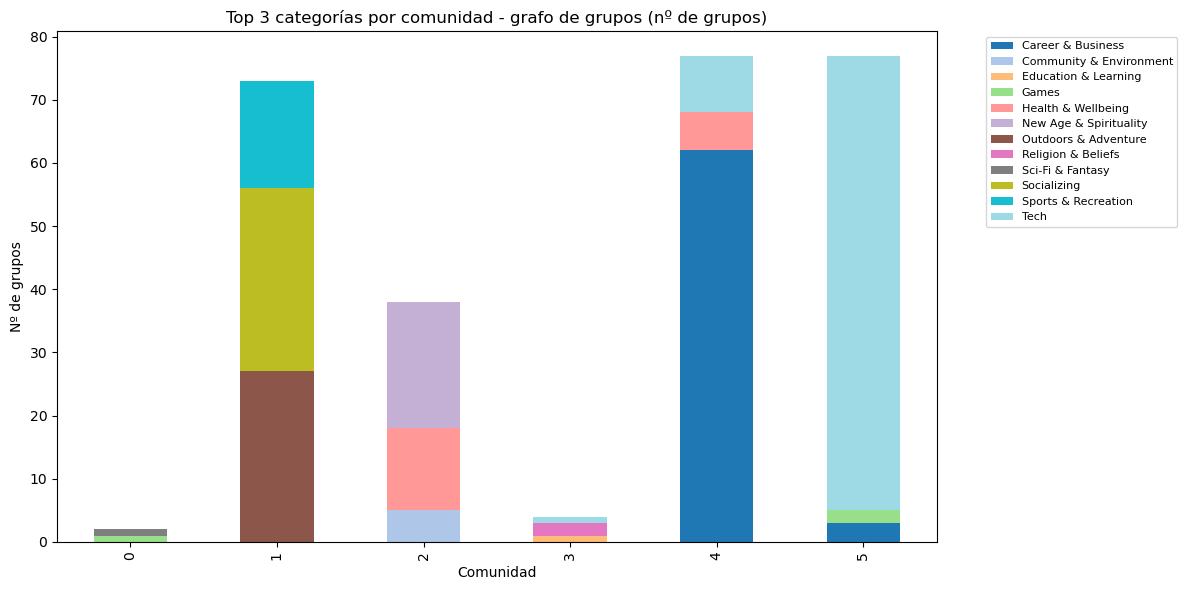

In [65]:
# ── Temática por comunidad (grafo de grupos) ───────────────────────────────

# Añadir comunidad a cada grupo
centrality_df_G['community_louvain'] = centrality_df_G['node_id'].map(node_to_community_G)

# Categoría dominante por comunidad (conteo de grupos)
community_themes_G = centrality_df_G.groupby(
    ['community_louvain', 'category_name']
)['node_id'].count().reset_index()
community_themes_G.columns = ['community_louvain', 'category_name', 'count']

# Top 3 categorías por comunidad
top_themes_G = community_themes_G.sort_values(
    ['community_louvain', 'count'], ascending=[True, False]
).groupby('community_louvain').head(3)

print('Top 3 categorías por comunidad (nº de grupos):')
print(top_themes_G.to_string())

# Tabla resumen
community_label_G = community_themes_G.sort_values(
    ['community_louvain', 'count'], ascending=[True, False]
).groupby('community_louvain').first().reset_index()
community_label_G.columns = ['community_louvain', 'main_category', 'main_count']

community_summary_G = community_label_G.merge(
    community_stats_G[['size', 'avg_degree', 'avg_betweenness', 'top_group']].reset_index(),
    on='community_louvain'
)

print('\nResumen de comunidades Louvain con temática dominante:')
print(community_summary_G[['community_louvain', 'main_category', 'size',
                            'avg_degree', 'avg_betweenness', 'top_group']].to_string())

# Visualización: barras apiladas top 3 categorías por comunidad
pivot_themes_G = top_themes_G.pivot_table(
    index='community_louvain', columns='category_name',
    values='count', fill_value=0
)

pivot_themes_G.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Top 3 categorías por comunidad - grafo de grupos (nº de grupos)')
plt.xlabel('Comunidad')
plt.ylabel('Nº de grupos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [66]:
# Añadir comunidad Louvain como atributo de nodo
nx.set_node_attributes(G, node_to_community_G, name='community_louvain')

# Verificar
sample_nodes_G = list(G.nodes(data=True))[:3]
print('Verificación de atributos de nodo:')
for node, attrs in sample_nodes_G:
    print(f'  Nodo {node}: {attrs}')

# Crear carpeta si no existe y guardar
output_path_G = "../graphs/graphml_cluster/group_graph_cluster.graphml"
os.makedirs(os.path.dirname(output_path_G), exist_ok=True)
nx.write_graphml(G, output_path_G)
print(f'\nGrafo guardado correctamente en: {output_path_G}')

Verificación de atributos de nodo:
  Nodo 19292162: {'group_name': 'Nashville CocoaHeads', 'num_members': 237, 'category_id': 34, 'category_name': 'Tech', 'organizer_id': 145632652, 'group_urlname': 'Nashville-CocoaHeads', 'community_louvain': 5}
  Nodo 535553: {'group_name': 'Nash.rb', 'num_members': 881, 'category_id': 34, 'category_name': 'Tech', 'organizer_id': 14344641, 'group_urlname': 'nashrb', 'community_louvain': 5}
  Nodo 19194894: {'group_name': 'Nashville Christian Technologists and Entrepreneurs', 'num_members': 613, 'category_id': 34, 'category_name': 'Tech', 'organizer_id': 193181718, 'group_urlname': 'Nashville-Christian-Technologists-and-Entrepreneurs', 'community_louvain': 5}

Grafo guardado correctamente en: ../graphs/graphml_cluster/group_graph_cluster.graphml


Aristas con peso             : 6692
Aristas sin peso             : 0

Estadísticas de pesos:
count    6692.000000
mean        2.301853
std         4.089973
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        91.000000
dtype: float64

Aristas con peso = 1         : 4432 (66.2%)
Aristas con peso > 50        : 7 (0.1%)
Aristas con peso > 100       : 0 (0.0%)

Top 10 aristas por peso:
                                group1 category1                    group2 category2  weight
180   Stepping Out Social Dance Meetup   Dancing     Middle TN 40+ singles   Singles      91
1767                Code for Nashville      Tech                    NashJS      Tech      75
382                          NashReact      Tech                    NashJS      Tech      66
1536                            PyNash      Tech                    NashJS      Tech      65
1342         Nashville .NET User Group      Tech                    NashJS      Tech      64
1852           

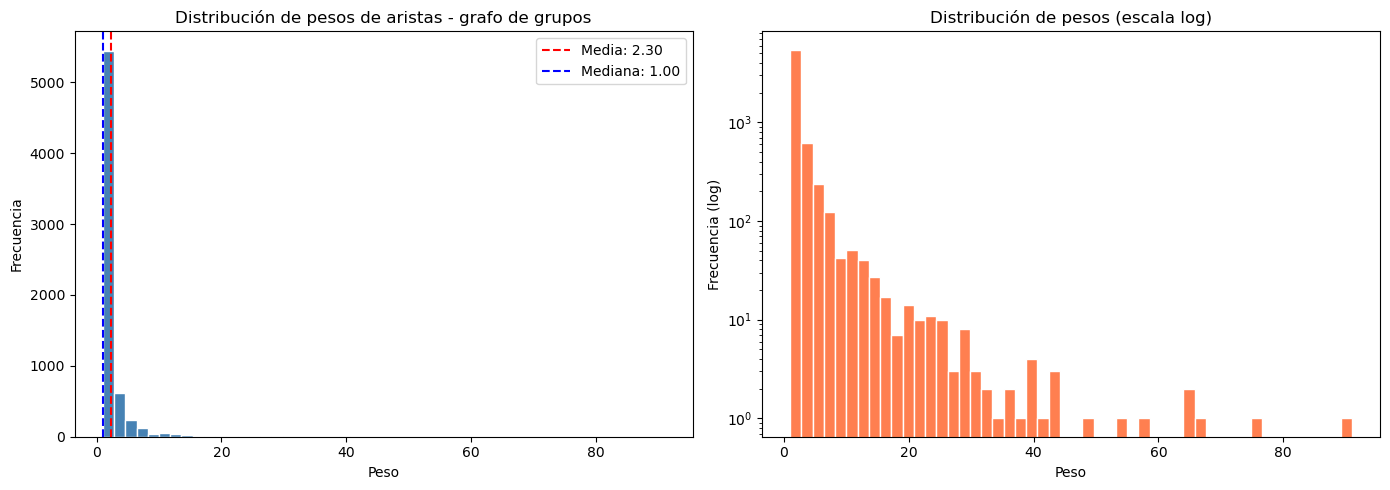

In [70]:
# ── Análisis de pesos de aristas - grafo de grupos ────────────────────────

edge_weights_G = [data['weight'] for _, _, data in G.edges(data=True) if 'weight' in data]

print(f'Aristas con peso             : {len(edge_weights_G)}')
print(f'Aristas sin peso             : {len(G.edges) - len(edge_weights_G)}')

weight_series_G = pd.Series(edge_weights_G)
print(f'\nEstadísticas de pesos:')
print(weight_series_G.describe())
print(f'\nAristas con peso = 1         : {(weight_series_G == 1).sum()} ({(weight_series_G == 1).sum()/len(weight_series_G)*100:.1f}%)')
print(f'Aristas con peso > 50        : {(weight_series_G > 50).sum()} ({(weight_series_G > 50).sum()/len(weight_series_G)*100:.1f}%)')
print(f'Aristas con peso > 100       : {(weight_series_G > 100).sum()} ({(weight_series_G > 100).sum()/len(weight_series_G)*100:.1f}%)')

# Top 10 aristas por peso
edge_list_G = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if 'weight' in d]
edge_df_G = pd.DataFrame(edge_list_G, columns=['node1', 'node2', 'weight'])

# Enriquecer con nombres de grupos
edge_df_G = edge_df_G.merge(
    node_attrs_G[['node_id', 'group_name', 'category_name']].rename(
        columns={'group_name': 'group1', 'category_name': 'category1'}),
    left_on='node1', right_on='node_id', how='left'
).drop('node_id', axis=1)

edge_df_G = edge_df_G.merge(
    node_attrs_G[['node_id', 'group_name', 'category_name']].rename(
        columns={'group_name': 'group2', 'category_name': 'category2'}),
    left_on='node2', right_on='node_id', how='left'
).drop('node_id', axis=1)

print('\nTop 10 aristas por peso:')
print(edge_df_G.nlargest(10, 'weight')[['group1', 'category1', 'group2', 'category2', 'weight']].to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weight_series_G.plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de pesos de aristas - grafo de grupos')
axes[0].set_xlabel('Peso')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(weight_series_G.mean(), color='red', linestyle='--',
                label=f'Media: {weight_series_G.mean():.2f}')
axes[0].axvline(weight_series_G.median(), color='blue', linestyle='--',
                label=f'Mediana: {weight_series_G.median():.2f}')
axes[0].legend()

weight_series_G.plot(kind='hist', bins=50, ax=axes[1], color='coral',
                     edgecolor='white', log=True)
axes[1].set_title('Distribución de pesos (escala log)')
axes[1].set_xlabel('Peso')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

Correlación de Pearson  : r=0.5476, p=0.0000
Correlación de Spearman : r=0.6663, p=0.0000


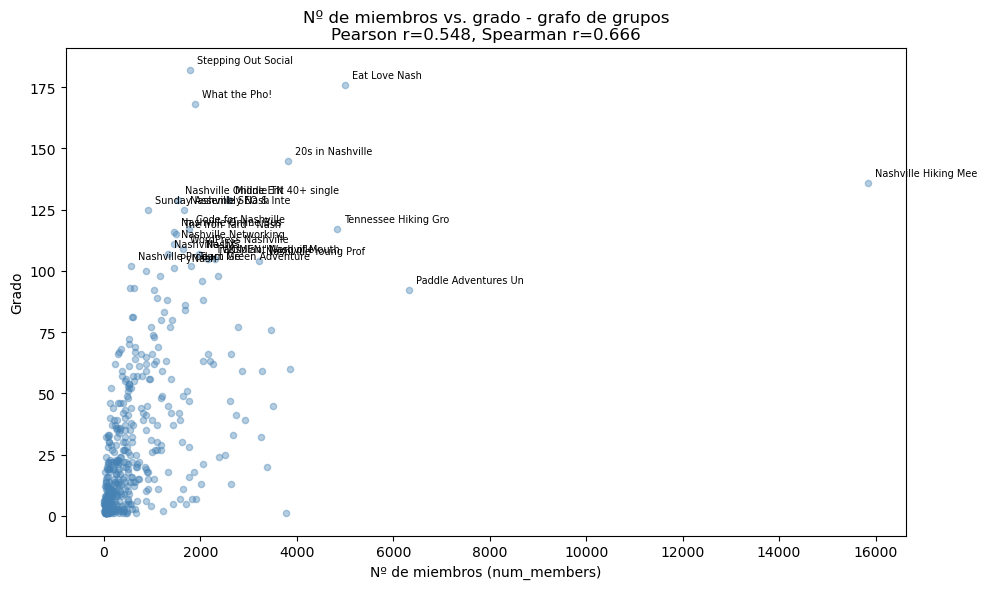

In [72]:
# ── Correlación num_members vs. grado - grafo de grupos ───────────────────
from scipy import stats

# num_members ya está en degree_df_G
degree_df_G['num_members'] = pd.to_numeric(degree_df_G['num_members'], errors='coerce')

pearson_r, pearson_p = stats.pearsonr(
    degree_df_G['degree'].dropna(),
    degree_df_G['num_members'].dropna()
)
spearman_r, spearman_p = stats.spearmanr(
    degree_df_G['degree'].dropna(),
    degree_df_G['num_members'].dropna()
)

print(f'Correlación de Pearson  : r={pearson_r:.4f}, p={pearson_p:.4f}')
print(f'Correlación de Spearman : r={spearman_r:.4f}, p={spearman_p:.4f}')

# Scatter num_members vs grado
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(degree_df_G['num_members'], degree_df_G['degree'],
           alpha=0.4, s=20, color='steelblue')

# Etiquetar outliers interesantes
outliers = degree_df_G[
    (degree_df_G['degree'] > 100) | 
    (degree_df_G['num_members'] > 5000)
]
for _, row in outliers.iterrows():
    ax.annotate(row['group_name'][:20],
                (row['num_members'], row['degree']),
                fontsize=7, xytext=(5, 5), textcoords='offset points')

ax.set_title('Nº de miembros vs. grado - grafo de grupos\n'
             f'Pearson r={pearson_r:.3f}, Spearman r={spearman_r:.3f}')
ax.set_xlabel('Nº de miembros (num_members)')
ax.set_ylabel('Grado')
plt.tight_layout()
plt.show()

Estadísticas de inter_community_ratio - grafo de grupos:
count    456.000000
mean       0.296788
std        0.214299
min        0.000000
25%        0.136057
50%        0.301515
75%        0.456398
max        0.842105
Name: inter_community_ratio, dtype: float64

Grupos con ratio = 0   : 90
Grupos con ratio > 0.5 : 74
Grupos con ratio = 1.0 : 0

Top 10 grupos puente (mayor ratio inter-comunidad):
                                                      group_name           category_name  num_members  degree_centrality  betweenness  inter_community_ratio  community_louvain
124                         Lesbians in the Workplace, Nashville                    LGBT          567           0.083516     0.001393               0.842105                  2
141               Events of the Camera Club Council of Tennessee             Photography          318           0.026374     0.001513               0.833333                  4
120                         Nashville Shambhala Meditation Group      Heal

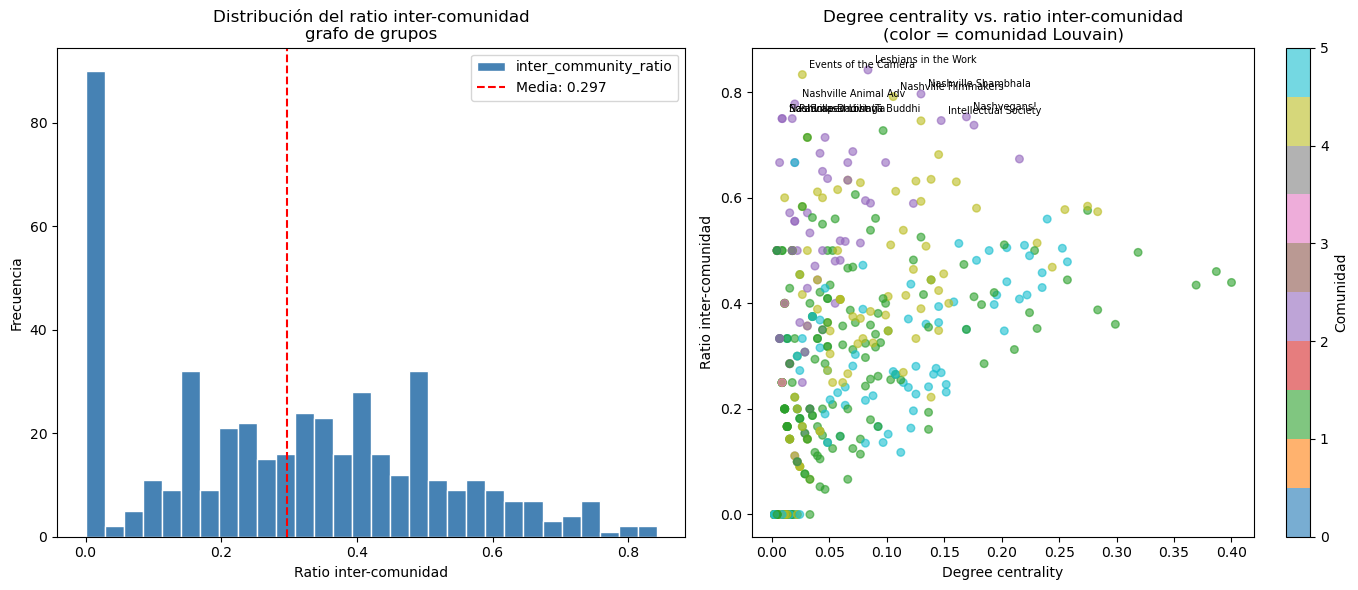

In [76]:
# ── Nodos puente entre comunidades - grafo de grupos ──────────────────────
inter_ratio_G = {node: inter_community_ratio(G, node, node_to_community_G)
                 for node in G.nodes()}

centrality_df_G['inter_community_ratio'] = centrality_df_G['node_id'].map(inter_ratio_G)

print('Estadísticas de inter_community_ratio - grafo de grupos:')
print(centrality_df_G['inter_community_ratio'].describe())
print(f'\nGrupos con ratio = 0   : {(centrality_df_G["inter_community_ratio"] == 0).sum()}')
print(f'Grupos con ratio > 0.5 : {(centrality_df_G["inter_community_ratio"] > 0.5).sum()}')
print(f'Grupos con ratio = 1.0 : {(centrality_df_G["inter_community_ratio"] == 1.0).sum()}')

print('\nTop 10 grupos puente (mayor ratio inter-comunidad):')
print(centrality_df_G.nlargest(10, 'inter_community_ratio')[
    ['group_name', 'category_name', 'num_members', 'degree_centrality', 
     'betweenness', 'inter_community_ratio', 'community_louvain']
].to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

centrality_df_G['inter_community_ratio'].plot(
    kind='hist', bins=30, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].axvline(centrality_df_G['inter_community_ratio'].mean(),
                color='red', linestyle='--',
                label=f'Media: {centrality_df_G["inter_community_ratio"].mean():.3f}')
axes[0].set_title('Distribución del ratio inter-comunidad\ngrafo de grupos')
axes[0].set_xlabel('Ratio inter-comunidad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

scatter = axes[1].scatter(
    centrality_df_G['degree_centrality'],
    centrality_df_G['inter_community_ratio'],
    c=centrality_df_G['community_louvain'],
    cmap='tab10',
    alpha=0.6,
    s=30
)
top_bridges_G = centrality_df_G.nlargest(10, 'inter_community_ratio')
for _, row in top_bridges_G.iterrows():
    axes[1].annotate(
        row['group_name'][:20] if pd.notna(row['group_name']) else 'Sin info',
        (row['degree_centrality'], row['inter_community_ratio']),
        fontsize=7, xytext=(5, 5), textcoords='offset points'
    )
axes[1].set_title('Degree centrality vs. ratio inter-comunidad\n(color = comunidad Louvain)')
axes[1].set_xlabel('Degree centrality')
axes[1].set_ylabel('Ratio inter-comunidad')
plt.colorbar(scatter, ax=axes[1], label='Comunidad')
plt.tight_layout()
plt.show()

# EDA — Grafo de Grupos

## 1. Estadísticas básicas

El grafo de grupos contiene **456 nodos y 6.692 aristas**. De los 602 grupos presentes en `meta_groups`, solo el **75.7% aparece en el grafo** — los 146 grupos restantes (24.3%) no comparten ningún miembro con otros grupos y quedan completamente aislados, constituyendo el primer conjunto de candidatos a anomalía estructural. El grafo es **completamente conexo** (una única componente), lo que indica que todos los grupos presentes están conectados entre sí de alguna forma.

## 2. Métricas básicas

La **densidad del grafo es de 0.0645**, casi cuatro veces superior a la del grafo de miembros (0.0182), lo que indica que los grupos comparten miembros entre sí con más frecuencia de lo que los miembros se conectan entre ellos. El **grado medio es de 29.35**, con un rango que va de 1 a 182. El **coeficiente de clustering medio es de 0.5488**, significativamente inferior al del grafo de miembros (0.885), lo que refleja que los grupos forman comunidades menos cohesionadas que los miembros — hay más diversidad en las conexiones entre grupos de distintas categorías temáticas.

## 3. Distribución de grado

La distribución de grado presenta asimetría positiva, con una media (29) superior a la mediana (18) y una desviación típica (32) mayor que la media, lo que refleja una gran variabilidad. La segmentación por cuartiles revela la siguiente estructura: 28 grupos hoja (grado = 1), 206 grupos de grado bajo (2-18), 109 grupos de grado medio (19-42), 90 grupos de grado alto (43-100) y 23 super-conectores con grado superior a 100.

Los **28 grupos hoja** son proporcionalmente más que en el grafo de miembros (13), e incluyen grupos muy específicos y de nicho como Nashville ColdFusion User Group (41 miembros, Tech) o Nashville League of Legends (94 miembros, Games), que no comparten prácticamente ningún miembro con otros grupos.

## 4. Análisis de nodos extremos

**Stepping Out Social Dance Meetup** es el grupo más conectado con grado 182, a pesar de tener solo 1.778 miembros — sus miembros asisten a una gran variedad de otros grupos. En contraste, **Nashville Hiking Meetup**, con 15.838 miembros, tiene un grado de solo 136, lo que indica que sus miembros son relativamente exclusivos del grupo y no se distribuyen tanto por otros. Este contraste ilustra que el tamaño de un grupo no determina su conectividad en la red.

## 5. Métricas de centralidad

A diferencia del grafo de miembros, en el grafo de grupos existe una **correlación positiva clara entre degree y betweenness** — los grupos más conectados son también los que más actúan como puentes, sin casos donde la betweenness sea desproporcionada respecto al degree.

**Stepping Out Social Dance Meetup** lidera en ambas métricas (degree centrality 0.400, betweenness 0.073), seguido de **Eat Love Nash** (0.387, 0.053) y **What the Pho!** (0.369, 0.053). Es llamativo que **Sunday Assembly Nashville** (Religion & Beliefs, 918 miembros) aparezca en el top 10 de ambas métricas — una comunidad religiosa actuando como puente entre mundos temáticos muy distintos.

Solo **89 grupos (19.5%) tienen betweenness = 0**, frente al 72.5% en el grafo de miembros. En el grafo de grupos la mayoría de nodos ejercen algún rol de puente, lo que refleja una red estructuralmente más democrática.

## 6. Coeficiente de clustering local

La distribución del clustering local es muy distinta a la del grafo de miembros. En lugar de una distribución bimodal concentrada en 0 y 1, aquí la distribución es **más uniforme**, con grupos en todos los rangos de clustering. Hay **61 grupos con clustering = 1.0** (cliques perfectos, probablemente grupos de la misma categoría temática muy específica) y **33 grupos con clustering < 0.1**, entre los que destacan casos como Nashville Children in Nature (654 miembros) con clustering = 0 — un grupo grande pero completamente aislado estructuralmente.

## 7. Análisis de pesos de aristas

Las aristas del grafo de grupos representan el número de miembros compartidos entre dos grupos. La distribución de pesos es más rica que en el grafo de miembros: aunque la mediana es también 1, la **media es 2.30** (vs. 1.05 en miembros) y el rango va de 1 a **91**, frente al máximo de 9 del grafo de miembros. Solo el 66.2% de las aristas tienen peso = 1, frente al 95.9% en el grafo de miembros, lo que indica que las conexiones entre grupos son más sustanciales.

El análisis de las aristas más pesadas revela dos patrones muy claros. El primero es el **hub tecnológico de NashJS**: este grupo aparece en 6 de las 10 aristas más fuertes, actuando como núcleo central de la comunidad Tech de Nashville — Code for Nashville, NashReact, PyNash, Nashville .NET, Nashville UX y Nashville Software Beginners convergen en él, lo que explica el altísimo clustering de la comunidad Tech (C5). El segundo es el **vínculo inter-categoría más fuerte de toda la red**: Stepping Out Social Dance Meetup ↔ Middle TN 40+ singles con peso 91, conectando Dancing con Singles — dos categorías temáticamente distintas pero sociodemográficamente muy similares (adultos buscando actividades sociales).

## 8. Correlación num_members vs. grado

La correlación entre el número de miembros de un grupo y su grado en la red es **moderada-alta pero no perfecta** (Pearson r=0.548, Spearman r=0.666, ambas estadísticamente significativas). La diferencia entre ambas correlaciones indica la presencia de outliers que distorsionan la relación lineal.

El scatter confirma visualmente dos tipos de anomalías: grupos **grandes pero poco conectados** como Nashville Hiking Meetup (15.838 miembros, grado 136) o Paddle Adventures Unlimited (6.331 miembros, grado ~93), cuyos miembros son relativamente exclusivos del grupo; y grupos **pequeños pero muy conectados** como Stepping Out Social Dance Meetup (1.778 miembros, grado 182), cuyos miembros se distribuyen por una gran variedad de otros grupos. La conclusión es que los grupos sociales y de ocio generalista son mejores conectores que los grupos de actividades masivas específicas, independientemente de su tamaño.

## 9. Detección de comunidades

Se aplicaron Louvain y Greedy Modularity sobre el grafo de grupos. Louvain obtuvo una modularidad de **0.4427** frente a los 0.3729 de Greedy, detectando 6 comunidades frente a las 9 de Greedy. La modularidad es sensiblemente inferior a la del grafo de miembros (0.6755), lo que confirma que las comunidades de grupos están menos bien definidas — los grupos se conectan entre categorías temáticas con más frecuencia que los miembros entre comunidades.

| Métrica | Louvain | Greedy |
|---|---|---|
| Nº comunidades | 6 | 9 |
| Modularidad | 0.4427 | 0.3729 |
| Tamaño medio | 76.0 | 50.7 |
| Comunidad más grande | 194 | 263 |
| Comunidades < 10 nodos | 2 | 6 |

## 10. Análisis de comunidades Louvain

Las 6 comunidades detectadas tienen temáticas dominantes bien definidas. **C1 (Socializing, 194 nodos)** es la más grande y heterogénea, mezclando Socializing, Outdoors & Adventure y Sports & Recreation. **C4 (Career & Business, 106 nodos)** y **C5 (Tech, 87 nodos)** son las más puras temáticamente — C5 concentra 72 de sus 87 grupos en Tech y presenta el mayor grado medio de todas las comunidades (0.096), confirmando que los grupos tecnológicos están extremadamente interconectados. **C2 (New Age & Spirituality, 63 nodos)** combina espiritualidad y salud de forma coherente.

Las anomalías más llamativas son **C0 (2 nodos, Games + Sci-Fi & Fantasy)** y **C3 (4 nodos, Religion & Beliefs)**, microcomunidades prácticamente aisladas con betweenness = 0. C3 es especialmente peculiar al tener "Christianity & Transhumanism" como grupo más relevante — una combinación temática muy inusual.

## 11. Análisis de nodos puente entre comunidades

El ratio inter-comunidad medio del grafo de grupos es **0.297**, significativamente superior al del grafo de miembros (0.181), coherente con la menor modularidad del grafo. La distribución es más uniforme, sin la bimodalidad clara observada en miembros.

El hallazgo más llamativo es que **8 de los 10 grupos con mayor ratio inter-comunidad pertenecen a la comunidad C2** (New Age & Spirituality), lo que la convierte en la comunidad que más conexiones exporta hacia otras comunidades. Grupos como Lesbians in the Workplace (LGBT, ratio 0.842), Nashvegans! (Movements & Politics, 0.753) o Intellectual Society of Greater Nashville (Education & Learning, 0.746) tienen temáticas transversales que naturalmente atraen a miembros de comunidades muy distintas.

## 12. Relevancia para detección de anomalías

El análisis del grafo de grupos aporta varios conjuntos de candidatos a anomalía para la fase de modelado. Los **146 grupos ausentes del grafo** son los más aislados del ecosistema. Los **28 grupos hoja** tienen conectividad mínima. Los grupos con **desajuste entre tamaño y grado** — Nashville Hiking Meetup y Stepping Out Social Dance en extremos opuestos — representan comportamientos atípicos respecto a la correlación general. Las **microcomunidades C0 y C3** son anomalías a nivel de subgrafo. Finalmente, **NashJS** como hub tecnológico extremo y el vínculo Stepping Out ↔ Middle TN 40+ singles como arista de peso anómalamente alto son candidatos a anomalía de arista.

In [10]:
import pandas as pd
import networkx as nx
# Leer el csv
DATA_PATH = '../data/processed/'

member_group_edges = pd.read_csv(os.path.join(DATA_PATH, 'member-to-group-edges.csv'))
meta_members = pd.read_csv(os.path.join(DATA_PATH, 'meta-members.csv'))
meta_groups = pd.read_csv(os.path.join(DATA_PATH, 'meta-groups.csv'))


# Prefijar ids para evitar colisiones
member_group_edges['member_id'] = 'member_' + member_group_edges['member_id'].astype(str)
member_group_edges['group_id'] = 'group_' + member_group_edges['group_id'].astype(str)

# Construir grafo bipartito
MG = nx.from_pandas_edgelist(
    member_group_edges,
    source='member_id',
    target='group_id',
    edge_attr='weight'
)

# Marcar los nodos con su tipo (importante para análisis bipartito)
member_nodes = [n for n in MG.nodes() if n.startswith('member_')]
group_nodes = [n for n in MG.nodes() if n.startswith('group_')]

nx.set_node_attributes(MG, {n: 0 for n in member_nodes}, name='bipartite')
nx.set_node_attributes(MG, {n: 1 for n in group_nodes}, name='bipartite')

# Añadir atributos de meta_members
meta_members['member_id'] = 'member_' + meta_members['member_id'].astype(str)
meta_members = meta_members.set_index('member_id').to_dict('index')
nx.set_node_attributes(MG, meta_members)

# Añadir atributos de meta_groups
meta_groups['group_id'] = 'group_' + meta_groups['group_id'].astype(str)
meta_groups = meta_groups.set_index('group_id').to_dict('index')
nx.set_node_attributes(MG, meta_groups)

# Verificar
print(f'Nodos totales  : {len(MG.nodes())}')
print(f'Nodos miembro  : {len(member_nodes)}')
print(f'Nodos grupo    : {len(group_nodes)}')
print(f'Aristas        : {len(MG.edges())}')
print(f'Es bipartito   : {nx.is_bipartite(MG)}')

Nodos totales  : 25233
Nodos miembro  : 24631
Nodos grupo    : 602
Aristas        : 45583
Es bipartito   : True


In [4]:
nx.is_connected(MG)

False

Tienes razón, no estaba explicitado con suficiente claridad. Aquí va el markdown actualizado con esa aclaración incorporada de forma explícita y natural, y con la no conexidad del bipartito añadida:

---

# Inconsistencias entre grafos: limitaciones del dataset

## 1. Descripción del problema

El dataset de Meetup Tennessee proporciona tres tipos de grafos construidos a partir de distintas fuentes de datos: el grafo de miembros (`member-edges.csv`), el grafo de grupos (`group-edges.csv`) y el grafo bipartito miembro-grupo (`member-to-group-edges.csv`). Al comparar el número de nodos entre estos grafos y los metadatos originales, se observan inconsistencias significativas que es necesario documentar y tener en cuenta en cualquier análisis posterior.

| Fuente | Nodos miembro | Nodos grupo |
|---|---|---|
| `meta_members` | 24.591 | — |
| `meta_groups` | — | 602 |
| Grafo bipartito (`MG`) | 24.631 | 602 |
| Grafo de miembros (`M`) | 11.372 | — |
| Grafo de grupos (`G`) | — | 456 |

## 2. Inconsistencia en los nodos de miembro

### 2.1 Diferencia entre meta_members y el grafo bipartito

El grafo bipartito contiene **24.631 nodos de miembro**, mientras que `meta_members` registra **24.591 miembros**. La diferencia de 40 miembros indica que existen miembros presentes en `member-to-group-edges.csv` que no tienen correspondencia en los metadatos. Estos 40 miembros tienen relaciones registradas con grupos pero carecen de información de perfil (nombre, ciudad, estado, coordenadas), lo que constituye una **anomalía de integridad referencial** del dataset.

### 2.2 Diferencia entre el grafo bipartito y el grafo de miembros

La inconsistencia más importante es la que existe entre el grafo bipartito (24.631 nodos de miembro) y el grafo de miembros (11.372 nodos). Es decir, **solo el 46.2% de los miembros del bipartito aparecen en el grafo de miembros**.

La causa fundamental de esta discrepancia es que **`member-edges.csv` únicamente registra pares de miembros que tienen co-membresía en algún grupo — no incluye nodos aislados**. Es decir, los miembros que no comparten ningún grupo con otro miembro del dataset simplemente no aparecen en el fichero de aristas y, por tanto, tampoco en el grafo de miembros. No se trata de un error de construcción del grafo, sino de una decisión de diseño del dataset: al construir el grafo de miembros solo se han materializado las aristas, sin añadir explícitamente los nodos sin conexiones para mantener la totalidad de la población.

Los aproximadamente **13.000 miembros ausentes** pertenecen a grupos pero no comparten esa membresía con ningún otro miembro registrado en el dataset. Son, en la práctica, nodos aislados desde el punto de vista de la red de miembros, y su inclusión en el grafo no aportaría ninguna arista ni información estructural adicional — simplemente inflaría el número de nodos sin enriquecer el análisis topológico. Su ausencia, sin embargo, sí sesga las métricas globales del grafo hacia valores más altos de conectividad de lo que correspondería si se incluyera a toda la población.

Este fenómeno tiene además una explicación plausible en el contexto del dataset: dado que la extracción cubre únicamente los grupos de Tennessee y una selección de sus miembros, es probable que muchos miembros compartan grupos exclusivamente con otros miembros que no fueron incluidos en la extracción original.

## 3. Inconsistencia en los nodos de grupo

### 3.1 Diferencia entre meta_groups y el grafo bipartito

El grafo bipartito contiene **602 nodos de grupo**, cifra que coincide exactamente con `meta_groups`. En este caso no hay inconsistencia — todos los grupos con metadatos tienen al menos una relación registrada con algún miembro en el bipartito.

### 3.2 Diferencia entre el grafo bipartito y el grafo de grupos

El grafo de grupos contiene únicamente **456 nodos**, frente a los 602 del bipartito y los metadatos. Los **146 grupos ausentes** (24.3%) no aparecen en `group-edges.csv` por la misma razón estructural que en el caso de los miembros: **`group-edges.csv` solo registra pares de grupos que comparten al menos un miembro — no incluye nodos aislados**. Los 146 grupos ausentes no comparten ningún miembro con otros grupos dentro del dataset y, por tanto, no generan ninguna arista en el grafo de grupos. Al igual que con los miembros, su inclusión como nodos aislados no aportaría información topológica pero sí distorsionaría las métricas globales.

## 4. No conexidad del grafo bipartito

A diferencia del grafo de miembros y del grafo de grupos, que son completamente conexos, el **grafo bipartito no es conexo** (`nx.is_connected(MG)` devuelve `False`). Esto es consistente con todo lo anterior: el bipartito incluye a todos los miembros y grupos, entre ellos aquellos que no comparten co-membresía con ningún otro nodo del dataset. Estos nodos quedan como componentes aisladas o en componentes muy pequeñas, desconectadas de la componente principal.

Esta no conexidad es esperable y no constituye un error de construcción — es la consecuencia directa de incluir en el bipartito a miembros y grupos que en los grafos proyectados (miembros y grupos) habrían quedado excluidos por no generar aristas. La componente principal del bipartito concentra la gran mayoría de los nodos y es sobre ella donde tiene sentido realizar los análisis estructurales.

## 5. Implicaciones para el análisis

Estas inconsistencias tienen implicaciones directas sobre los análisis realizados y deben tenerse en cuenta al interpretar los resultados:

**Sobre el grafo de miembros:** las métricas calculadas (grado, centralidad, clustering, comunidades) son representativas únicamente del 46.2% de los miembros del dataset — aquellos con al menos una co-membresía registrada. Los ~13.000 miembros ausentes son, por definición, los más periféricos de la red y su exclusión sesga las métricas globales hacia valores más altos de conectividad.

**Sobre el grafo de grupos:** el 24.3% de los grupos ausentes son precisamente los más aislados del ecosistema, lo que significa que las métricas del grafo de grupos también están sesgadas hacia grupos más conectados. Los 146 grupos ausentes constituyen por sí mismos un conjunto de anomalías estructurales — grupos que no comparten ningún miembro con el resto de la red.

**Sobre el grafo bipartito:** es el grafo más completo y representativo del dataset, ya que incluye prácticamente a todos los miembros y todos los grupos. Es la fuente más adecuada para análisis que requieran una visión global de las relaciones entre miembros y grupos, aunque debe tenerse en cuenta su no conexidad al aplicar algoritmos que asuman conectividad global.

## 6. Decisión metodológica

Ante estas inconsistencias, se opta por **mantener los tres grafos con sus nodos originales** sin forzar ningún tipo de filtrado o enriquecimiento artificial, por las siguientes razones. En primer lugar, cada grafo responde a una pregunta analítica distinta y los análisis realizados sobre cada uno son internamente consistentes. En segundo lugar, forzar la homogeneización entre grafos implicaría añadir nodos aislados al grafo de miembros o al grafo de grupos, lo que distorsionaría las métricas globales sin aportar información real. En tercer lugar, las inconsistencias son en sí mismas un hallazgo relevante del EDA: los miembros y grupos ausentes de sus respectivos grafos son los candidatos más claros a anomalía estructural del dataset, y su identificación es valiosa para la fase de modelado.

Esta decisión se documenta explícitamente como una **limitación del dataset** que debe considerarse al interpretar cualquier resultado obtenido a partir de los grafos de miembros y grupos.

In [21]:
# Leer el csv
DATA_PATH = '../data/processed/'

member_group_edges = pd.read_csv(os.path.join(DATA_PATH, 'member-to-group-edges.csv'))
meta_members = pd.read_csv(os.path.join(DATA_PATH, 'meta-members.csv'))
meta_groups = pd.read_csv(os.path.join(DATA_PATH, 'meta-groups.csv'))

In [22]:
# ── Estadísticas básicas del grafo bipartito ──────────────────────────────
from networkx.algorithms import bipartite

print('--- Métricas básicas del grafo bipartito ---')
print(f'Nodos totales          : {len(MG.nodes()):,}')
print(f'Nodos miembro          : {len(member_nodes):,}')
print(f'Nodos grupo            : {len(group_nodes):,}')
print(f'Aristas                : {len(MG.edges()):,}')
print(f'Densidad               : {bipartite.density(MG, member_nodes):.4f}')
print(f'Es bipartito           : {nx.is_bipartite(MG)}')
print(f'Es conexo              : {nx.is_connected(MG)}')
print(f'Nº componentes conexas : {nx.number_connected_components(MG)}')

# Análisis de componentes conexas
components = sorted(nx.connected_components(MG), key=len, reverse=True)
print(f'\nComponente principal   : {len(components[0]):,} nodos')
print(f'Componentes pequeñas   : {len(components[1:])}')
print(f'Tamaño componentes pequeñas:')
small_comp_sizes = pd.Series([len(c) for c in components[1:]])
print(small_comp_sizes.describe())
print(f'\nComponentes de 1 nodo  : {(small_comp_sizes == 1).sum()}')
print(f'Componentes de 2 nodos : {(small_comp_sizes == 2).sum()}')
print(f'Componentes de 3+ nodos: {(small_comp_sizes >= 3).sum()}')

--- Métricas básicas del grafo bipartito ---
Nodos totales          : 25,233
Nodos miembro          : 24,631
Nodos grupo            : 602
Aristas                : 45,583
Densidad               : 0.0031
Es bipartito           : True
Es conexo              : False
Nº componentes conexas : 25

Componente principal   : 25,171 nodos
Componentes pequeñas   : 24
Tamaño componentes pequeñas:
count    24.000000
mean      2.583333
std       1.380506
min       2.000000
25%       2.000000
50%       2.000000
75%       2.000000
max       7.000000
dtype: float64

Componentes de 1 nodo  : 0
Componentes de 2 nodos : 19
Componentes de 3+ nodos: 5


In [23]:
# Identificar componentes pequeñas
small_components = [c for c in components[1:]]

print('Detalle de componentes pequeñas:')
for i, comp in enumerate(small_components):
    members_in_comp = [n for n in comp if n.startswith('member_')]
    groups_in_comp = [n for n in comp if n.startswith('group_')]
    
    # Obtener nombres de grupos
    group_names = []
    for g in groups_in_comp:
        group_id = int(g.replace('group_', ''))
        name = meta_groups[meta_groups['group_id'] == group_id]['group_name'].values
        group_names.append(name[0] if len(name) > 0 else 'Sin información')
    
    print(f'\n  Componente {i+1}: {len(comp)} nodos '
          f'({len(members_in_comp)} miembros, {len(groups_in_comp)} grupos)')
    print(f'  Grupos: {group_names}')

Detalle de componentes pequeñas:

  Componente 1: 7 nodos (6 miembros, 1 grupos)
  Grupos: ['Hendersonville Volunteering Meetup']

  Componente 2: 6 nodos (5 miembros, 1 grupos)
  Grupos: ['Pure Storage Middle Tennessee']

  Componente 3: 5 nodos (4 miembros, 1 grupos)
  Grupos: ["It's All About Travel Nashville"]

  Componente 4: 3 nodos (2 miembros, 1 grupos)
  Grupos: ['Bible Reading']

  Componente 5: 3 nodos (2 miembros, 1 grupos)
  Grupos: ['Nashville Adventurers']

  Componente 6: 2 nodos (1 miembros, 1 grupos)
  Grupos: ['The Geek Set - Nashville']

  Componente 7: 2 nodos (1 miembros, 1 grupos)
  Grupos: ['Nashville Social Media Enthusiasts']

  Componente 8: 2 nodos (1 miembros, 1 grupos)
  Grupos: ['The Nashville Taiji Club']

  Componente 9: 2 nodos (1 miembros, 1 grupos)
  Grupos: ['Nashville Co-Ed Kickball']

  Componente 10: 2 nodos (1 miembros, 1 grupos)
  Grupos: ['Nashville Craft Party']

  Componente 11: 2 nodos (1 miembros, 1 grupos)
  Grupos: ['Project Worship']

 

--- Estadísticas de grado - nodos miembro ---
count    24631.000000
mean         1.850635
std          1.947436
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         42.000000
dtype: float64

Miembros con grado = 1 (un solo grupo)  : 16422 (66.7%)
Miembros con grado > 10                 : 212 (0.9%)
Miembros con grado > 20                 : 25 (0.1%)

--- Estadísticas de grado - nodos grupo ---
count    602.000000
mean      75.719269
std      128.336558
min        1.000000
25%        7.000000
50%       24.000000
75%       82.250000
max      951.000000
dtype: float64

Grupos con grado = 1 (un solo miembro)  : 37 (6.1%)
Grupos con grado > 1000                 : 0 (0.0%)
Grupos con grado > 5000                 : 0 (0.0%)


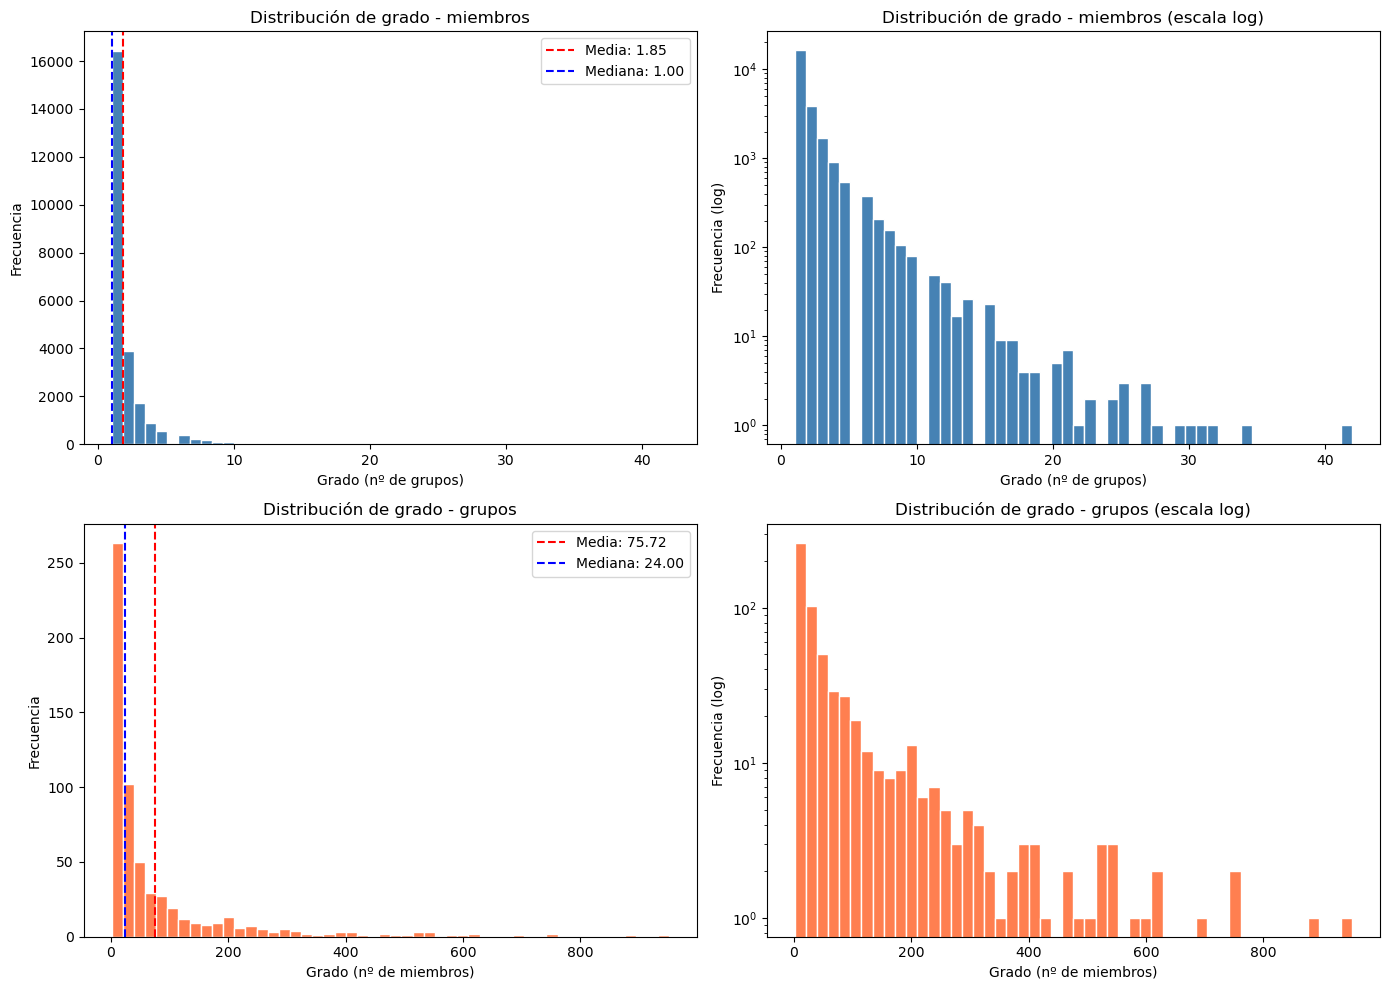

In [26]:
# ── Distribución de grado por tipo de nodo ────────────────────────────────

# Grado de miembros y grupos por separado
degree_members = {n: MG.degree(n) for n in member_nodes}
degree_groups = {n: MG.degree(n) for n in group_nodes}

degree_members_series = pd.Series(degree_members.values())
degree_groups_series = pd.Series(degree_groups.values())

print('--- Estadísticas de grado - nodos miembro ---')
print(degree_members_series.describe())
print(f'\nMiembros con grado = 1 (un solo grupo)  : {(degree_members_series == 1).sum()} ({(degree_members_series == 1).sum()/len(degree_members_series)*100:.1f}%)')
print(f'Miembros con grado > 10                 : {(degree_members_series > 10).sum()} ({(degree_members_series > 10).sum()/len(degree_members_series)*100:.1f}%)')
print(f'Miembros con grado > 20                 : {(degree_members_series > 20).sum()} ({(degree_members_series > 20).sum()/len(degree_members_series)*100:.1f}%)')

print('\n--- Estadísticas de grado - nodos grupo ---')
print(degree_groups_series.describe())
print(f'\nGrupos con grado = 1 (un solo miembro)  : {(degree_groups_series == 1).sum()} ({(degree_groups_series == 1).sum()/len(degree_groups_series)*100:.1f}%)')
print(f'Grupos con grado > 1000                 : {(degree_groups_series > 1000).sum()} ({(degree_groups_series > 1000).sum()/len(degree_groups_series)*100:.1f}%)')
print(f'Grupos con grado > 5000                 : {(degree_groups_series > 5000).sum()} ({(degree_groups_series > 5000).sum()/len(degree_groups_series)*100:.1f}%)')

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Miembros - histograma normal
degree_members_series.plot(kind='hist', bins=50, ax=axes[0][0], 
                           color='steelblue', edgecolor='white')
axes[0][0].axvline(degree_members_series.mean(), color='red', linestyle='--',
                   label=f'Media: {degree_members_series.mean():.2f}')
axes[0][0].axvline(degree_members_series.median(), color='blue', linestyle='--',
                   label=f'Mediana: {degree_members_series.median():.2f}')
axes[0][0].set_title('Distribución de grado - miembros')
axes[0][0].set_xlabel('Grado (nº de grupos)')
axes[0][0].set_ylabel('Frecuencia')
axes[0][0].legend()

# Miembros - escala log
degree_members_series.plot(kind='hist', bins=50, ax=axes[0][1],
                           color='steelblue', edgecolor='white', log=True)
axes[0][1].set_title('Distribución de grado - miembros (escala log)')
axes[0][1].set_xlabel('Grado (nº de grupos)')
axes[0][1].set_ylabel('Frecuencia (log)')

# Grupos - histograma normal
degree_groups_series.plot(kind='hist', bins=50, ax=axes[1][0],
                          color='coral', edgecolor='white')
axes[1][0].axvline(degree_groups_series.mean(), color='red', linestyle='--',
                   label=f'Media: {degree_groups_series.mean():.2f}')
axes[1][0].axvline(degree_groups_series.median(), color='blue', linestyle='--',
                   label=f'Mediana: {degree_groups_series.median():.2f}')
axes[1][0].set_title('Distribución de grado - grupos')
axes[1][0].set_xlabel('Grado (nº de miembros)')
axes[1][0].set_ylabel('Frecuencia')
axes[1][0].legend()

# Grupos - escala log
degree_groups_series.plot(kind='hist', bins=50, ax=axes[1][1],
                          color='coral', edgecolor='white', log=True)
axes[1][1].set_title('Distribución de grado - grupos (escala log)')
axes[1][1].set_xlabel('Grado (nº de miembros)')
axes[1][1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

In [30]:
# Top 10 miembros por nº de grupos
degree_members_df = pd.DataFrame({
    'node_id': list(degree_members.keys()),
    'degree': list(degree_members.values())
})
degree_members_df['member_id'] = degree_members_df['node_id'].str.replace('member_', '')

degree_members_df = degree_members_df.merge(
    meta_members[['member_id', 'name', 'city', 'state']].astype({'member_id': str}),
    on='member_id', how='left'
)

# Top 10 grupos por nº de miembros
degree_groups_df = pd.DataFrame({
    'node_id': list(degree_groups.keys()),
    'degree': list(degree_groups.values())
})
degree_groups_df['group_id'] = degree_groups_df['node_id'].str.replace('group_', '').astype(int)
degree_groups_df = degree_groups_df.merge(
    meta_groups[['group_id', 'group_name', 'category_name']],
    on='group_id', how='left'
)

print('Top 10 miembros por nº de grupos:')
print(degree_members_df.nlargest(10, 'degree')[
    ['name', 'city', 'state', 'degree']
].to_string())

print('\nTop 10 grupos por nº de miembros:')
print(degree_groups_df.nlargest(10, 'degree')[
    ['group_name', 'category_name', 'degree']
].to_string())

print('\nMiembros con grado = 1:')
print(f'  {(degree_members_series == 1).sum()} miembros ({(degree_members_series == 1).sum()/len(degree_members_series)*100:.1f}%)')

print('\nGrupos con grado = 1:')
print(f'  {(degree_groups_series == 1).sum()} grupos ({(degree_groups_series == 1).sum()/len(degree_groups_series)*100:.1f}%)')

Top 10 miembros por nº de grupos:
                       name       city state  degree
1503                Shalini  Nashville    TN      42
304           Matt Kenigson  Nashville    TN      34
366   Taylor Michael Matson  Nashville    TN      32
731                     Rav  Nashville    TN      31
2010       Michelle McManus  Nashville    TN      30
1466                  Pablo  Nashville    TN      29
4343        David Prochaska  Nashville    TN      28
1281                  Jim H  Nashville    TN      27
1625                Theresa  Nashville    TN      27
3282           David VanWie  Nashville    TN      27

Top 10 grupos por nº de miembros:
                                    group_name         category_name  degree
242                           20s in Nashville           Socializing     951
14                     Nashville Hiking Meetup  Outdoors & Adventure     878
40                                      NashJS                  Tech     760
18            Stepping Out Social Dance 

Estadísticas del ratio de actividad (miembros activos / miembros registrados):
count    602.000000
mean       0.172470
std        0.137430
min        0.000747
25%        0.063034
50%        0.138889
75%        0.243559
max        0.888889
Name: activity_ratio, dtype: float64

Grupos con ratio > 0.5 (más del 50% activos): 17
Grupos con ratio < 0.1 (menos del 10% activos): 226

Top 10 grupos con mayor ratio de actividad:
                                       group_name               category_name  num_members  active_members  activity_ratio
195          T-VOE: Tennessee Voice Over Exchange              Arts & Culture           72              64        0.888889
408                    Black Women Read Book Club                  Book Clubs           35              23        0.657143
416           Tennessee Red Hat User Group (RHUG)                        Tech           81              53        0.654321
301                   Nashville Blockchain Meetup                        Tech        

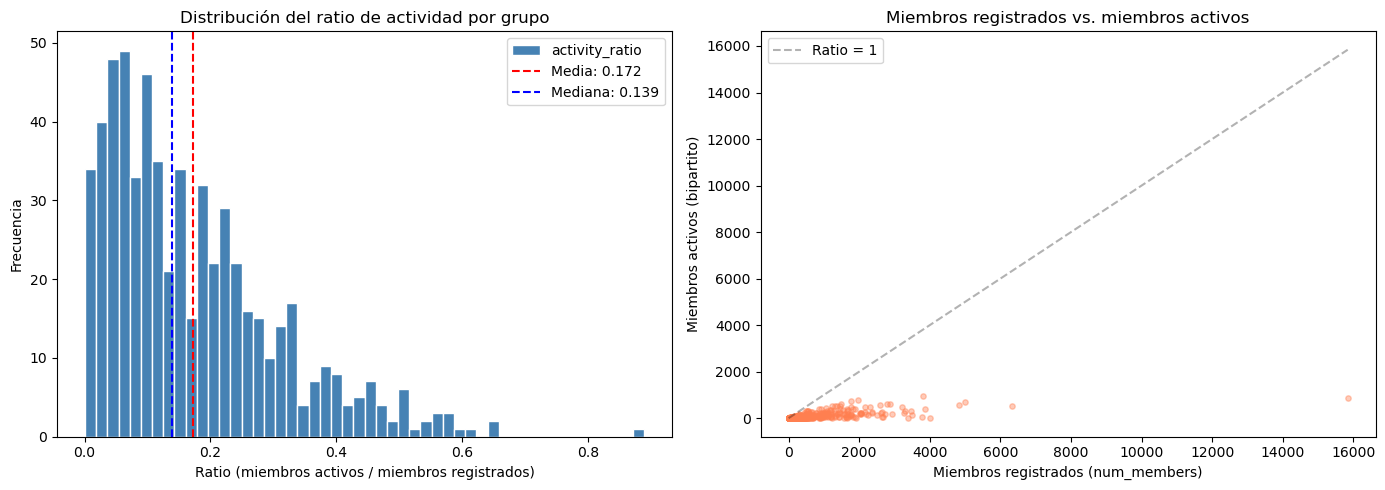

In [32]:
# ── Comparativa miembros registrados vs activos ───────────────────────────
comparison_df = degree_groups_df[['group_id', 'group_name', 'category_name', 'degree']].copy()
comparison_df.columns = ['group_id', 'group_name', 'category_name', 'active_members']

comparison_df = comparison_df.merge(
    meta_groups[['group_id', 'num_members']],
    on='group_id', how='left'
)

comparison_df['activity_ratio'] = comparison_df['active_members'] / comparison_df['num_members']

print('Estadísticas del ratio de actividad (miembros activos / miembros registrados):')
print(comparison_df['activity_ratio'].describe())

print(f'\nGrupos con ratio > 0.5 (más del 50% activos): {(comparison_df["activity_ratio"] > 0.5).sum()}')
print(f'Grupos con ratio < 0.1 (menos del 10% activos): {(comparison_df["activity_ratio"] < 0.1).sum()}')

print('\nTop 10 grupos con mayor ratio de actividad:')
print(comparison_df.nlargest(10, 'activity_ratio')[
    ['group_name', 'category_name', 'num_members', 'active_members', 'activity_ratio']
].to_string())

print('\nTop 10 grupos con menor ratio de actividad:')
print(comparison_df.nsmallest(10, 'activity_ratio')[
    ['group_name', 'category_name', 'num_members', 'active_members', 'activity_ratio']
].to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución del ratio de actividad
comparison_df['activity_ratio'].plot(kind='hist', bins=50, ax=axes[0],
                                      color='steelblue', edgecolor='white')
axes[0].axvline(comparison_df['activity_ratio'].mean(), color='red', linestyle='--',
                label=f'Media: {comparison_df["activity_ratio"].mean():.3f}')
axes[0].axvline(comparison_df['activity_ratio'].median(), color='blue', linestyle='--',
                label=f'Mediana: {comparison_df["activity_ratio"].median():.3f}')
axes[0].set_title('Distribución del ratio de actividad por grupo')
axes[0].set_xlabel('Ratio (miembros activos / miembros registrados)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Scatter num_members vs active_members
axes[1].scatter(comparison_df['num_members'], comparison_df['active_members'],
                alpha=0.4, s=15, color='coral')
axes[1].plot([0, comparison_df['num_members'].max()],
             [0, comparison_df['num_members'].max()],
             'k--', alpha=0.3, label='Ratio = 1')
axes[1].set_title('Miembros registrados vs. miembros activos')
axes[1].set_xlabel('Miembros registrados (num_members)')
axes[1].set_ylabel('Miembros activos (bipartito)')
axes[1].legend()

plt.tight_layout()
plt.show()

Aristas con peso             : 45,583
Aristas sin peso             : 0

Estadísticas de pesos (eventos asistidos):
count    45583.000000
mean         2.782024
std          6.698376
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        200.000000
dtype: float64

Aristas con peso = 1         : 27,588 (60.5%)
Aristas con peso > 10        : 1,717 (3.8%)
Aristas con peso > 50        : 156 (0.3%)
Aristas con peso > 100       : 49 (0.1%)

Top 10 aristas por peso (eventos asistidos):
              member_name                                       group_name           category_name  weight
26615      Dustin Hedrick                                     Drink-n-Draw          Arts & Culture     200
29882  Unity of Nashville     Unity of Nashville Spirituality Meetup Group  New Age & Spirituality     200
44342       Nicole Taylor                       Women of Purpose and Power      Religion & Beliefs     200
43195          Doug Betty           Tennessee 

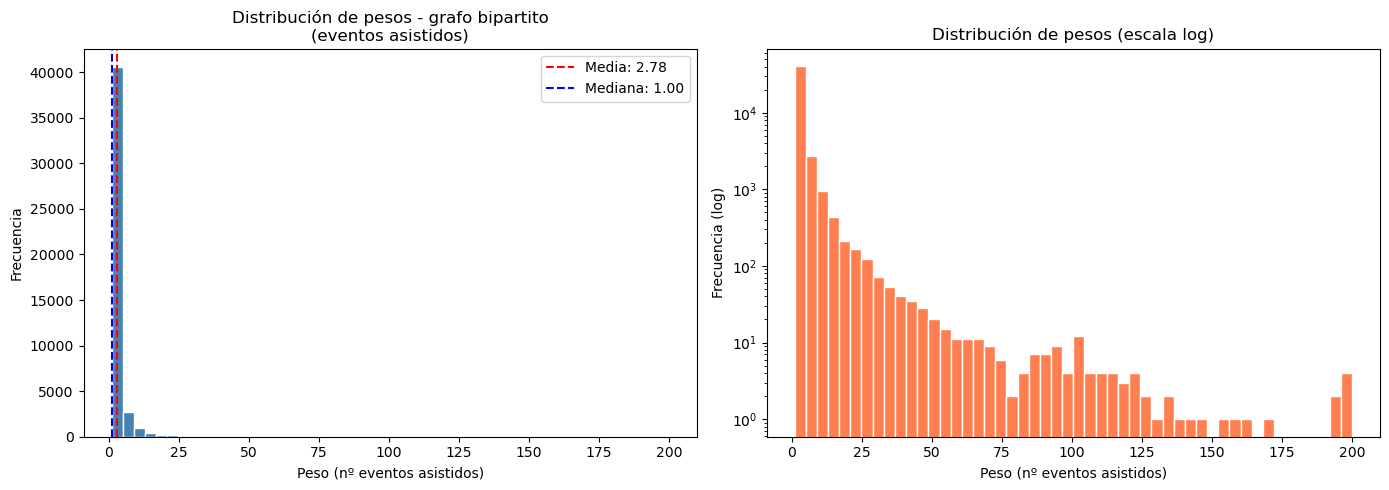

In [34]:
# ── Análisis de pesos de aristas - grafo bipartito ────────────────────────
edge_weights_MG = [data['weight'] for _, _, data in MG.edges(data=True) if 'weight' in data]
weight_series_MG = pd.Series(edge_weights_MG)

print(f'Aristas con peso             : {len(edge_weights_MG):,}')
print(f'Aristas sin peso             : {len(MG.edges()) - len(edge_weights_MG):,}')
print(f'\nEstadísticas de pesos (eventos asistidos):')
print(weight_series_MG.describe())
print(f'\nAristas con peso = 1         : {(weight_series_MG == 1).sum():,} ({(weight_series_MG == 1).sum()/len(weight_series_MG)*100:.1f}%)')
print(f'Aristas con peso > 10        : {(weight_series_MG > 10).sum():,} ({(weight_series_MG > 10).sum()/len(weight_series_MG)*100:.1f}%)')
print(f'Aristas con peso > 50        : {(weight_series_MG > 50).sum():,} ({(weight_series_MG > 50).sum()/len(weight_series_MG)*100:.1f}%)')
print(f'Aristas con peso > 100       : {(weight_series_MG > 100).sum():,} ({(weight_series_MG > 100).sum()/len(weight_series_MG)*100:.1f}%)')

# Top 10 aristas por peso
edge_list_MG = [(u, v, d['weight']) for u, v, d in MG.edges(data=True) if 'weight' in d]
edge_df_MG = pd.DataFrame(edge_list_MG, columns=['node1', 'node2', 'weight'])

# Separar miembros y grupos
edge_df_MG['member_id'] = edge_df_MG.apply(
    lambda r: r['node1'].replace('member_', '') if r['node1'].startswith('member_') 
    else r['node2'].replace('member_', ''), axis=1)
edge_df_MG['group_id'] = edge_df_MG.apply(
    lambda r: int(r['node1'].replace('group_', '')) if r['node1'].startswith('group_') 
    else int(r['node2'].replace('group_', '')), axis=1)

# Enriquecer con nombres
edge_df_MG = edge_df_MG.merge(
    meta_members[['member_id', 'name']].astype({'member_id': str}).rename(columns={'name': 'member_name'}),
    on='member_id', how='left'
)
edge_df_MG = edge_df_MG.merge(
    meta_groups[['group_id', 'group_name', 'category_name']],
    on='group_id', how='left'
)

print('\nTop 10 aristas por peso (eventos asistidos):')
print(edge_df_MG.nlargest(10, 'weight')[
    ['member_name', 'group_name', 'category_name', 'weight']
].to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weight_series_MG.plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(weight_series_MG.mean(), color='red', linestyle='--',
                label=f'Media: {weight_series_MG.mean():.2f}')
axes[0].axvline(weight_series_MG.median(), color='blue', linestyle='--',
                label=f'Mediana: {weight_series_MG.median():.2f}')
axes[0].set_title('Distribución de pesos - grafo bipartito\n(eventos asistidos)')
axes[0].set_xlabel('Peso (nº eventos asistidos)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

weight_series_MG.plot(kind='hist', bins=50, ax=axes[1], color='coral',
                      edgecolor='white', log=True)
axes[1].set_title('Distribución de pesos (escala log)')
axes[1].set_xlabel('Peso (nº eventos asistidos)')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

Estadísticas de actividad por miembro:
       total_events    num_groups  avg_events_per_group  \
count  24631.000000  24631.000000          24631.000000   
mean       5.148512      1.850635              2.759752   
std       12.058991      1.947436              6.499330   
min        1.000000      1.000000              1.000000   
25%        1.000000      1.000000              1.000000   
50%        2.000000      1.000000              1.000000   
75%        4.000000      2.000000              2.000000   
max      513.000000     42.000000            200.000000   

       max_events_single_group  
count             24631.000000  
mean                  3.627137  
std                   8.592006  
min                   1.000000  
25%                   1.000000  
50%                   1.000000  
75%                   3.000000  
max                 200.000000  

Miembros con total_events = 1    : 10834 (44.0%)
Miembros con total_events > 50   : 251 (1.0%)
Miembros con total_events > 100  : 6

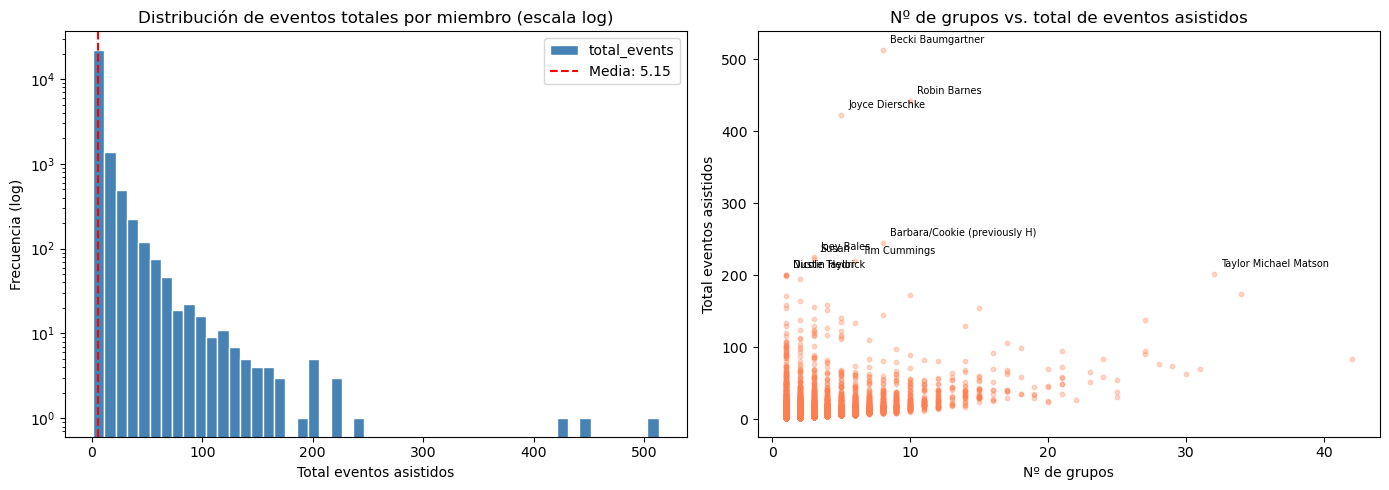

In [35]:
# ── Análisis de actividad por miembro ─────────────────────────────────────

# Peso total por miembro (total de eventos asistidos)
member_activity = edge_df_MG.groupby('member_id').agg(
    total_events=('weight', 'sum'),
    num_groups=('group_id', 'count'),
    avg_events_per_group=('weight', 'mean'),
    max_events_single_group=('weight', 'max')
).reset_index()

member_activity = member_activity.merge(
    meta_members[['member_id', 'name', 'city', 'state']].astype({'member_id': str}),
    on='member_id', how='left'
)

print('Estadísticas de actividad por miembro:')
print(member_activity[['total_events', 'num_groups', 
                        'avg_events_per_group', 'max_events_single_group']].describe())

print(f'\nMiembros con total_events = 1    : {(member_activity["total_events"] == 1).sum()} ({(member_activity["total_events"] == 1).sum()/len(member_activity)*100:.1f}%)')
print(f'Miembros con total_events > 50   : {(member_activity["total_events"] > 50).sum()} ({(member_activity["total_events"] > 50).sum()/len(member_activity)*100:.1f}%)')
print(f'Miembros con total_events > 100  : {(member_activity["total_events"] > 100).sum()} ({(member_activity["total_events"] > 100).sum()/len(member_activity)*100:.1f}%)')

print('\nTop 10 miembros por total de eventos asistidos:')
print(member_activity.nlargest(10, 'total_events')[
    ['name', 'city', 'state', 'total_events', 'num_groups', 'avg_events_per_group']
].to_string())

print('\nTop 10 miembros por media de eventos por grupo:')
print(member_activity[member_activity['num_groups'] >= 3].nlargest(10, 'avg_events_per_group')[
    ['name', 'city', 'state', 'total_events', 'num_groups', 'avg_events_per_group']
].to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución total_events
member_activity['total_events'].plot(kind='hist', bins=50, ax=axes[0],
                                      color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Distribución de eventos totales por miembro (escala log)')
axes[0].set_xlabel('Total eventos asistidos')
axes[0].set_ylabel('Frecuencia (log)')
axes[0].axvline(member_activity['total_events'].mean(), color='red', linestyle='--',
                label=f'Media: {member_activity["total_events"].mean():.2f}')
axes[0].legend()

# Scatter num_groups vs total_events
axes[1].scatter(member_activity['num_groups'], member_activity['total_events'],
                alpha=0.3, s=10, color='coral')
axes[1].set_title('Nº de grupos vs. total de eventos asistidos')
axes[1].set_xlabel('Nº de grupos')
axes[1].set_ylabel('Total eventos asistidos')

# Etiquetar top 10
top_members = member_activity.nlargest(10, 'total_events')
for _, row in top_members.iterrows():
    axes[1].annotate(row['name'] if pd.notna(row['name']) else 'Sin info',
                     (row['num_groups'], row['total_events']),
                     fontsize=7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

Distribución de perfiles de actividad:
perfil
Normal                                         13444
Inactivo (1 evento)                            10834
Explorador (muchos grupos, baja asistencia)      151
Fiel (pocos grupos, alta asistencia)             141
Hiperactivo (>100 eventos)                        61
Name: count, dtype: int64

Total miembros clasificados: 24631


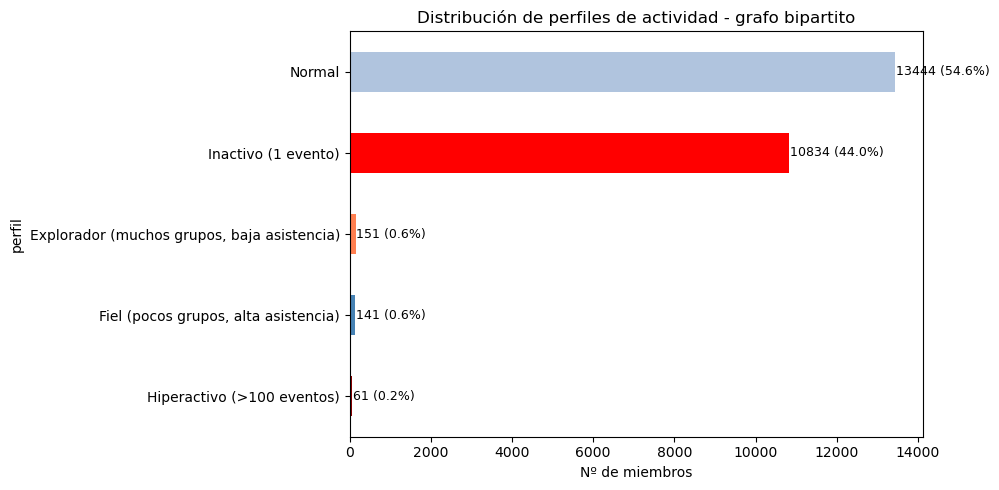

In [36]:
# ── Detección de anomalías de comportamiento ──────────────────────────────

# Clasificar miembros por perfil de actividad
member_activity['perfil'] = 'Normal'

# Inactivos: 1 solo evento
member_activity.loc[member_activity['total_events'] == 1, 'perfil'] = 'Inactivo (1 evento)'

# Exploradores: muchos grupos, pocos eventos por grupo
member_activity.loc[
    (member_activity['num_groups'] > 10) & 
    (member_activity['avg_events_per_group'] < 3), 'perfil'
] = 'Explorador (muchos grupos, baja asistencia)'

# Fieles: pocos grupos, muchos eventos por grupo
member_activity.loc[
    (member_activity['num_groups'] <= 3) & 
    (member_activity['avg_events_per_group'] > 30), 'perfil'
] = 'Fiel (pocos grupos, alta asistencia)'

# Hiperactivos: muchos eventos totales
member_activity.loc[
    member_activity['total_events'] > 100, 'perfil'
] = 'Hiperactivo (>100 eventos)'

print('Distribución de perfiles de actividad:')
print(member_activity['perfil'].value_counts())
print(f'\nTotal miembros clasificados: {len(member_activity)}')

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
perfil_counts = member_activity['perfil'].value_counts()
colors = ['red' if 'Inactivo' in p else 
          'coral' if 'Explorador' in p else
          'steelblue' if 'Fiel' in p else
          'darkred' if 'Hiperactivo' in p else
          'lightsteelblue' for p in perfil_counts.index]

perfil_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Distribución de perfiles de actividad - grafo bipartito')
ax.set_xlabel('Nº de miembros')
ax.invert_yaxis()
for i, v in enumerate(perfil_counts):
    ax.text(v + 10, i, f'{v} ({v/len(member_activity)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Miembros con grado >= 2 (aptos para redundancy): 8209
Miembros con grado = 1 (excluidos)             : 16422

Estadísticas del redundancy coefficient (nodos miembro con grado >= 2):
count    8209.000000
mean        0.834843
std         0.305117
min         0.000000
25%         0.800000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64

Miembros con redundancy = 0   : 692 (8.4%)
Miembros con redundancy = 1.0 : 5477 (66.7%)
Miembros con redundancy > 0.5 : 7049 (85.9%)

Top 10 miembros con mayor redundancy:
               name          city state  redundancy
2     Daniel Newman       Antioch    TN         1.0
4             Brian     Nashville    TN         1.0
10       Matt Smith  Mount Juliet    TN         1.0
11    Brett Baggott     Nashville    TN         1.0
14       Aaron Webb   Springfield    TN         1.0
15           Courey     Nashville    TN         1.0
16      Brian Pitts     Nashville    TN         1.0
17        Lee Jones     Nashville    TN       

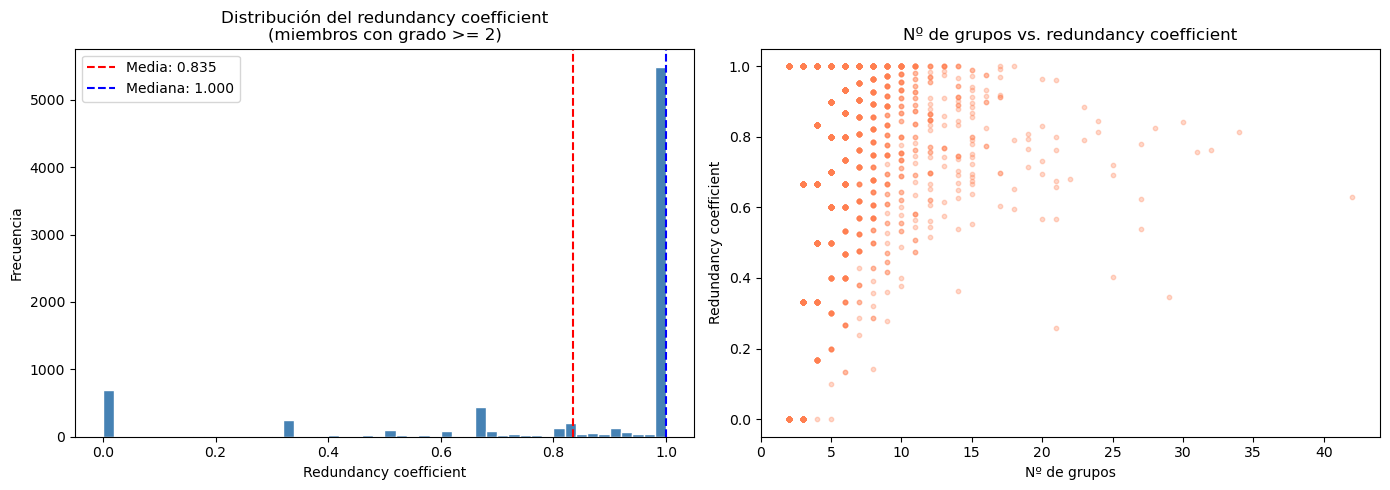

In [39]:
# ── Redundancy coefficient ─────────────────────────────────────────────────
# Solo calculable para nodos con grado >= 2
member_nodes_deg2 = [n for n in member_nodes if MG.degree(n) >= 2]
print(f'Miembros con grado >= 2 (aptos para redundancy): {len(member_nodes_deg2)}')
print(f'Miembros con grado = 1 (excluidos)             : {len(member_nodes) - len(member_nodes_deg2)}')

redundancy = bipartite.node_redundancy(MG, member_nodes_deg2)
redundancy_series = pd.Series(redundancy)

print('\nEstadísticas del redundancy coefficient (nodos miembro con grado >= 2):')
print(redundancy_series.describe())
print(f'\nMiembros con redundancy = 0   : {(redundancy_series == 0).sum()} ({(redundancy_series == 0).sum()/len(redundancy_series)*100:.1f}%)')
print(f'Miembros con redundancy = 1.0 : {(redundancy_series == 1.0).sum()} ({(redundancy_series == 1.0).sum()/len(redundancy_series)*100:.1f}%)')
print(f'Miembros con redundancy > 0.5 : {(redundancy_series > 0.5).sum()} ({(redundancy_series > 0.5).sum()/len(redundancy_series)*100:.1f}%)')

# Enriquecer con metadatos
redundancy_df = pd.DataFrame({
    'node_id': list(redundancy.keys()),
    'redundancy': list(redundancy.values())
})
redundancy_df['member_id'] = redundancy_df['node_id'].str.replace('member_', '')
redundancy_df = redundancy_df.merge(
    meta_members[['member_id', 'name', 'city', 'state']].astype({'member_id': str}),
    on='member_id', how='left'
)

print('\nTop 10 miembros con mayor redundancy:')
print(redundancy_df.nlargest(10, 'redundancy')[
    ['name', 'city', 'state', 'redundancy']
].to_string())

print('\nTop 10 miembros con menor redundancy:')
print(redundancy_df.nsmallest(10, 'redundancy')[
    ['name', 'city', 'state', 'redundancy']
].to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

redundancy_series.plot(kind='hist', bins=50, ax=axes[0],
                       color='steelblue', edgecolor='white')
axes[0].axvline(redundancy_series.mean(), color='red', linestyle='--',
                label=f'Media: {redundancy_series.mean():.3f}')
axes[0].axvline(redundancy_series.median(), color='blue', linestyle='--',
                label=f'Mediana: {redundancy_series.median():.3f}')
axes[0].set_title('Distribución del redundancy coefficient\n(miembros con grado >= 2)')
axes[0].set_xlabel('Redundancy coefficient')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Scatter redundancy vs num_groups
redundancy_df = redundancy_df.merge(
    member_activity[['member_id', 'num_groups', 'total_events']],
    on='member_id', how='left'
)
axes[1].scatter(redundancy_df['num_groups'], redundancy_df['redundancy'],
                alpha=0.3, s=10, color='coral')
axes[1].set_title('Nº de grupos vs. redundancy coefficient')
axes[1].set_xlabel('Nº de grupos')
axes[1].set_ylabel('Redundancy coefficient')

plt.tight_layout()
plt.show()

In [41]:
import os

# Guardar grafo bipartito como GraphML
output_path_MG = "../graphs/graphml/bipartite_graph.graphml"
os.makedirs(os.path.dirname(output_path_MG), exist_ok=True)
nx.write_graphml(MG, output_path_MG)
print(f'Grafo bipartito guardado correctamente en: {output_path_MG}')

Grafo bipartito guardado correctamente en: ../graphs/graphml/bipartite_graph.graphml


# EDA — Grafo Bipartito Miembro-Grupo

## 1. Estadísticas básicas

El grafo bipartito contiene **25.233 nodos en total** — 24.631 nodos de miembro y 602 nodos de grupo — conectados por **45.583 aristas**, donde cada arista representa la pertenencia de un miembro a un grupo. Es el grafo más completo del dataset, incluyendo prácticamente a todos los miembros y todos los grupos. La **densidad es de 0.0031**, reflejo de que cada miembro pertenece de media a muy pocos grupos respecto al total disponible.

A diferencia del grafo de miembros y del grafo de grupos, el **grafo bipartito no es conexo** — presenta **25 componentes conexas**. Sin embargo, la componente principal concentra **25.171 de los 25.233 nodos (99.8%)**, por lo que la desconexión es marginal. Las 24 componentes restantes tienen entre 2 y 7 nodos, con una media de 2.6 nodos, y corresponden en todos los casos a grupos completamente aislados del resto de la red junto con sus miembros exclusivos.

## 2. Análisis de componentes pequeñas

El detalle de las 24 componentes pequeñas revela un patrón muy claro: **todas tienen exactamente 1 grupo**, confirmando que son grupos cuyos miembros no tienen ninguna co-membresía con el resto de la red. Las 19 componentes de 2 nodos representan el caso más extremo — un único miembro en un único grupo, completamente aislado. Las 5 componentes de 3 a 7 nodos son grupos muy pequeños y de nicho, como Hendersonville Volunteering Meetup (6 miembros) o Pure Storage Middle Tennessee (5 miembros).

Destacan casos llamativos como **Cincinnati Conversation about Moments of Grace** — cuyo nombre incluye una ciudad fuera de Tennessee — y grupos muy específicos como witchcraft united o Das Squad, cuya temática tan particular explica su aislamiento estructural. Todos estos grupos y sus miembros constituyen **candidatos directos a anomalía estructural** en el bipartito.

## 3. Distribución de grado por tipo de nodo

### 3.1 Nodos miembro

La distribución de grado de los miembros es extremadamente concentrada: la **mediana es 1 y la media es 1.85**, lo que indica que la mayoría de miembros pertenece a un único grupo. El **66.7% de los miembros tienen grado 1** — solo están en un grupo, sin co-membresía con otros grupos. En el extremo opuesto, **solo 212 miembros (0.9%) pertenecen a más de 10 grupos** y **25 miembros a más de 20 grupos**, siendo el máximo absoluto de 42 grupos para un único miembro.

### 3.2 Nodos grupo

La distribución de grado de los grupos es mucho más dispersa, con una **mediana de 24 miembros activos** y una **media de 75.72**, lo que refleja la fuerte asimetría provocada por grupos gigantes. El **6.1% de los grupos (37) tienen un único miembro activo registrado**, prácticamente inactivos. El grupo más grande en el bipartito tiene 951 miembros activos.

## 4. Análisis de nodos extremos

**Shalini** lidera el ranking de miembros por número de grupos con 42, seguida de Matt Kenigson (34) y Taylor Michael Matson (32). Los top 10 coinciden exactamente con los super-conectores identificados en el grafo de miembros, lo que confirma la coherencia entre grafos — los miembros más conectados en el grafo de miembros son también los que pertenecen a más grupos en el bipartito.

En cuanto a grupos, **20s in Nashville** lidera con 951 miembros activos, seguido de Nashville Hiking Meetup (878) y NashJS (760). Es relevante señalar que estos valores son muy inferiores a los registrados en `meta_groups` — Nashville Hiking Meetup tiene 15.838 miembros registrados pero solo 878 activos — lo que anticipa el hallazgo del ratio de actividad.

## 5. Comparativa miembros registrados vs. activos

El cruce entre el número de miembros registrados en `meta_groups` y el número de miembros con actividad real en el bipartito revela uno de los hallazgos más importantes del EDA completo. El **ratio de actividad medio es de 0.172** y la mediana de 0.139, lo que significa que de media solo el **17% de los miembros registrados en un grupo tienen actividad real** registrada en el dataset.

**226 grupos (37.5%) tienen un ratio inferior al 10%** — más de un tercio de los grupos tienen una actividad real muy por debajo de lo que su número de miembros sugiere. El scatter de miembros registrados vs. activos confirma visualmente que todos los grupos están muy por debajo de la línea ratio=1, sin excepción.

Los grupos con mayor ratio de actividad son mayoritariamente **grupos tecnológicos pequeños y especializados**: T-VOE: Tennessee Voice Over Exchange (88.9%), Nashville Blockchain Meetup (61.7%), Nashville DevOps Meetup (57.9%) o All Things Angular (57.6%). Estos grupos tienen bases de miembros pequeñas pero muy comprometidas.

En el extremo opuesto destacan los **grupos fantasma** — grupos con muchos miembros registrados pero actividad real mínima: Nashville Social Crew (0.07%, 4.017 miembros registrados y solo 3 activos), Nashville Co-Ed Kickball (0.16%, 620 miembros y 1 activo) o Hiking Club of Nashville (0.62%, 3.381 miembros y 21 activos). Estos grupos son candidatos directos a anomalía de comportamiento.

## 6. Análisis de pesos de aristas

El peso de cada arista representa el número de eventos del grupo a los que ha asistido el miembro, lo que lo convierte en la única métrica de **actividad real** del dataset. La distribución es muy concentrada: **mediana = 1, media = 2.78** y el **60.5% de las aristas tienen peso = 1** — la mayoría de miembros solo ha asistido a un único evento de cada grupo al que pertenece.

Solo **156 aristas (0.3%) tienen peso superior a 50** y **49 (0.1%) superior a 100**, representando vínculos de participación extraordinariamente fuertes. El peso máximo es 200, valor que corresponde al truncamiento de la API de Meetup ya identificado en el análisis de `meta_events` — Dustin Hedrick, Unity of Nashville y Nicole Taylor aparecen con este valor máximo, por lo que su actividad real es superior a la registrada.

Los grupos con mayor fidelización de miembros son predominantemente de **New Age & Spirituality, Religion & Beliefs y Career & Business** — comunidades con alto compromiso y participación recurrente.

## 7. Análisis de actividad por miembro

El análisis del total de eventos asistidos por miembro confirma y amplía los hallazgos anteriores. El **44% de los miembros tienen total_events = 1** — casi la mitad del dataset ha asistido a un único evento en toda su historia en Meetup, lo que los convierte en la anomalía de comportamiento más masiva identificada. La mediana de eventos totales es solo 2.

Los miembros más activos presentan dos perfiles claramente diferenciados. **Becki Baumgartner** (513 eventos, 8 grupos, media 64 eventos/grupo) representa el perfil de miembro fiel y comprometido — muy activa en pocos grupos seleccionados. **Taylor Michael Matson** (201 eventos, 32 grupos, media 6.3 eventos/grupo) representa el perfil explorador — activo en muchos grupos pero con baja asistencia en cada uno.

## 8. Perfiles de comportamiento

La segmentación de miembros por perfil de actividad permite identificar cinco grupos con implicaciones directas para la detección de anomalías:

**Normal (54.6%, 13.444 miembros):** actividad moderada y variada, comportamiento base de la red.

**Inactivo (44.0%, 10.834 miembros):** solo han asistido a un único evento. Constituyen la anomalía más masiva del dataset — casi la mitad de los miembros tienen una actividad mínima que cuestiona su implicación real en la plataforma.

**Explorador (0.6%, 151 miembros):** pertenecen a más de 10 grupos con una media de eventos por grupo inferior a 3. Se apuntan a muchos grupos pero asisten poco a cada uno — perfil susceptible de representar comportamiento artificial o cuentas de baja calidad.

**Fiel (0.6%, 141 miembros):** pertenecen a 3 o menos grupos con una media superior a 30 eventos por grupo. El perfil más valioso para los organizadores — alto compromiso con pocas comunidades.

**Hiperactivo (0.2%, 61 miembros):** más de 100 eventos totales. Merecen inspección individual dado su actividad muy por encima de la media.

## 9. Redundancy coefficient

El redundancy coefficient es el equivalente bipartito del coeficiente de clustering y mide para cada nodo la fracción de sus vecinos que comparten al menos un vecino común. Solo es calculable para miembros con grado >= 2, lo que excluye a los 16.422 miembros con un único grupo.

De los **8.209 miembros aptos**, la distribución está **fuertemente concentrada en 1.0**: la mediana es 1.0, la media es 0.835 y el **66.7% tienen redundancy = 1.0** — los grupos a los que pertenecen comparten prácticamente los mismos miembros entre sí, confirmando la alta cohesión interna de las comunidades.

Los **692 miembros con redundancy = 0 (8.4%)** son estructuralmente los más relevantes para detección de anomalías: pertenecen a múltiples grupos que no comparten ningún miembro común entre sí, actuando como puentes entre comunidades completamente distintas en el bipartito. El scatter de número de grupos vs. redundancy confirma que a mayor número de grupos, la redundancy tiende a estabilizarse en valores medios-altos, mientras que los casos con redundancy = 0 y muchos grupos son los outliers estructurales más llamativos.

## 10. Relevancia para detección de anomalías

El grafo bipartito aporta una dimensión de análisis única respecto a los otros dos grafos: la **actividad real** de los miembros, no solo su conectividad estructural. Los candidatos a anomalía identificados pueden organizarse en tres niveles.

A nivel de **comportamiento individual**, los 10.834 miembros inactivos (44%), los 151 exploradores y los 61 hiperactivos constituyen perfiles de actividad atípicos que merecen atención en la fase de modelado.

A nivel de **grupos**, los 226 grupos con ratio de actividad inferior al 10% y en particular los grupos fantasma como Nashville Social Crew (ratio 0.07%) representan anomalías de participación muy claras.

A nivel **estructural**, las 24 componentes aisladas, los 692 miembros con redundancy = 0 y grado >= 2, y los 37 grupos con un único miembro activo son los candidatos estructurales más sólidos para la detección de anomalías basada en topología de grafo.